In [ ]:
# @title EWS-1 — Setup, entradas corrigidas e novas saídas

%pip -q install numpy pandas geopandas shapely rasterio scipy tqdm pyyaml joblib

import os, re, glob, json, time, yaml, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio

from tqdm.auto import tqdm
from joblib import Memory

# =========================================================
# DRIVE
# =========================================================
from google.colab import drive

try:
    drive.mount("/content/drive")
except Exception as e:
    print("Aviso ao montar Drive:", e)

# =========================================================
# PROJETO
# =========================================================
ROOT = Path(
    "/content/drive/MyDrive/Pantanal_TippingPoints"
)

BASE_DIR = ROOT / "index"
OUT_DIR  = BASE_DIR / "outputs"

# =========================================================
# ENTRADAS CANÔNICAS CORRIGIDAS
# =========================================================

# ópticos corrigidos: -32768 -> NaN e escala física
OPT_DIR = (
    OUT_DIR /
    "opt_singleband_300m_cache_corrected"
)

# VOD corrigido e validado
VOD_DIR = (
    OUT_DIR /
    "vod_bi_300m_aligned_corrected"
)

# produtos corrigidos do Impact-TTR
REC_DIR = (
    OUT_DIR /
    "recovery_nb3_corrected"
)

FIRE_DATE_FP = (
    REC_DIR /
    "first_fire_yyyymm.tif"
)

FIRE_YEAR_FP = (
    REC_DIR /
    "first_fire_year.tif"
)

# =========================================================
# NOVAS SAÍDAS EWS
# =========================================================

EWS_BASE = (
    OUT_DIR /
    "ews_nb4_corrected"
)

DESEASON_DIR = EWS_BASE / "deseason"
ROLLING_DIR   = EWS_BASE / "rolling"
TREND_DIR     = EWS_BASE / "trend"
CONTROL_DIR   = EWS_BASE / "controls"
TABLE_DIR     = EWS_BASE / "tables"
FIG_DIR       = EWS_BASE / "figures"
QC_DIR        = EWS_BASE / "qc"
TMP_DIR       = EWS_BASE / "tmp"

for d in [
    EWS_BASE,
    DESEASON_DIR,
    ROLLING_DIR,
    TREND_DIR,
    CONTROL_DIR,
    TABLE_DIR,
    FIG_DIR,
    QC_DIR,
    TMP_DIR
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )

# =========================================================
# CONFIG
# =========================================================

CONFIG_FP = BASE_DIR / "config.yaml"

assert CONFIG_FP.exists(), (
    f"config.yaml não encontrado: {CONFIG_FP}"
)

CONFIG = yaml.safe_load(
    open(CONFIG_FP)
)

BOUNDARY_PATH = Path(
    CONFIG["boundary_path"]
)

assert BOUNDARY_PATH.exists()

# =========================================================
# CHECKS
# =========================================================

assert OPT_DIR.exists(), (
    f"Ópticos corrigidos não encontrados: {OPT_DIR}"
)

assert VOD_DIR.exists(), (
    f"VOD corrigido não encontrado: {VOD_DIR}"
)

assert FIRE_DATE_FP.exists(), (
    f"First-fire corrigido não encontrado: {FIRE_DATE_FP}"
)

print("✔ Setup EWS corrigido")
print("✔ Ópticos:", OPT_DIR)
print("✔ VOD:", VOD_DIR)
print("✔ First fire:", FIRE_DATE_FP)
print("✔ Novas saídas:", EWS_BASE)




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Setup EWS corrigido
✔ Ópticos: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/opt_singleband_300m_cache_corrected
✔ VOD: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/vod_bi_300m_aligned_corrected
✔ First fire: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected/first_fire_yyyymm.tif
✔ Novas saídas: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected


In [ ]:
# @title RESTAURAR SESSÃO + conferir produtos da EWS-6

import numpy as np
import pandas as pd
from pathlib import Path

# =========================================================
# CALENDÁRIO OFICIAL
# =========================================================

BIMONTHS = [1, 3, 5, 7, 9, 11]

YMS = []

for year in range(1987, 2022):
    for month in BIMONTHS:

        ym = year * 100 + month

        if ym < 198709:
            continue

        if ym > 202111:
            continue

        YMS.append(ym)

YM_TO_I = {
    ym: i
    for i, ym in enumerate(YMS)
}

W_ROLL = 8

print("✔ Períodos:", len(YMS))
print("✔ Início:", YMS[0])
print("✔ Fim:", YMS[-1])
print("✔ Rolling window:", W_ROLL)

# =========================================================
# CONFERIR EWS-6
# =========================================================

panel_fp = (
    TABLE_DIR /
    "ews_offset_panel_stats.csv"
)

series_dir = (
    CONTROL_DIR /
    "series_npz"
)

expected = [
    series_dir / f"r3_{idx}_{metric}.npz"
    for idx in ["NDVI", "EVI", "NBR", "VOD"]
    for metric in ["var", "ac1", "cv"]
]

print("\n=== CHECK EWS-6 ===")

print(
    "Painel final:",
    "✔" if panel_fp.exists() else "❌",
    panel_fp
)

missing = [
    fp
    for fp in expected
    if not fp.exists()
]

print(
    f"Matrizes NPZ encontradas: "
    f"{len(expected) - len(missing)}/{len(expected)}"
)

if missing:

    print("\n❌ Arquivos ausentes:")

    for fp in missing:
        print(" -", fp.name)

    print(
        "\nNesse caso, rerode a EWS-6. "
        "Ela possui checkpoints e deverá reaproveitar "
        "o que já foi concluído."
    )

else:

    print(
        "\n✔ EWS-6 completa."
    )

    print(
        "Pode seguir diretamente para a EWS-7."
    )

✔ Períodos: 206
✔ Início: 198709
✔ Fim: 202111
✔ Rolling window: 8

=== CHECK EWS-6 ===
Painel final: ✔ /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/ews_offset_panel_stats.csv
Matrizes NPZ encontradas: 12/12

✔ EWS-6 completa.
Pode seguir diretamente para a EWS-7.


In [ ]:
# @title DIAGNÓSTICO — localizar raster que falha na leitura

import gc
import time
import rasterio as rio
from pathlib import Path

folders = {
    "OPTICAL": OPT_DIR,
    "VOD": VOD_DIR
}

broken = []

for label, folder in folders.items():

    files = sorted(
        Path(folder).rglob("*.tif")
    )

    print(
        f"\n{label}: {len(files)} TIFFs"
    )

    for i, fp in enumerate(files, 1):

        try:

            with rio.open(fp) as ds:

                # leitura REAL do raster;
                # apenas abrir o arquivo não é suficiente
                a = ds.read(1)

            del a
            gc.collect()

        except Exception as e:

            print("\n" + "="*70)
            print("❌ ERRO DE LEITURA")
            print("="*70)

            print("Arquivo:")
            print(fp)

            print("\nTipo:")
            print(type(e).__name__)

            print("\nErro:")
            print(repr(e))

            broken.append(
                str(fp)
            )

            # parar no primeiro arquivo problemático
            break

        if i % 25 == 0:

            print(
                f"  {i}/{len(files)} OK"
            )

    if broken:
        break


print("\n" + "="*70)

if broken:

    print(
        "ARQUIVO PROBLEMÁTICO ENCONTRADO:"
    )

    print(
        broken[0]
    )

else:

    print(
        "✔ Todos os rasters puderam ser lidos."
    )

    print(
        "Nesse caso, o erro provavelmente foi "
        "transitório do Google Drive."
    )


OPTICAL: 618 TIFFs
  25/618 OK
  50/618 OK
  75/618 OK
  100/618 OK
  125/618 OK
  150/618 OK
  175/618 OK
  200/618 OK
  225/618 OK
  250/618 OK
  275/618 OK
  300/618 OK
  325/618 OK
  350/618 OK
  375/618 OK
  400/618 OK
  425/618 OK
  450/618 OK
  475/618 OK
  500/618 OK
  525/618 OK
  550/618 OK
  575/618 OK
  600/618 OK

VOD: 206 TIFFs
  25/206 OK
  50/206 OK
  75/206 OK
  100/206 OK
  125/206 OK
  150/206 OK
  175/206 OK
  200/206 OK

✔ Todos os rasters puderam ser lidos.
Nesse caso, o erro provavelmente foi transitório do Google Drive.


In [ ]:
# @title EWS-2 — Climatologia sazonal pré-fogo por pixel

import re
import json
import gc
import numpy as np
import rasterio as rio
from tqdm.auto import tqdm

# =========================================================
# CONFIGURAÇÃO
# =========================================================

INDICES = ["NDVI", "EVI", "NBR", "VOD"]
BIMES = (1, 3, 5, 7, 9, 11)

START_YM = 198709
END_YM   = 202111

IDX_DIR = {
    "NDVI": OPT_DIR,
    "EVI":  OPT_DIR,
    "NBR":  OPT_DIR,
    "VOD":  VOD_DIR,
}

CLIM_DIR = DESEASON_DIR / "climatology"
CLIM_DIR.mkdir(parents=True, exist_ok=True)

CKPT_FP = QC_DIR / "climatology_checkpoint.json"

# =========================================================
# CATÁLOGO YYYYMM
# =========================================================

YM_RE = re.compile(r"(19|20)\d{4}")

def list_yyyymm(base_dir: Path, idx: str):

    hits = {}

    token = re.compile(
        rf"(^|[_\-]){idx}([_\-]|$)",
        re.IGNORECASE
    )

    for fp in base_dir.glob("*.tif"):

        if not token.search(fp.name):
            continue

        m = YM_RE.search(fp.name)

        if not m:
            continue

        ym = int(m.group(0))

        if START_YM <= ym <= END_YM:
            hits[str(ym)] = fp

    return dict(sorted(hits.items()))


# =========================================================
# PRIMEIRO FOGO
# =========================================================

assert FIRE_DATE_FP.exists()

with rio.open(FIRE_DATE_FP) as ds:

    ff = ds.read(1).astype("float32")
    ff_nodata = ds.nodata

    if ff_nodata is not None:
        ff[ff == ff_nodata] = np.nan

    PROFILE_REF = ds.meta.copy()
    H, W = ds.height, ds.width
    TF = ds.transform
    CRS = ds.crs

print(
    "✔ Grade:",
    H, "×", W,
    "| CRS:", CRS
)


# =========================================================
# CHECKPOINT
# =========================================================

state = {"done": []}

if CKPT_FP.exists():
    try:
        state = json.loads(
            CKPT_FP.read_text()
        )
    except Exception:
        state = {"done": []}

done = set(
    state.get("done", [])
)


# =========================================================
# PERFIS DE SAÍDA
# =========================================================

PROFILE_F32 = PROFILE_REF.copy()

PROFILE_F32.update(
    count=1,
    dtype="float32",
    nodata=np.nan,
    compress="lzw",
    tiled=True,
    BIGTIFF="IF_SAFER"
)

PROFILE_U16 = PROFILE_REF.copy()

PROFILE_U16.update(
    count=1,
    dtype="uint16",
    nodata=0,
    compress="lzw",
    tiled=True,
    BIGTIFF="IF_SAFER"
)


# =========================================================
# PROCESSAMENTO
# =========================================================

for idx in INDICES:

    if idx in done:
        print(f"• {idx}: checkpoint")
        continue

    catalog = list_yyyymm(
        IDX_DIR[idx],
        idx
    )

    assert catalog, (
        f"Nenhum arquivo encontrado para {idx}"
    )

    print(
        f"\n{idx}: {len(catalog)} períodos encontrados"
    )

    # ---------------------------------------------
    # acumuladores por estação bimestral
    # ---------------------------------------------

    sums = {
        m: np.zeros((H, W), dtype="float64")
        for m in BIMES
    }

    sums2 = {
        m: np.zeros((H, W), dtype="float64")
        for m in BIMES
    }

    counts = {
        m: np.zeros((H, W), dtype="uint16")
        for m in BIMES
    }


    # =============================================
    # VARREDURA TEMPORAL
    # =============================================

    for ym, fp in tqdm(
        catalog.items(),
        desc=f"Climatologia {idx}"
    ):

        ym_int = int(ym)
        mm = ym_int % 100

        if mm not in BIMES:
            continue

        with rio.open(fp) as ds:

            # guard-rail de grade
            assert ds.height == H
            assert ds.width == W
            assert str(ds.crs) == str(CRS)

            for _, win in ds.block_windows(1):

                a = ds.read(
                    1,
                    window=win
                ).astype("float32")

                nod = ds.nodata

                if nod is not None:
                    try:
                        if np.isfinite(nod):
                            a[a == nod] = np.nan
                    except Exception:
                        pass

                r0 = int(win.row_off)
                c0 = int(win.col_off)
                h  = int(win.height)
                w  = int(win.width)

                sub_ff = ff[
                    r0:r0+h,
                    c0:c0+w
                ]

                # -----------------------------------------
                # usar:
                # - pixels nunca queimados
                # OU
                # - observações anteriores ao primeiro fogo
                # -----------------------------------------

                prefire = (
                    (~np.isfinite(sub_ff))
                    |
                    (ym_int < sub_ff)
                )

                good = (
                    np.isfinite(a)
                    &
                    prefire
                )

                if not np.any(good):
                    continue

                values = np.where(
                    good,
                    a,
                    0.0
                ).astype("float64")

                sl = (
                    slice(r0, r0+h),
                    slice(c0, c0+w)
                )

                sums[mm][sl] += values
                sums2[mm][sl] += values * values
                counts[mm][sl] += good.astype("uint16")


    # =============================================
    # SALVAR CLIMATOLOGIA
    # =============================================

    idx_out = CLIM_DIR / idx
    idx_out.mkdir(
        parents=True,
        exist_ok=True
    )

    for mm in BIMES:

        cnt = counts[mm].astype("float64")

        mean = np.full(
            (H, W),
            np.nan,
            dtype="float32"
        )

        std = np.full(
            (H, W),
            np.nan,
            dtype="float32"
        )

        # média
        valid_mean = cnt > 0

        mean[valid_mean] = (
            sums[mm][valid_mean]
            /
            cnt[valid_mean]
        ).astype("float32")

        # desvio-padrão amostral
        valid_std = cnt > 1

        variance = np.full(
            (H, W),
            np.nan,
            dtype="float64"
        )

        variance[valid_std] = (
            sums2[mm][valid_std]
            -
            (
                sums[mm][valid_std] ** 2
                /
                cnt[valid_std]
            )
        ) / (
            cnt[valid_std] - 1
        )

        # proteção contra erro numérico negativo
        variance[
            np.isfinite(variance)
            &
            (variance < 0)
        ] = 0

        std[valid_std] = np.sqrt(
            variance[valid_std]
        ).astype("float32")

        # std praticamente zero não permite z-score
        std[
            np.isfinite(std)
            &
            (std < 1e-6)
        ] = np.nan


        fp_mean = (
            idx_out /
            f"{idx}_clim_mean_m{mm:02d}_300m.tif"
        )

        fp_std = (
            idx_out /
            f"{idx}_clim_std_m{mm:02d}_300m.tif"
        )

        fp_n = (
            idx_out /
            f"{idx}_clim_n_m{mm:02d}_300m.tif"
        )


        with rio.open(
            fp_mean,
            "w",
            **PROFILE_F32
        ) as dst:
            dst.write(mean, 1)


        with rio.open(
            fp_std,
            "w",
            **PROFILE_F32
        ) as dst:
            dst.write(std, 1)


        with rio.open(
            fp_n,
            "w",
            **PROFILE_U16
        ) as dst:
            dst.write(
                counts[mm],
                1
            )


    # =============================================
    # CHECKPOINT
    # =============================================

    done.add(idx)

    CKPT_FP.write_text(
        json.dumps({
            "done": sorted(done)
        })
    )

    print(
        f"✔ {idx}: climatologia salva em",
        idx_out
    )

    del sums, sums2, counts
    gc.collect()


print(
    "\n✔ Climatologia pré-fogo concluída."
)


✔ Grade: 2448 × 1612 | CRS: EPSG:31983

NDVI: 206 períodos encontrados


Climatologia NDVI:   0%|          | 0/206 [00:00<?, ?it/s]

✔ NDVI: climatologia salva em /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/deseason/climatology/NDVI

EVI: 206 períodos encontrados


Climatologia EVI:   0%|          | 0/206 [00:00<?, ?it/s]

✔ EVI: climatologia salva em /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/deseason/climatology/EVI

NBR: 206 períodos encontrados


Climatologia NBR:   0%|          | 0/206 [00:00<?, ?it/s]

✔ NBR: climatologia salva em /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/deseason/climatology/NBR

VOD: 205 períodos encontrados


Climatologia VOD:   0%|          | 0/205 [00:00<?, ?it/s]

✔ VOD: climatologia salva em /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/deseason/climatology/VOD

✔ Climatologia pré-fogo concluída.


In [ ]:
# @title REPARO — detectar e remover z-scores corrompidos da EWS-3

import rasterio as rio
from rasterio.windows import Window
from pathlib import Path

INDICES = ["NDVI", "EVI", "NBR", "VOD"]

broken = []
total = 0

for idx in INDICES:

    folder = DESEASON_DIR / idx

    files = sorted(
        folder.glob(
            f"{idx}_deseason_z_*_300m.tif"
        )
    )

    print(
        f"\n{idx}: {len(files)} arquivos"
    )

    for fp in files:

        total += 1

        try:

            with rio.open(fp) as ds:

                # verifica estrutura básica
                if (
                    ds.driver != "GTiff"
                    or ds.count != 1
                    or ds.width <= 0
                    or ds.height <= 0
                ):
                    raise RuntimeError(
                        "Estrutura GeoTIFF inválida"
                    )

                # leitura pequena REAL para testar o raster
                w = min(64, ds.width)
                h = min(64, ds.height)

                _ = ds.read(
                    1,
                    window=Window(
                        0,
                        0,
                        w,
                        h
                    )
                )

        except Exception as e:

            print(
                "❌ CORROMPIDO:",
                fp.name
            )

            print(
                "   ",
                repr(e)
            )

            broken.append(fp)


print("\n" + "="*70)

print(
    "Arquivos examinados:",
    total
)

print(
    "Arquivos inválidos:",
    len(broken)
)

if broken:

    print(
        "\nRemovendo somente os arquivos inválidos..."
    )

    for fp in broken:

        try:

            fp.unlink()

            print(
                "🗑 removido:",
                fp.name
            )

        except Exception as e:

            print(
                "⚠ não consegui remover:",
                fp,
                e
            )

    print(
        "\n✔ Arquivos corrompidos removidos."
    )

    print(
        "Agora rerode a EWS-3."
    )

else:

    print(
        "✔ Nenhum arquivo estruturalmente inválido encontrado."
    )


NDVI: 206 arquivos

EVI: 206 arquivos
❌ CORROMPIDO: EVI_deseason_z_198805_300m.tif
    RasterioIOError('Read failed. See previous exception for details.')
❌ CORROMPIDO: EVI_deseason_z_198807_300m.tif
    RasterioIOError('/content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/deseason/EVI/EVI_deseason_z_198807_300m.tif: Transport endpoint is not connected')
❌ CORROMPIDO: EVI_deseason_z_198809_300m.tif
    RasterioIOError('/content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/deseason/EVI/EVI_deseason_z_198809_300m.tif: Transport endpoint is not connected')
❌ CORROMPIDO: EVI_deseason_z_198811_300m.tif
    RasterioIOError('/content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/deseason/EVI/EVI_deseason_z_198811_300m.tif: Transport endpoint is not connected')
❌ CORROMPIDO: EVI_deseason_z_198901_300m.tif
    RasterioIOError('/content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/deseason/EVI/EVI_de

In [ ]:
# @title VERIFICAÇÃO FINAL — remover z-scores corrompidos restantes

import os
import time
import rasterio as rio
from rasterio.windows import Window

INDICES = ["NDVI", "EVI", "NBR", "VOD"]

broken = []

# =========================================================
# 1. LOCALIZAR CORROMPIDOS QUE AINDA EXISTEM
# =========================================================

for idx in INDICES:

    folder = DESEASON_DIR / idx

    for fp in sorted(
        folder.glob(f"{idx}_deseason_z_*_300m.tif")
    ):

        try:

            with rio.open(fp) as ds:

                _ = ds.read(
                    1,
                    window=Window(
                        0,
                        0,
                        min(32, ds.width),
                        min(32, ds.height)
                    )
                )

        except Exception:

            broken.append(fp)


print(
    "Corrompidos ainda presentes:",
    len(broken)
)

# =========================================================
# 2. TENTAR REMOVER NOVAMENTE
# =========================================================

remaining = []

for fp in broken:

    removed = False

    for attempt in range(1, 4):

        try:

            if fp.exists():
                os.remove(fp)

            time.sleep(1)

            if not fp.exists():

                print(
                    "🗑 removido:",
                    fp.name
                )

                removed = True
                break

        except Exception as e:

            print(
                f"⚠ tentativa {attempt}/3:",
                fp.name,
                repr(e)
            )

            time.sleep(2)

    if not removed:

        remaining.append(fp)


# =========================================================
# 3. RESULTADO
# =========================================================

print("\n" + "="*65)

print(
    "Corrompidos que NÃO puderam ser removidos:",
    len(remaining)
)

if remaining:

    for fp in remaining:
        print("❌", fp)

    print(
        "\nNÃO rode a EWS-3 ainda."
    )

else:

    print(
        "✔ Todos os arquivos corrompidos foram removidos."
    )

    print(
        "✔ Agora pode rerodar a EWS-3."
    )

Corrompidos ainda presentes: 0

Corrompidos que NÃO puderam ser removidos: 0
✔ Todos os arquivos corrompidos foram removidos.
✔ Agora pode rerodar a EWS-3.


In [ ]:
# @title EWS-3 — Dessazonalização: anomalias e z-scores

import re
import gc
import numpy as np
import pandas as pd
import rasterio as rio
from tqdm.auto import tqdm

# =========================================================
# CONFIGURAÇÃO
# =========================================================

INDICES = ["NDVI", "EVI", "NBR", "VOD"]

BIMES = (1, 3, 5, 7, 9, 11)

START_YM = 198709
END_YM   = 202111

IDX_DIR = {
    "NDVI": OPT_DIR,
    "EVI":  OPT_DIR,
    "NBR":  OPT_DIR,
    "VOD":  VOD_DIR,
}

OUT_DE = DESEASON_DIR

# climatologia criada pela EWS-2
CLIM_DIR = DESEASON_DIR / "climatology"

# =========================================================
# CATÁLOGO DE ENTRADAS
# =========================================================

YM_RE = re.compile(
    r"(19|20)\d{4}"
)

def scan_inputs(idx):

    base = IDX_DIR[idx]

    token = re.compile(
        rf"(^|[_\-]){idx}([_\-]|$)",
        re.IGNORECASE
    )

    hits = {}

    for fp in base.glob("*.tif"):

        if not token.search(fp.name):
            continue

        m = YM_RE.search(fp.name)

        if not m:
            continue

        ym = int(m.group(0))

        mm = ym % 100

        if (
            START_YM <= ym <= END_YM
            and mm in BIMES
        ):
            hits[ym] = fp

    return dict(
        sorted(hits.items())
    )


# =========================================================
# LEITURA
# =========================================================

def read_f32(fp):

    with rio.open(fp) as ds:

        a = ds.read(1).astype("float32")

        nod = ds.nodata

        if nod is not None:

            try:
                if np.isfinite(nod):
                    a[a == nod] = np.nan
            except Exception:
                pass

        meta = ds.meta.copy()

    a[~np.isfinite(a)] = np.nan

    return a, meta


# =========================================================
# ESCRITA
# =========================================================

def write_f32(fp, arr, meta_ref):

    meta = meta_ref.copy()

    meta.update(
        count=1,
        dtype="float32",
        nodata=np.nan,
        compress="lzw",
        tiled=True,
        BIGTIFF="IF_SAFER"
    )

    with rio.open(
        fp,
        "w",
        **meta
    ) as dst:

        dst.write(
            arr.astype("float32"),
            1
        )


# =========================================================
# PROCESSAMENTO
# =========================================================

qc_rows = []

for idx in INDICES:

    print("\n" + "="*60)
    print("DESEASON:", idx)
    print("="*60)

    catalog = scan_inputs(idx)

    assert catalog, (
        f"Nenhuma entrada encontrada para {idx}"
    )

    out_idx = OUT_DE / idx

    out_idx.mkdir(
        parents=True,
        exist_ok=True
    )

    clim_idx = (
        CLIM_DIR /
        idx
    )

    assert clim_idx.exists(), (
        f"Climatologia não encontrada para {idx}: "
        f"{clim_idx}"
    )

    # -----------------------------------------------------
    # carregar climatologias
    # -----------------------------------------------------

    clim = {}

    for mm in BIMES:

        fp_mean = (
            clim_idx /
            f"{idx}_clim_mean_m{mm:02d}_300m.tif"
        )

        fp_std = (
            clim_idx /
            f"{idx}_clim_std_m{mm:02d}_300m.tif"
        )

        assert fp_mean.exists(), fp_mean
        assert fp_std.exists(), fp_std

        mean, meta_mean = read_f32(
            fp_mean
        )

        std, meta_std = read_f32(
            fp_std
        )

        # std inválido ou praticamente zero
        std[
            (~np.isfinite(std))
            |
            (std < 1e-6)
        ] = np.nan

        clim[mm] = (
            mean,
            std
        )


    n_inputs = 0
    n_anom = 0
    n_z = 0


    # =====================================================
    # SÉRIE TEMPORAL
    # =====================================================

    for ym, fp in tqdm(
        catalog.items(),
        desc=f"Deseason {idx}"
    ):

        mm = ym % 100

        n_inputs += 1

        out_anom = (
            out_idx /
            f"{idx}_deseason_anom_{ym}_300m.tif"
        )

        out_z = (
            out_idx /
            f"{idx}_deseason_z_{ym}_300m.tif"
        )

        # checkpoint simples
        need_anom = not out_anom.exists()
        need_z = not out_z.exists()

        if not (
            need_anom
            or need_z
        ):
            continue

        a, meta = read_f32(fp)

        mean, std = clim[mm]

        # -------------------------------------------------
        # guard-rail de grade
        # -------------------------------------------------

        if a.shape != mean.shape:

            raise RuntimeError(
                f"Grade incompatível: {fp}"
            )


        # =================================================
        # ANOMALIA
        #
        # valor observado - climatologia pré-fogo
        # =================================================

        if need_anom:

            anom = (
                a -
                mean
            ).astype("float32")

            anom[
                ~np.isfinite(anom)
            ] = np.nan

            write_f32(
                out_anom,
                anom,
                meta
            )

            n_anom += 1


        # =================================================
        # Z-SCORE
        #
        # (observado - média climatológica) /
        # desvio-padrão climatológico
        # =================================================

        if need_z:

            with np.errstate(
                divide="ignore",
                invalid="ignore"
            ):

                z = (
                    a -
                    mean
                ) / std

            z = z.astype(
                "float32"
            )

            z[
                ~np.isfinite(z)
            ] = np.nan

            write_f32(
                out_z,
                z,
                meta
            )

            n_z += 1


        del a
        gc.collect()


    qc_rows.append({

        "metric":
            idx,

        "input_periods":
            n_inputs,

        "anom_written":
            n_anom,

        "z_written":
            n_z,

        "anom_total":
            len(
                list(
                    out_idx.glob(
                        f"{idx}_deseason_anom_*_300m.tif"
                    )
                )
            ),

        "z_total":
            len(
                list(
                    out_idx.glob(
                        f"{idx}_deseason_z_*_300m.tif"
                    )
                )
            )
    })


# =========================================================
# QC
# =========================================================

df_qc = pd.DataFrame(
    qc_rows
)

QC_FP = (
    QC_DIR /
    "deseason_qc.csv"
)

df_qc.to_csv(
    QC_FP,
    index=False
)

print("\n" + "="*60)
print("DESEASON FINALIZADO")
print("="*60)

display(df_qc)

print(
    "\n✔ Saídas:",
    DESEASON_DIR
)

print(
    "✔ QC:",
    QC_FP
)



DESEASON: NDVI


Deseason NDVI:   0%|          | 0/206 [00:00<?, ?it/s]


DESEASON: EVI


Deseason EVI:   0%|          | 0/206 [00:00<?, ?it/s]


DESEASON: NBR


...


DESEASON: VOD


Deseason VOD:   0%|          | 0/205 [00:00<?, ?it/s]


DESEASON FINALIZADO


,metric,input_periods,anom_written,z_written,anom_total,z_total
0,NDVI,206,0,0,206,206
1,EVI,206,0,0,206,206
2,NBR,206,0,0,206,206
3,VOD,205,0,0,205,205



✔ Saídas: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/deseason
✔ QC: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/qc/deseason_qc.csv


In [ ]:
# @title EWS-4 — Rolling VAR, AC1 e CV sobre z-scores dessazonalizados — W=8

import gc
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.windows import Window
from tqdm.auto import tqdm

# =========================================================
# CONFIGURAÇÃO
# =========================================================

INDICES = ["NDVI", "EVI", "NBR", "VOD"]
METRICS = ["var", "ac1", "cv"]

# janela móvel:
# 8 períodos bimestrais anteriores = 16 meses
W_ROLL = 8

BIMES = (1, 3, 5, 7, 9, 11)

START_YM = 198709
END_YM   = 202111

NODATA_OUT = -32768.0

# saída
ROLLING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CKPT_FP = (
    QC_DIR /
    "rolling_ews_checkpoint.json"
)

# =========================================================
# CALENDÁRIO BIMESTRAL REGULAR
# =========================================================

def make_regular_calendar(start_ym, end_ym):

    out = []

    y0 = start_ym // 100
    y1 = end_ym // 100

    for year in range(y0, y1 + 1):

        for month in BIMES:

            ym = (
                year * 100 +
                month
            )

            if (
                start_ym <= ym <= end_ym
            ):
                out.append(ym)

    return out


YMS = make_regular_calendar(
    START_YM,
    END_YM
)

YM_TO_I = {
    ym: i
    for i, ym in enumerate(YMS)
}

print(
    "✔ Calendário regular:",
    len(YMS),
    "períodos |",
    YMS[0],
    "→",
    YMS[-1]
)


# =========================================================
# CATÁLOGO DOS Z-SCORES
# =========================================================

def build_z_catalog(idx):

    folder = (
        DESEASON_DIR /
        idx
    )

    assert folder.exists(), (
        f"Pasta não encontrada: {folder}"
    )

    pattern = re.compile(
        rf"^{idx}_deseason_z_"
        rf"(\d{{6}})_300m\.tif$",
        re.IGNORECASE
    )

    catalog = {}

    for fp in folder.glob("*.tif"):

        m = pattern.match(fp.name)

        if not m:
            continue

        ym = int(
            m.group(1)
        )

        if (
            START_YM <= ym <= END_YM
        ):
            catalog[ym] = fp

    return dict(
        sorted(catalog.items())
    )


# =========================================================
# CHECKPOINT
# =========================================================

state = {}

if CKPT_FP.exists():

    try:
        state = json.loads(
            CKPT_FP.read_text()
        )

    except Exception:
        state = {}


def save_checkpoint():

    CKPT_FP.write_text(
        json.dumps(
            state,
            indent=2
        )
    )


# =========================================================
# AC1
# =========================================================

def ac1_lag1_cube(cube):
    """
    AC1 lag-1 em cube (T,H,W).

    Mantém NaNs.
    Usa somente pares temporalmente adjacentes
    que sejam ambos válidos.
    """

    finite = np.isfinite(
        cube
    )

    nvalid = finite.sum(
        axis=0
    )

    with warnings.catch_warnings():

        warnings.simplefilter(
            "ignore",
            RuntimeWarning
        )

        mu = np.nanmean(
            cube,
            axis=0
        )

    centered = (
        cube -
        mu[None, :, :]
    )

    # pares realmente adjacentes no calendário
    pair_valid = (
        np.isfinite(
            centered[:-1]
        )
        &
        np.isfinite(
            centered[1:]
        )
    )

    npairs = pair_valid.sum(
        axis=0
    )

    products = (
        centered[:-1] *
        centered[1:]
    )

    products[
        ~pair_valid
    ] = np.nan

    with warnings.catch_warnings():

        warnings.simplefilter(
            "ignore",
            RuntimeWarning
        )

        numerator = np.nanmean(
            products,
            axis=0
        )

        denominator = np.nanvar(
            cube,
            axis=0,
            ddof=0
        )

    ac1 = np.full(
        mu.shape,
        np.nan,
        dtype="float32"
    )

    good = (
        (nvalid >= 2)
        &
        (npairs >= 1)
        &
        np.isfinite(denominator)
        &
        (denominator > 0)
        &
        np.isfinite(numerator)
    )

    ac1[good] = (
        numerator[good] /
        denominator[good]
    ).astype("float32")

    return (
        ac1,
        nvalid,
        npairs
    )


# =========================================================
# MÉTRICAS DA JANELA
# =========================================================

def compute_metrics_cube(cube):
    """
    cube = 8 posições CRONOLÓGICAS.

    Uma data ausente permanece NaN.
    Não há compressão temporal.
    """

    with warnings.catch_warnings():

        warnings.simplefilter(
            "ignore",
            RuntimeWarning
        )

        mu = np.nanmean(
            cube,
            axis=0
        )

        sd = np.nanstd(
            cube,
            axis=0,
            ddof=0
        )

    var = (
        sd ** 2
    ).astype("float32")

    ac1, nvalid, npairs = (
        ac1_lag1_cube(
            cube
        )
    )

    # ---------------------------------------------
    # Mesmo critério básico do código original:
    # pelo menos 2 observações válidas.
    # ---------------------------------------------

    invalid = (
        nvalid < 2
    )

    var[invalid] = np.nan
    ac1[invalid] = np.nan

    # ---------------------------------------------
    # CV
    #
    # Mantido conforme a metodologia:
    # SD / |mean|
    #
    # NÃO:
    # - truncamos
    # - winsorizamos
    # - removemos valores grandes
    # ---------------------------------------------

    with np.errstate(
        divide="ignore",
        invalid="ignore",
        over="ignore"
    ):

        cv = (
            sd /
            np.abs(mu)
        )

    cv = cv.astype(
        "float32"
    )

    # média exatamente zero:
    # matematicamente indefinido
    cv[
        (~np.isfinite(cv))
        |
        invalid
    ] = np.nan

    return (
        var,
        ac1,
        cv,
        mu,
        nvalid,
        npairs
    )


# =========================================================
# IO
# =========================================================

def output_profile(ref_meta):

    prof = ref_meta.copy()

    prof.update(
        count=1,
        dtype="float32",
        nodata=NODATA_OUT,
        compress="lzw",
        tiled=True,
        BIGTIFF="IF_SAFER"
    )

    return prof


def write_metric(
    fp,
    arr,
    profile
):

    out = np.where(
        np.isfinite(arr),
        arr,
        NODATA_OUT
    ).astype("float32")

    with rio.open(
        fp,
        "w",
        **profile
    ) as dst:

        dst.write(
            out,
            1
        )


# =========================================================
# PROCESSAMENTO
# =========================================================

qc_rows = []

for idx in INDICES:

    print("\n" + "="*65)
    print("ROLLING EWS:", idx)
    print("="*65)

    catalog = build_z_catalog(
        idx
    )

    assert catalog, (
        f"Nenhum z-score encontrado para {idx}"
    )

    print(
        f"Z-scores disponíveis: "
        f"{len(catalog)}/{len(YMS)}"
    )

    missing = [
        ym
        for ym in YMS
        if ym not in catalog
    ]

    if missing:

        print(
            "Períodos ausentes:",
            missing
        )

    else:

        print(
            "✔ Série sem lacunas."
        )


    # -----------------------------------------------------
    # referência
    # -----------------------------------------------------

    ref_fp = next(
        iter(
            catalog.values()
        )
    )

    with rio.open(
        ref_fp
    ) as ref:

        H = ref.height
        WD = ref.width

        ref_meta = (
            ref.meta.copy()
        )

        if ref.block_shapes:
            BY, BX = (
                ref.block_shapes[0]
            )

        else:
            BY, BX = (
                256,
                256
            )

    profile = output_profile(
        ref_meta
    )


    # -----------------------------------------------------
    # saída por índice
    # -----------------------------------------------------

    out_idx = (
        ROLLING_DIR /
        idx
    )

    out_idx.mkdir(
        parents=True,
        exist_ok=True
    )


    # -----------------------------------------------------
    # QC acumulado do CV
    # -----------------------------------------------------

    qc_total_cells = 0

    qc_valid_cv = 0

    qc_mu_lt_1e_1 = 0
    qc_mu_lt_1e_2 = 0
    qc_mu_lt_1e_3 = 0

    qc_cv_gt_10 = 0
    qc_cv_gt_100 = 0
    qc_cv_gt_1000 = 0

    qc_cv_max = -np.inf


    # =====================================================
    # ALVOS TEMPORAIS
    #
    # O valor em target_ym é calculado usando
    # EXATAMENTE os 8 períodos cronológicos anteriores.
    # =====================================================

    for target_i in tqdm(
        range(W_ROLL, len(YMS)),
        desc=f"EWS {idx}",
        unit="period"
    ):

        target_ym = (
            YMS[target_i]
        )

        window_yms = (
            YMS[
                target_i-W_ROLL:
                target_i
            ]
        )

        assert (
            len(window_yms)
            ==
            W_ROLL
        )


        out_var = (
            out_idx /
            f"{idx}_rolling_var_prefire_"
            f"{target_ym}_300m.tif"
        )

        out_ac1 = (
            out_idx /
            f"{idx}_rolling_ac1_prefire_"
            f"{target_ym}_300m.tif"
        )

        out_cv = (
            out_idx /
            f"{idx}_rolling_cv_prefire_"
            f"{target_ym}_300m.tif"
        )


        key = (
            f"{idx}_{target_ym}"
        )

        if (
            out_var.exists()
            and out_ac1.exists()
            and out_cv.exists()
        ):

            state[key] = "done"
            continue


        # -------------------------------------------------
        # abrir datasets existentes desta janela
        #
        # datas ausentes ficam como None
        # -------------------------------------------------

        datasets = []

        for ym in window_yms:

            fp = catalog.get(
                ym
            )

            if fp is None:

                datasets.append(
                    None
                )

            else:

                datasets.append(
                    rio.open(fp)
                )


        # -------------------------------------------------
        # criar outputs temporários
        # -------------------------------------------------

        tmp_var = (
            TMP_DIR /
            f"tmp_{idx}_var_{target_ym}.tif"
        )

        tmp_ac1 = (
            TMP_DIR /
            f"tmp_{idx}_ac1_{target_ym}.tif"
        )

        tmp_cv = (
            TMP_DIR /
            f"tmp_{idx}_cv_{target_ym}.tif"
        )


        try:

            with (
                rio.open(
                    tmp_var,
                    "w",
                    **profile
                ) as dst_var,

                rio.open(
                    tmp_ac1,
                    "w",
                    **profile
                ) as dst_ac1,

                rio.open(
                    tmp_cv,
                    "w",
                    **profile
                ) as dst_cv
            ):

                # =========================================
                # BLOCOS
                # =========================================

                for row in range(
                    0,
                    H,
                    BY
                ):

                    h = min(
                        BY,
                        H-row
                    )

                    for col in range(
                        0,
                        WD,
                        BX
                    ):

                        w = min(
                            BX,
                            WD-col
                        )

                        win = Window(
                            col_off=col,
                            row_off=row,
                            width=w,
                            height=h
                        )


                        # ---------------------------------
                        # cubo cronológico de 8 períodos
                        # ---------------------------------

                        slices = []

                        for ds in datasets:

                            if ds is None:

                                a = np.full(
                                    (h, w),
                                    np.nan,
                                    dtype="float32"
                                )

                            else:

                                a = ds.read(
                                    1,
                                    window=win
                                ).astype(
                                    "float32"
                                )

                                nod = ds.nodata

                                if nod is not None:

                                    if np.isfinite(
                                        nod
                                    ):

                                        a[
                                            a == nod
                                        ] = np.nan

                                a[
                                    ~np.isfinite(a)
                                ] = np.nan

                            slices.append(
                                a
                            )


                        cube = np.stack(
                            slices,
                            axis=0
                        )


                        (
                            var,
                            ac1,
                            cv,
                            mu,
                            nvalid,
                            npairs
                        ) = compute_metrics_cube(
                            cube
                        )


                        # =============================
                        # QC CV
                        # =============================

                        eligible = (
                            nvalid >= 2
                        )

                        qc_total_cells += int(
                            eligible.sum()
                        )

                        finite_cv = (
                            eligible
                            &
                            np.isfinite(cv)
                        )

                        qc_valid_cv += int(
                            finite_cv.sum()
                        )

                        abs_mu = np.abs(
                            mu
                        )

                        qc_mu_lt_1e_1 += int(
                            (
                                eligible
                                &
                                np.isfinite(abs_mu)
                                &
                                (abs_mu < 1e-1)
                            ).sum()
                        )

                        qc_mu_lt_1e_2 += int(
                            (
                                eligible
                                &
                                np.isfinite(abs_mu)
                                &
                                (abs_mu < 1e-2)
                            ).sum()
                        )

                        qc_mu_lt_1e_3 += int(
                            (
                                eligible
                                &
                                np.isfinite(abs_mu)
                                &
                                (abs_mu < 1e-3)
                            ).sum()
                        )

                        qc_cv_gt_10 += int(
                            (
                                finite_cv
                                &
                                (cv > 10)
                            ).sum()
                        )

                        qc_cv_gt_100 += int(
                            (
                                finite_cv
                                &
                                (cv > 100)
                            ).sum()
                        )

                        qc_cv_gt_1000 += int(
                            (
                                finite_cv
                                &
                                (cv > 1000)
                            ).sum()
                        )

                        if np.any(
                            finite_cv
                        ):

                            block_max = float(
                                np.nanmax(
                                    cv[
                                        finite_cv
                                    ]
                                )
                            )

                            qc_cv_max = max(
                                qc_cv_max,
                                block_max
                            )


                        # =============================
                        # ESCREVER
                        # =============================

                        var_w = np.where(
                            np.isfinite(var),
                            var,
                            NODATA_OUT
                        ).astype(
                            "float32"
                        )

                        ac1_w = np.where(
                            np.isfinite(ac1),
                            ac1,
                            NODATA_OUT
                        ).astype(
                            "float32"
                        )

                        cv_w = np.where(
                            np.isfinite(cv),
                            cv,
                            NODATA_OUT
                        ).astype(
                            "float32"
                        )

                        dst_var.write(
                            var_w,
                            1,
                            window=win
                        )

                        dst_ac1.write(
                            ac1_w,
                            1,
                            window=win
                        )

                        dst_cv.write(
                            cv_w,
                            1,
                            window=win
                        )

                        del (
                            cube,
                            slices,
                            var,
                            ac1,
                            cv,
                            mu,
                            nvalid,
                            npairs
                        )


            # ---------------------------------------------
            # somente após conclusão:
            # temporário → produto final
            # ---------------------------------------------

            tmp_var.replace(
                out_var
            )

            tmp_ac1.replace(
                out_ac1
            )

            tmp_cv.replace(
                out_cv
            )

            state[key] = "done"

            save_checkpoint()


        finally:

            for ds in datasets:

                if ds is not None:

                    try:
                        ds.close()
                    except Exception:
                        pass


            for fp in [
                tmp_var,
                tmp_ac1,
                tmp_cv
            ]:

                if fp.exists():

                    try:
                        fp.unlink()
                    except Exception:
                        pass


        gc.collect()


    # =====================================================
    # QC POR ÍNDICE
    # =====================================================

    if not np.isfinite(
        qc_cv_max
    ):
        qc_cv_max = np.nan


    qc_rows.append({

        "metric":
            idx,

        "calendar_periods":
            len(YMS),

        "zscore_periods_available":
            len(catalog),

        "missing_periods":
            ",".join(
                str(x)
                for x in missing
            ),

        "rolling_window":
            W_ROLL,

        "eligible_values":
            qc_total_cells,

        "finite_cv":
            qc_valid_cv,

        "abs_mean_lt_0.1":
            qc_mu_lt_1e_1,

        "abs_mean_lt_0.01":
            qc_mu_lt_1e_2,

        "abs_mean_lt_0.001":
            qc_mu_lt_1e_3,

        "cv_gt_10":
            qc_cv_gt_10,

        "cv_gt_100":
            qc_cv_gt_100,

        "cv_gt_1000":
            qc_cv_gt_1000,

        "cv_max":
            qc_cv_max
    })


# =========================================================
# QC FINAL
# =========================================================

df_roll_qc = pd.DataFrame(
    qc_rows
)

QC_ROLL_FP = (
    QC_DIR /
    "rolling_ews_qc.csv"
)

df_roll_qc.to_csv(
    QC_ROLL_FP,
    index=False
)

print("\n" + "="*65)
print("ROLLING EWS FINALIZADO")
print("="*65)

display(
    df_roll_qc
)

print(
    "\n✔ VAR / AC1 / CV:",
    ROLLING_DIR
)

print(
    "✔ QC:",
    QC_ROLL_FP
)

✔ Calendário regular: 206 períodos | 198709 → 202111

ROLLING EWS: NDVI
Z-scores disponíveis: 206/206
✔ Série sem lacunas.


EWS NDVI:   0%|          | 0/198 [00:00<?, ?period/s]


ROLLING EWS: EVI
Z-scores disponíveis: 206/206
✔ Série sem lacunas.


EWS EVI:   0%|          | 0/198 [00:00<?, ?period/s]


ROLLING EWS: NBR
Z-scores disponíveis: 206/206
✔ Série sem lacunas.


...


ROLLING EWS: VOD
Z-scores disponíveis: 205/206
Períodos ausentes: [199105]


EWS VOD:   0%|          | 0/198 [00:00<?, ?period/s]


ROLLING EWS FINALIZADO


,metric,calendar_periods,zscore_periods_available,missing_periods,rolling_window,eligible_values,finite_cv,abs_mean_lt_0.1,abs_mean_lt_0.01,abs_mean_lt_0.001,cv_gt_10,cv_gt_100,cv_gt_1000,cv_max
0,NDVI,206,206,,8,375428048,375427681,46317591,3262732,325944,28272530,2243694,225052,89929192.0
1,EVI,206,206,,8,750675945,750674170,70494539,6249103,634817,49658350,4525369,461977,122624456.0
2,NBR,206,206,,8,750675968,750671459,72053290,6544390,670539,49629989,4657559,479334,98835640.0
3,VOD,206,205,199105,8,712118245,712115391,78832020,7960351,812696,50917679,5139309,529335,522774560.0



✔ VAR / AC1 / CV: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/rolling
✔ QC: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/qc/rolling_ews_qc.csv


In [ ]:
# @title EWS-5 — Pareamento espacial 1:1 Burned × Control — FINAL

import gc
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio

from rasterio.features import geometry_mask
from scipy.ndimage import distance_transform_edt
from scipy.spatial import cKDTree
from tqdm.auto import tqdm

# =========================================================
# CONFIGURAÇÃO
# =========================================================

SEED = 42

# amostra final
N_PAIRS = 30_000

# controle deve estar afastado de QUALQUER pixel queimado
EXCLUSION_BUFFER_PX = 5

# distância MÁXIMA entre case e seu controle
MAX_PAIR_DISTANCE_KM = 5.0

# vizinhos procurados inicialmente
K_NEIGHBORS = 64

# busca ampliada caso os 64 mais próximos já estejam usados
K_FALLBACK = 256

# offsets necessários para o painel Burned × Control
# em unidades BIMESTRAIS
PAIR_OFFSETS = list(
    range(-12, 3)
)

# =========================================================
# SAÍDAS
# =========================================================

PAIRS_FP = (
    CONTROL_DIR /
    "pairs_case_control.csv"
)

QC_FP = (
    QC_DIR /
    "pairs_case_control_qc.csv"
)

# =========================================================
# FIRST FIRE
# =========================================================

assert FIRE_DATE_FP.exists()

with rio.open(FIRE_DATE_FP) as ds:

    fire = ds.read(
        1
    ).astype(
        "float32"
    )

    fire_nodata = ds.nodata

    if fire_nodata is not None:

        try:

            if np.isfinite(
                fire_nodata
            ):
                fire[
                    fire == fire_nodata
                ] = np.nan

        except Exception:
            pass

    H = ds.height
    W = ds.width

    FIRE_CRS = ds.crs
    FIRE_TF = ds.transform

# segurança
fire[
    ~np.isfinite(fire)
] = np.nan

# =========================================================
# RESOLUÇÃO ESPACIAL
# =========================================================

PIX_X_M = abs(
    float(
        FIRE_TF.a
    )
)

PIX_Y_M = abs(
    float(
        FIRE_TF.e
    )
)

assert np.isclose(
    PIX_X_M,
    PIX_Y_M,
    atol=1e-6
), (
    "A grade não possui pixels quadrados."
)

PIXEL_SIZE_M = float(
    PIX_X_M
)

MAX_PAIR_DISTANCE_M = (
    MAX_PAIR_DISTANCE_KM *
    1000.0
)

MAX_PAIR_DISTANCE_PX = (
    MAX_PAIR_DISTANCE_M /
    PIXEL_SIZE_M
)

EXCLUSION_BUFFER_M = (
    EXCLUSION_BUFFER_PX *
    PIXEL_SIZE_M
)

print(
    "✔ Fire grid:",
    H,
    "×",
    W,
    "|",
    FIRE_CRS
)

print(
    "✔ Pixel:",
    f"{PIXEL_SIZE_M:.2f} m"
)

print(
    "✔ Buffer de exclusão:",
    f"{EXCLUSION_BUFFER_M/1000:.2f} km"
)

print(
    "✔ Distância máxima do pareamento:",
    f"{MAX_PAIR_DISTANCE_KM:.2f} km"
)

# =========================================================
# MÁSCARA DO PANTANAL
# =========================================================

assert BOUNDARY_PATH.exists(), (
    BOUNDARY_PATH
)

pant = gpd.read_file(
    BOUNDARY_PATH
)

assert not pant.empty

pant = pant.to_crs(
    FIRE_CRS
)

geoms = [
    geom
    for geom in pant.geometry
    if (
        geom is not None
        and
        not geom.is_empty
    )
]

assert geoms

inside = geometry_mask(
    geoms,
    out_shape=(
        H,
        W
    ),
    transform=FIRE_TF,
    invert=True,
    all_touched=False
)

print(
    "✔ Pixels dentro do Pantanal:",
    f"{inside.sum():,}"
)

# =========================================================
# PIXELS QUEIMADOS
# =========================================================

burned_any = (
    inside
    &
    np.isfinite(
        fire
    )
)

print(
    "✔ Pixels com fogo:",
    f"{burned_any.sum():,}"
)

# =========================================================
# CALENDÁRIO DO PRIMEIRO FOGO
# =========================================================

fire_i = np.full(
    (
        H,
        W
    ),
    -1,
    dtype="int32"
)

for ym, ti in YM_TO_I.items():

    fire_i[
        fire == ym
    ] = int(
        ti
    )

# =========================================================
# ELEGIBILIDADE TEMPORAL DOS CASES
#
# Para o primeiro offset (-12), o rolling EWS
# já precisa existir.
#
# target_i = fire_i + offset
#
# EWS-4 começa após W_ROLL períodos.
# =========================================================

MIN_OFFSET = min(
    PAIR_OFFSETS
)

MAX_OFFSET = max(
    PAIR_OFFSETS
)

MIN_EVENT_I = (
    W_ROLL -
    MIN_OFFSET
)

MAX_EVENT_I = (
    len(YMS) - 1 -
    MAX_OFFSET
)

case_eligible = (
    burned_any
    &
    (
        fire_i >=
        MIN_EVENT_I
    )
    &
    (
        fire_i <=
        MAX_EVENT_I
    )
)

print(
    "✔ Cases temporalmente elegíveis:",
    f"{case_eligible.sum():,}"
)

# =========================================================
# DISTÂNCIA DE CADA PIXEL AO FOGO MAIS PRÓXIMO
#
# distância em METROS
# =========================================================

dist_to_burn_m = distance_transform_edt(
    ~burned_any,
    sampling=(
        PIX_Y_M,
        PIX_X_M
    )
)

# =========================================================
# CONTROLES
#
# - dentro do Pantanal
# - nunca queimados
# - >1.5 km de qualquer área queimada
# =========================================================

ctrl_eligible = (
    inside
    &
    ~burned_any
    &
    (
        dist_to_burn_m >
        EXCLUSION_BUFFER_M
    )
)

print(
    "✔ Controles espaciais elegíveis:",
    f"{ctrl_eligible.sum():,}"
)

# =========================================================
# COORDENADAS ROW/COL
# =========================================================

case_rc = np.column_stack(
    np.where(
        case_eligible
    )
).astype(
    "int32"
)

ctrl_rc = np.column_stack(
    np.where(
        ctrl_eligible
    )
).astype(
    "int32"
)

print(
    "\nCases candidatos:",
    f"{len(case_rc):,}"
)

print(
    "Controls candidatos:",
    f"{len(ctrl_rc):,}"
)

assert len(
    ctrl_rc
) >= N_PAIRS, (
    "Há menos controles elegíveis que o número "
    "de pares desejado."
)

# =========================================================
# KD-TREE
#
# Coordenadas transformadas para metros.
# Assim a distância é diretamente espacial.
# =========================================================

case_xy_metric = np.column_stack(
    [
        case_rc[:, 0] *
        PIX_Y_M,

        case_rc[:, 1] *
        PIX_X_M
    ]
).astype(
    "float64"
)

ctrl_xy_metric = np.column_stack(
    [
        ctrl_rc[:, 0] *
        PIX_Y_M,

        ctrl_rc[:, 1] *
        PIX_X_M
    ]
).astype(
    "float64"
)

tree = cKDTree(
    ctrl_xy_metric
)

# =========================================================
# FILTRO:
# CASE PRECISA POSSUIR ALGUM CONTROLE A ≤ 5 km
# =========================================================

nearest_dist_m, _ = tree.query(
    case_xy_metric,
    k=1,
    workers=-1
)

has_local_control = (
    nearest_dist_m <=
    MAX_PAIR_DISTANCE_M
)

case_candidate_idx = np.flatnonzero(
    has_local_control
)

print(
    "✔ Cases com algum controle a ≤5 km:",
    f"{len(case_candidate_idx):,}"
)

assert (
    len(case_candidate_idx)
    >= N_PAIRS
), (
    "Número insuficiente de cases com "
    "controle dentro de 5 km."
)

# =========================================================
# ORDEM ALEATÓRIA REPRODUTÍVEL
# =========================================================

rng = np.random.default_rng(
    SEED
)

case_candidate_idx = rng.permutation(
    case_candidate_idx
)

# =========================================================
# PAREAMENTO 1:1
#
# Cada case é usado uma vez.
# Cada controle é usado uma vez.
# Distância <= 5 km.
# =========================================================

used_ctrl = np.zeros(
    len(ctrl_rc),
    dtype=bool
)

pair_case_idx = []
pair_ctrl_idx = []
pair_dist_m = []

for case_id in tqdm(
    case_candidate_idx,
    desc="Pareando burned × control"
):

    case_id = int(
        case_id
    )

    case_pt = case_xy_metric[
        case_id
    ]

    # -----------------------------------------------------
    # PRIMEIRA BUSCA — 64 CONTROLES
    # -----------------------------------------------------

    dist, neigh = tree.query(
        case_pt,
        k=K_NEIGHBORS,
        distance_upper_bound=
            MAX_PAIR_DISTANCE_M
    )

    dist = np.atleast_1d(
        dist
    )

    neigh = np.atleast_1d(
        neigh
    )

    valid = (
        np.isfinite(
            dist
        )
        &
        (
            neigh <
            len(ctrl_rc)
        )
    )

    dist_valid = dist[
        valid
    ]

    neigh_valid = neigh[
        valid
    ]

    chosen = None
    chosen_dist = None

    for dd, ctrl_id in zip(
        dist_valid,
        neigh_valid
    ):

        ctrl_id = int(
            ctrl_id
        )

        if not used_ctrl[
            ctrl_id
        ]:

            chosen = ctrl_id
            chosen_dist = float(
                dd
            )

            break

    # -----------------------------------------------------
    # FALLBACK — até 256 vizinhos
    # -----------------------------------------------------

    if chosen is None:

        dist2, neigh2 = tree.query(
            case_pt,
            k=K_FALLBACK,
            distance_upper_bound=
                MAX_PAIR_DISTANCE_M
        )

        dist2 = np.atleast_1d(
            dist2
        )

        neigh2 = np.atleast_1d(
            neigh2
        )

        valid2 = (
            np.isfinite(
                dist2
            )
            &
            (
                neigh2 <
                len(ctrl_rc)
            )
        )

        for dd, ctrl_id in zip(
            dist2[
                valid2
            ],
            neigh2[
                valid2
            ]
        ):

            ctrl_id = int(
                ctrl_id
            )

            if not used_ctrl[
                ctrl_id
            ]:

                chosen = ctrl_id
                chosen_dist = float(
                    dd
                )

                break

    # -----------------------------------------------------
    # NENHUM CONTROLE DISPONÍVEL
    # -----------------------------------------------------

    if chosen is None:
        continue

    # segurança explícita
    if (
        chosen_dist >
        MAX_PAIR_DISTANCE_M
    ):
        continue

    used_ctrl[
        chosen
    ] = True

    pair_case_idx.append(
        case_id
    )

    pair_ctrl_idx.append(
        chosen
    )

    pair_dist_m.append(
        chosen_dist
    )

    if (
        len(
            pair_case_idx
        )
        >= N_PAIRS
    ):
        break

# =========================================================
# CHECK
# =========================================================

n_pairs = len(
    pair_case_idx
)

assert (
    n_pairs ==
    N_PAIRS
), (
    f"Foram formados apenas {n_pairs:,} pares. "
    "Não prossiga para EWS-6."
)

pair_case_idx = np.asarray(
    pair_case_idx,
    dtype="int32"
)

pair_ctrl_idx = np.asarray(
    pair_ctrl_idx,
    dtype="int32"
)

pair_dist_m = np.asarray(
    pair_dist_m,
    dtype="float64"
)

case_sel = case_rc[
    pair_case_idx
]

ctrl_sel = ctrl_rc[
    pair_ctrl_idx
]

# =========================================================
# DATA DE FOGO DO CASE
# =========================================================

fire_ym_sel = fire[
    case_sel[:, 0],
    case_sel[:, 1]
].astype(
    "int32"
)

# =========================================================
# DISTÂNCIA DO CONTROLE AO FOGO MAIS PRÓXIMO
# =========================================================

ctrl_dist_to_burn_m = dist_to_burn_m[
    ctrl_sel[:, 0],
    ctrl_sel[:, 1]
].astype(
    "float64"
)

# =========================================================
# TABELA DOS PARES
# =========================================================

pairs = pd.DataFrame({

    "pair_id":
        np.arange(
            n_pairs,
            dtype="int32"
        ),

    "case_row":
        case_sel[
            :,
            0
        ],

    "case_col":
        case_sel[
            :,
            1
        ],

    "ctrl_row":
        ctrl_sel[
            :,
            0
        ],

    "ctrl_col":
        ctrl_sel[
            :,
            1
        ],

    "fire_ym":
        fire_ym_sel,

    "pair_distance_m":
        pair_dist_m,

    "ctrl_distance_to_nearest_burn_m":
        ctrl_dist_to_burn_m
})

# =========================================================
# GUARD-RAILS
# =========================================================

assert (
    pairs[
        [
            "case_row",
            "case_col"
        ]
    ]
    .drop_duplicates()
    .shape[0]
    ==
    n_pairs
)

assert (
    pairs[
        [
            "ctrl_row",
            "ctrl_col"
        ]
    ]
    .drop_duplicates()
    .shape[0]
    ==
    n_pairs
)

assert (
    pair_dist_m.max()
    <=
    MAX_PAIR_DISTANCE_M
    +
    1e-6
)

assert (
    ctrl_dist_to_burn_m.min()
    >
    EXCLUSION_BUFFER_M
)

# =========================================================
# SALVAR — ATÔMICO
# =========================================================

tmp_pairs = (
    CONTROL_DIR /
    "tmp_pairs_case_control.csv"
)

pairs.to_csv(
    tmp_pairs,
    index=False
)

tmp_pairs.replace(
    PAIRS_FP
)

# =========================================================
# QC
# =========================================================

qc = pd.DataFrame([{

    "target_pairs":
        N_PAIRS,

    "pairs_created":
        n_pairs,

    "unique_cases":
        pairs[
            [
                "case_row",
                "case_col"
            ]
        ]
        .drop_duplicates()
        .shape[0],

    "unique_controls":
        pairs[
            [
                "ctrl_row",
                "ctrl_col"
            ]
        ]
        .drop_duplicates()
        .shape[0],

    "exclusion_buffer_px":
        EXCLUSION_BUFFER_PX,

    "exclusion_buffer_m":
        EXCLUSION_BUFFER_M,

    "max_matching_distance_km":
        MAX_PAIR_DISTANCE_KM,

    "pair_distance_p25_m":
        float(
            np.percentile(
                pair_dist_m,
                25
            )
        ),

    "pair_distance_median_m":
        float(
            np.percentile(
                pair_dist_m,
                50
            )
        ),

    "pair_distance_p75_m":
        float(
            np.percentile(
                pair_dist_m,
                75
            )
        ),

    "pair_distance_p95_m":
        float(
            np.percentile(
                pair_dist_m,
                95
            )
        ),

    "pair_distance_max_m":
        float(
            pair_dist_m.max()
        ),

    "ctrl_min_distance_to_burn_m":
        float(
            ctrl_dist_to_burn_m.min()
        )
}])

tmp_qc = (
    QC_DIR /
    "tmp_pairs_case_control_qc.csv"
)

qc.to_csv(
    tmp_qc,
    index=False
)

tmp_qc.replace(
    QC_FP
)

# =========================================================
# RESULTADO
# =========================================================

print(
    "\n" +
    "="*65
)

print(
    "PAREAMENTO CASE × CONTROL FINALIZADO"
)

print(
    "="*65
)

display(
    qc
)

print(
    "\n✔ Pares:",
    PAIRS_FP
)

print(
    "✔ QC:",
    QC_FP
)

print(
    "\nCRITÉRIOS FINAIS:"
)

print(
    "• 30.000 pares únicos"
)

print(
    "• controles nunca queimados"
)

print(
    "• controles >1.5 km de qualquer fogo"
)

print(
    "• distância case–control ≤5 km"
)

print(
    "• seed = 42"
)

gc.collect()


✔ Fire grid: 2448 × 1612 | EPSG:31983
✔ Pixel: 300.00 m
✔ Buffer de exclusão: 1.50 km
✔ Distância máxima do pareamento: 5.00 km
✔ Pixels dentro do Pantanal: 1,740,915
✔ Pixels com fogo: 949,064
✔ Cases temporalmente elegíveis: 735,260
✔ Controles espaciais elegíveis: 96,985

Cases candidatos: 735,260
Controls candidatos: 96,985
✔ Cases com algum controle a ≤5 km: 156,737


Pareando burned × control:   0%|          | 0/156737 [00:00<?, ?it/s]


PAREAMENTO CASE × CONTROL FINALIZADO


,target_pairs,pairs_created,unique_cases,unique_controls,exclusion_buffer_px,exclusion_buffer_m,max_matching_distance_km,pair_distance_p25_m,pair_distance_median_m,pair_distance_p75_m,pair_distance_p95_m,pair_distance_max_m,ctrl_min_distance_to_burn_m
0,30000,30000,30000,30000,5,1500.0,5.0,2700.0,3600.0,4295.346319,4883.646179,4992.995093,1529.705854



✔ Pares: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/controls/pairs_case_control.csv
✔ QC: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/qc/pairs_case_control_qc.csv

CRITÉRIOS FINAIS:
• 30.000 pares únicos
• controles nunca queimados
• controles >1.5 km de qualquer fogo
• distância case–control ≤5 km
• seed = 42


19

In [ ]:
# @title QC EWS-5B — Distância ao controle elegível mais próximo

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

# =========================================================
# Espera variáveis da EWS-5:
# case_rc
# ctrl_rc
#
# Se os nomes estiverem diferentes, reconstruímos
# diretamente das máscaras.
# =========================================================

try:
    case_rc
except NameError:
    case_rc = np.column_stack(
        np.where(case_eligible)
    )

try:
    ctrl_rc
except NameError:
    ctrl_rc = np.column_stack(
        np.where(ctrl_eligible)
    )

print(
    "Cases:",
    f"{len(case_rc):,}"
)

print(
    "Controls:",
    f"{len(ctrl_rc):,}"
)

# =========================================================
# KD-TREE
# =========================================================

tree = cKDTree(
    ctrl_rc.astype("float64")
)

# consulta somente o controle MAIS PRÓXIMO
dist_px, nearest_idx = tree.query(
    case_rc.astype("float64"),
    k=1,
    workers=-1
)

# grade nominal de 300 m
dist_m = (
    dist_px *
    300.0
)

# =========================================================
# RESUMO
# =========================================================

qs = np.percentile(
    dist_m,
    [0, 25, 50, 75, 90, 95, 99, 100]
)

summary = pd.DataFrame({
    "stat": [
        "min",
        "p25",
        "median",
        "p75",
        "p90",
        "p95",
        "p99",
        "max"
    ],
    "distance_m": qs
})

display(summary)

# =========================================================
# QUANTOS CASES POSSUEM CONTROLE PRÓXIMO?
# =========================================================

thresholds_km = [
    3,
    5,
    7.5,
    10,
    15,
    20
]

rows = []

for km in thresholds_km:

    n = int(
        np.sum(
            dist_m <=
            km * 1000
        )
    )

    rows.append({
        "max_distance_km": km,
        "cases_with_control": n,
        "pct_cases": (
            100.0 *
            n /
            len(dist_m)
        )
    })

availability = pd.DataFrame(
    rows
)

display(
    availability
)

print("\n" + "="*65)
print("QC DO CONTROLE MAIS PRÓXIMO")
print("="*65)

print(
    "Mediana:",
    f"{np.median(dist_m)/1000:.2f} km"
)

print(
    "P95:",
    f"{np.percentile(dist_m,95)/1000:.2f} km"
)

Cases: 735,260
Controls: 96,985


,stat,distance_m
0,min,1529.705854
1,p25,5531.726674
2,median,9693.296653
3,p75,15970.597985
4,p90,24462.420158
5,p95,36379.252329
6,p99,64517.439503
7,max,86302.027786


,max_distance_km,cases_with_control,pct_cases
0,3.0,62257,8.467345
1,5.0,156737,21.317221
2,7.5,275708,37.498028
3,10.0,379333,51.591682
4,15.0,529589,72.027446
5,20.0,620875,84.442918



QC DO CONTROLE MAIS PRÓXIMO
Mediana: 9.69 km
P95: 36.38 km


In [ ]:
# @title QC EWS-5C — Viabilidade de 30.000 pares únicos em 3, 5 e 7.5 km

import gc
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from tqdm.auto import tqdm

# =========================================================
# CONFIGURAÇÃO
# =========================================================

SEED = 42
TARGET_PAIRS = 30_000

DISTANCES_KM = [
    3.0,
    5.0,
    7.5
]

# número de vizinhos candidatos consultados
# por case dentro da distância máxima
K_NEIGHBORS = 64

BATCH_SIZE = 10_000

PIXEL_SIZE_M = 300.0

# =========================================================
# RECUPERAR CANDIDATOS DA EWS-5
# =========================================================

try:
    case_rc
except NameError:

    case_rc = np.column_stack(
        np.where(
            case_eligible
        )
    )

try:
    ctrl_rc
except NameError:

    ctrl_rc = np.column_stack(
        np.where(
            ctrl_eligible
        )
    )

case_rc = np.asarray(
    case_rc,
    dtype="int32"
)

ctrl_rc = np.asarray(
    ctrl_rc,
    dtype="int32"
)

print(
    "Cases:",
    f"{len(case_rc):,}"
)

print(
    "Controls:",
    f"{len(ctrl_rc):,}"
)

# =========================================================
# KD-TREE DOS CONTROLES
# =========================================================

tree = cKDTree(
    ctrl_rc.astype(
        "float64"
    )
)

# =========================================================
# DISTÂNCIA AO CONTROLE MAIS PRÓXIMO
#
# usada apenas para selecionar cases que possuem
# pelo menos um candidato dentro do limite.
# =========================================================

nearest_px, _ = tree.query(
    case_rc.astype(
        "float64"
    ),
    k=1,
    workers=-1
)

# =========================================================
# FUNÇÃO DE TESTE
# =========================================================

def try_matching(
    max_distance_km,
    seed=42
):

    max_px = (
        max_distance_km *
        1000.0 /
        PIXEL_SIZE_M
    )

    # ---------------------------------------------
    # cases que possuem pelo menos um controle
    # dentro da distância permitida
    # ---------------------------------------------

    eligible_idx = np.flatnonzero(
        nearest_px <= max_px
    )

    rng = np.random.default_rng(
        seed
    )

    # ordem aleatória reprodutível
    eligible_idx = rng.permutation(
        eligible_idx
    )

    # ---------------------------------------------
    # controle não pode ser reutilizado
    # ---------------------------------------------

    used_ctrl = np.zeros(
        len(ctrl_rc),
        dtype=bool
    )

    pair_case_idx = []
    pair_ctrl_idx = []
    pair_dist_px = []

    # ---------------------------------------------
    # processamento em lotes
    # ---------------------------------------------

    for start in tqdm(
        range(
            0,
            len(eligible_idx),
            BATCH_SIZE
        ),
        desc=f"Teste ≤ {max_distance_km:g} km",
        leave=False
    ):

        batch_idx = eligible_idx[
            start:
            start + BATCH_SIZE
        ]

        batch_rc = case_rc[
            batch_idx
        ].astype(
            "float64"
        )

        dist, neigh = tree.query(
            batch_rc,
            k=K_NEIGHBORS,
            distance_upper_bound=max_px,
            workers=-1
        )

        # garantia de 2D
        if dist.ndim == 1:

            dist = dist[
                :,
                None
            ]

            neigh = neigh[
                :,
                None
            ]

        # -----------------------------------------
        # cada case recebe o controle disponível
        # mais próximo
        # -----------------------------------------

        for ii in range(
            len(batch_idx)
        ):

            neigh_i = neigh[
                ii
            ]

            dist_i = dist[
                ii
            ]

            valid = (
                (neigh_i < len(ctrl_rc))
                &
                np.isfinite(dist_i)
            )

            if not np.any(valid):
                continue

            neigh_i = neigh_i[
                valid
            ]

            dist_i = dist_i[
                valid
            ]

            chosen = None
            chosen_dist = None

            for ctrl_id, dd in zip(
                neigh_i,
                dist_i
            ):

                ctrl_id = int(
                    ctrl_id
                )

                if not used_ctrl[
                    ctrl_id
                ]:

                    chosen = ctrl_id
                    chosen_dist = float(
                        dd
                    )

                    break

            if chosen is None:
                continue

            used_ctrl[
                chosen
            ] = True

            pair_case_idx.append(
                int(
                    batch_idx[
                        ii
                    ]
                )
            )

            pair_ctrl_idx.append(
                chosen
            )

            pair_dist_px.append(
                chosen_dist
            )

            if (
                len(pair_case_idx)
                >= TARGET_PAIRS
            ):
                break

        if (
            len(pair_case_idx)
            >= TARGET_PAIRS
        ):
            break

    # ---------------------------------------------
    # RESULTADO
    # ---------------------------------------------

    dist_m = (
        np.asarray(
            pair_dist_px,
            dtype="float64"
        )
        *
        PIXEL_SIZE_M
    )

    if len(dist_m):

        p25, med, p75, p95 = (
            np.percentile(
                dist_m,
                [25, 50, 75, 95]
            )
        )

        max_m = np.max(
            dist_m
        )

    else:

        p25 = med = p75 = p95 = max_m = np.nan

    return {

        "max_distance_km":
            max_distance_km,

        "cases_with_any_control":
            int(
                len(
                    eligible_idx
                )
            ),

        "unique_pairs_created":
            int(
                len(
                    pair_case_idx
                )
            ),

        "target_reached":
            (
                len(pair_case_idx)
                >= TARGET_PAIRS
            ),

        "unique_controls_used":
            int(
                used_ctrl.sum()
            ),

        "pair_distance_p25_m":
            p25,

        "pair_distance_median_m":
            med,

        "pair_distance_p75_m":
            p75,

        "pair_distance_p95_m":
            p95,

        "pair_distance_max_m":
            max_m
    }


# =========================================================
# TESTAR 3, 5 E 7.5 km
# =========================================================

results = []

for km in DISTANCES_KM:

    result = try_matching(
        km,
        seed=SEED
    )

    results.append(
        result
    )

    # se já alcançou 30 mil na menor distância,
    # não precisamos testar limites maiores
    if result[
        "target_reached"
    ]:

        break

    gc.collect()


df_match_qc = pd.DataFrame(
    results
)

print(
    "\n" +
    "="*72
)

print(
    "VIABILIDADE DO PAREAMENTO COM DISTÂNCIA MÁXIMA"
)

print(
    "="*72
)

display(
    df_match_qc
)

# =========================================================
# RECOMENDAÇÃO AUTOMÁTICA
# =========================================================

ok = df_match_qc[
    df_match_qc[
        "target_reached"
    ]
]

if not ok.empty:

    best = ok.iloc[0]

    print(
        "\n✔ Menor limite que permitiu "
        "30.000 pares únicos:"
    )

    print(
        f"  {best['max_distance_km']:g} km"
    )

    print(
        "\nMediana da distância:"
    )

    print(
        f"  {best['pair_distance_median_m']/1000:.2f} km"
    )

    print(
        "\nP95:"
    )

    print(
        f"  {best['pair_distance_p95_m']/1000:.2f} km"
    )

else:

    print(
        "\n⚠ Nenhum dos limites testados "
        "atingiu 30.000 pares únicos."
    )

    print(
        "Não aumente a distância ainda."
    )

    print(
        "Nesse caso é preferível reduzir N_PAIRS "
        "e manter maior proximidade espacial."
    )

Cases: 735,260
Controls: 96,985


Teste ≤ 3 km:   0%|          | 0/7 [00:00<?, ?it/s]

Teste ≤ 5 km:   0%|          | 0/16 [00:00<?, ?it/s]


VIABILIDADE DO PAREAMENTO COM DISTÂNCIA MÁXIMA


,max_distance_km,cases_with_any_control,unique_pairs_created,target_reached,unique_controls_used,pair_distance_p25_m,pair_distance_median_m,pair_distance_p75_m,pair_distance_p95_m,pair_distance_max_m
0,3.0,62257,25226,False,25226,2012.461180,2400.0,2700.000000,2954.657341,2969.848481
1,5.0,156737,30000,True,30000,2683.281573,3600.0,4295.346319,4846.648326,4992.995093



✔ Menor limite que permitiu 30.000 pares únicos:
  5 km

Mediana da distância:
  3.60 km

P95:
  4.85 km


In [ ]:
# @title EWS-6 — Burned × Control por offset: pares 1:1, mesmos timestamps, mean + IQR

import re
import gc
import numpy as np
import pandas as pd
import rasterio as rio

from scipy.stats import mannwhitneyu
from tqdm.auto import tqdm

# =========================================================
# CONFIGURAÇÃO
# =========================================================

INDICES = ["NDVI", "EVI", "NBR", "VOD"]
METRICS = ["var", "ac1", "cv"]

# offsets em BIMESTRES
OFFSETS = np.arange(
    -12,
    3,
    dtype="int16"
)

PAIRS_FP = (
    CONTROL_DIR /
    "pairs_case_control.csv"
)

assert PAIRS_FP.exists(), (
    f"Rode a EWS-5 primeiro: {PAIRS_FP}"
)

PAIRS = pd.read_csv(
    PAIRS_FP
)

required_cols = {
    "pair_id",
    "case_row",
    "case_col",
    "ctrl_row",
    "ctrl_col",
    "fire_ym"
}

assert required_cols.issubset(
    PAIRS.columns
)

# =========================================================
# SAÍDAS
# =========================================================

PANEL_CKPT_DIR = (
    CONTROL_DIR /
    "panel_ckpt"
)

SERIES_NPZ_DIR = (
    CONTROL_DIR /
    "series_npz"
)

PANEL_CKPT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SERIES_NPZ_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUT_PANEL_FP = (
    TABLE_DIR /
    "ews_offset_panel_stats.csv"
)

OUT_QC_FP = (
    QC_DIR /
    "ews_case_control_offset_qc.csv"
)

# =========================================================
# EVENTO → ÍNDICE DO CALENDÁRIO
# =========================================================

event_i = np.array(
    [
        YM_TO_I.get(
            int(ym),
            -1
        )
        for ym in PAIRS["fire_ym"]
    ],
    dtype="int32"
)

valid_event = (
    event_i >= 0
)

if not np.all(valid_event):

    print(
        "⚠ Pares fora do calendário:",
        int(
            (~valid_event).sum()
        )
    )

    PAIRS = (
        PAIRS.loc[
            valid_event
        ]
        .reset_index(drop=True)
    )

    event_i = (
        event_i[
            valid_event
        ]
    )

N = len(PAIRS)

case_r = PAIRS[
    "case_row"
].to_numpy(
    dtype="int32"
)

case_c = PAIRS[
    "case_col"
].to_numpy(
    dtype="int32"
)

ctrl_r = PAIRS[
    "ctrl_row"
].to_numpy(
    dtype="int32"
)

ctrl_c = PAIRS[
    "ctrl_col"
].to_numpy(
    dtype="int32"
)

pair_ids = PAIRS[
    "pair_id"
].to_numpy(
    dtype="int32"
)

# alvo temporal de cada par × offset
target_i = (
    event_i[:, None]
    +
    OFFSETS[None, :]
)

print(
    "✔ Pares:",
    f"{N:,}"
)

print(
    "✔ Offsets:",
    OFFSETS.tolist()
)

# =========================================================
# CATÁLOGO EWS
# =========================================================

def build_ews_catalog(idx, metric):

    folder = (
        ROLLING_DIR /
        idx
    )

    pattern = re.compile(
        rf"^{idx}_rolling_{metric}_prefire_"
        rf"(\d{{6}})_300m\.tif$",
        re.IGNORECASE
    )

    cat = {}

    for fp in folder.glob(
        "*.tif"
    ):

        m = pattern.match(
            fp.name
        )

        if not m:
            continue

        ym = int(
            m.group(1)
        )

        cat[ym] = fp

    return cat


# =========================================================
# CATÁLOGO ÓPTICO PARA VALIDADE / NÃO-ÁGUA
#
# Os produtos Landsat foram previamente mascarados usando
# MNDWI antes da agregação. Portanto, um NDVI finito no
# YYYYMM indica uma observação óptica válida e não mascarada
# como água naquele período.
# =========================================================

def build_optical_valid_catalog():

    pattern = re.compile(
        r"(^|[_\-])NDVI([_\-]|$)",
        re.IGNORECASE
    )

    ym_pattern = re.compile(
        r"(19|20)\d{4}"
    )

    cat = {}

    for fp in OPT_DIR.glob(
        "*.tif"
    ):

        if not pattern.search(
            fp.name
        ):
            continue

        m = ym_pattern.search(
            fp.name
        )

        if not m:
            continue

        ym = int(
            m.group(0)
        )

        if ym in YM_TO_I:
            cat[ym] = fp

    return cat


OPT_VALID_CAT = (
    build_optical_valid_catalog()
)

assert OPT_VALID_CAT, (
    "Não encontrei NDVI corrigido para "
    "a máscara dinâmica de validade."
)

print(
    "✔ Períodos ópticos para máscara:",
    len(OPT_VALID_CAT)
)

# =========================================================
# LEITURA SEGURA
# =========================================================

def read_array(fp):

    with rio.open(
        fp
    ) as ds:

        a = ds.read(
            1
        ).astype(
            "float32"
        )

        nod = ds.nodata

        if nod is not None:

            try:

                if np.isfinite(
                    nod
                ):

                    a[
                        a == nod
                    ] = np.nan

            except Exception:
                pass

    a[
        ~np.isfinite(a)
    ] = np.nan

    return a


# =========================================================
# FDR BENJAMINI-HOCHBERG
# =========================================================

def fdr_bh(pvals):

    p = np.asarray(
        pvals,
        dtype="float64"
    )

    out = np.full(
        p.shape,
        np.nan,
        dtype="float64"
    )

    finite_idx = np.where(
        np.isfinite(p)
    )[0]

    if finite_idx.size == 0:
        return out

    pv = p[
        finite_idx
    ]

    order = np.argsort(
        pv
    )

    pv_sorted = pv[
        order
    ]

    m = len(
        pv_sorted
    )

    adj = (
        pv_sorted
        *
        m
        /
        np.arange(
            1,
            m + 1
        )
    )

    adj = np.minimum.accumulate(
        adj[::-1]
    )[::-1]

    adj = np.clip(
        adj,
        0,
        1
    )

    idx_sorted = (
        finite_idx[
            order
        ]
    )

    out[
        idx_sorted
    ] = adj

    return out


# =========================================================
# 1. MÁSCARA TEMPORAL DINÂMICA DE VALIDADE
#
# Compartilhada por TODOS os índices/métricas.
# =========================================================

T = len(
    OFFSETS
)

water_valid_case = np.zeros(
    (N, T),
    dtype=bool
)

water_valid_ctrl = np.zeros(
    (N, T),
    dtype=bool
)

unique_target_i = np.unique(
    target_i[
        (
            target_i >= 0
        )
        &
        (
            target_i <
            len(YMS)
        )
    ]
)

for ti in tqdm(
    unique_target_i,
    desc="Máscara dinâmica não-água"
):

    ti = int(
        ti
    )

    ym = YMS[
        ti
    ]

    fp = OPT_VALID_CAT.get(
        ym
    )

    if fp is None:
        continue

    a = read_array(
        fp
    )

    # posições par × offset que pedem este YYYYMM
    pp, oo = np.where(
        target_i == ti
    )

    vc = a[
        case_r[pp],
        case_c[pp]
    ]

    vt = a[
        ctrl_r[pp],
        ctrl_c[pp]
    ]

    water_valid_case[
        pp,
        oo
    ] = np.isfinite(
        vc
    )

    water_valid_ctrl[
        pp,
        oo
    ] = np.isfinite(
        vt
    )

    del a
    gc.collect()


# =========================================================
# 2. COLETA DOS EWS
# =========================================================

all_panel_rows = []
all_qc_rows = []

for idx in INDICES:

    for metric in METRICS:

        print(
            "\n" +
            "="*65
        )

        print(
            f"{idx} / {metric}"
        )

        print(
            "="*65
        )

        panel_fp = (
            PANEL_CKPT_DIR /
            f"ews_offset_panel_stats__"
            f"{idx}_{metric}.csv"
        )

        npz_fp = (
            SERIES_NPZ_DIR /
            f"r3_{idx}_{metric}.npz"
        )

        # -----------------------------------------
        # CHECKPOINT
        # -----------------------------------------

        if (
            panel_fp.exists()
            and
            npz_fp.exists()
        ):

            print(
                "• checkpoint"
            )

            panel_existing = (
                pd.read_csv(
                    panel_fp
                )
            )

            all_panel_rows.extend(
                panel_existing.to_dict(
                    "records"
                )
            )

            continue


        cat = build_ews_catalog(
            idx,
            metric
        )

        assert cat, (
            f"Sem EWS para "
            f"{idx}/{metric}"
        )


        M_b = np.full(
            (N, T),
            np.nan,
            dtype="float32"
        )

        M_c = np.full(
            (N, T),
            np.nan,
            dtype="float32"
        )


        # =========================================
        # cada raster temporal é aberto apenas 1x
        # =========================================

        for ti in tqdm(
            unique_target_i,
            desc=f"Coletando {idx}/{metric}",
            leave=False
        ):

            ti = int(
                ti
            )

            ym = YMS[
                ti
            ]

            fp = cat.get(
                ym
            )

            if fp is None:
                continue

            a = read_array(
                fp
            )

            pp, oo = np.where(
                target_i == ti
            )

            M_b[
                pp,
                oo
            ] = a[
                case_r[pp],
                case_c[pp]
            ]

            M_c[
                pp,
                oo
            ] = a[
                ctrl_r[pp],
                ctrl_c[pp]
            ]

            del a
            gc.collect()


        # =========================================
        # MESMOS TIMESTAMPS + NÃO-ÁGUA
        # =========================================

        valid_pair = (
            np.isfinite(
                M_b
            )
            &
            np.isfinite(
                M_c
            )
            &
            water_valid_case
            &
            water_valid_ctrl
        )

        # qualquer membro inválido:
        # par não entra naquele offset
        M_b[
            ~valid_pair
        ] = np.nan

        M_c[
            ~valid_pair
        ] = np.nan


        # =========================================
        # SALVAR MATRIZES INDIVIDUAIS
        # =========================================

        tmp_npz = (
            SERIES_NPZ_DIR /
            f"tmp_r3_{idx}_{metric}.npz"
        )

        np.savez_compressed(
            tmp_npz,
            M_b=M_b,
            M_c=M_c,
            offsets=OFFSETS,
            pair_id=pair_ids,
            fire_ym=PAIRS[
                "fire_ym"
            ].to_numpy(
                dtype="int32"
            ),
            case_row=case_r,
            case_col=case_c,
            ctrl_row=ctrl_r,
            ctrl_col=ctrl_c
        )

        tmp_npz.replace(
            npz_fp
        )


        # =========================================
        # RESUMO POR OFFSET
        # =========================================

        rows = []

        p_raw = []

        for j, off in enumerate(
            OFFSETS
        ):

            mask = (
                valid_pair[
                    :,
                    j
                ]
            )

            xb = M_b[
                mask,
                j
            ]

            xc = M_c[
                mask,
                j
            ]

            n = len(
                xb
            )

            if n == 0:

                row = {
                    "index": idx,
                    "metric": metric,
                    "offset": int(off),

                    "mean_b": np.nan,
                    "q25_b": np.nan,
                    "q75_b": np.nan,
                    "n_b": 0,

                    "mean_c": np.nan,
                    "q25_c": np.nan,
                    "q75_c": np.nan,
                    "n_c": 0,

                    "U": np.nan,
                    "p_raw": np.nan
                }

                p_raw.append(
                    np.nan
                )

            else:

                q25_b, q75_b = (
                    np.nanpercentile(
                        xb,
                        [25, 75]
                    )
                )

                q25_c, q75_c = (
                    np.nanpercentile(
                        xc,
                        [25, 75]
                    )
                )

                try:

                    U, p = (
                        mannwhitneyu(
                            xb,
                            xc,
                            alternative="two-sided"
                        )
                    )

                except Exception:

                    U, p = (
                        np.nan,
                        np.nan
                    )

                row = {
                    "index": idx,
                    "metric": metric,
                    "offset": int(off),

                    "mean_b":
                        float(
                            np.nanmean(
                                xb
                            )
                        ),

                    "q25_b":
                        float(q25_b),

                    "q75_b":
                        float(q75_b),

                    "n_b":
                        int(n),

                    "mean_c":
                        float(
                            np.nanmean(
                                xc
                            )
                        ),

                    "q25_c":
                        float(q25_c),

                    "q75_c":
                        float(q75_c),

                    "n_c":
                        int(n),

                    "U":
                        float(U),

                    "p_raw":
                        float(p)
                        if np.isfinite(p)
                        else np.nan
                }

                p_raw.append(
                    p
                )


            rows.append(
                row
            )


            # -------------------------------------
            # QC
            # -------------------------------------

            all_qc_rows.append({

                "index":
                    idx,

                "metric":
                    metric,

                "offset":
                    int(off),

                "pairs_total":
                    N,

                "optically_valid_pairs":
                    int(
                        (
                            water_valid_case[:, j]
                            &
                            water_valid_ctrl[:, j]
                        ).sum()
                    ),

                "ews_valid_pairs":
                    int(n),

                "ews_valid_pct":
                    (
                        100.0 *
                        n /
                        N
                        if N
                        else np.nan
                    )
            })


        # =========================================
        # FDR DENTRO DE index × metric
        # =========================================

        p_fdr = fdr_bh(
            p_raw
        )

        for r, pf in zip(
            rows,
            p_fdr
        ):

            r[
                "p_fdr"
            ] = (
                float(pf)
                if np.isfinite(pf)
                else np.nan
            )

            r[
                "sig_fdr_001"
            ] = bool(
                np.isfinite(pf)
                and
                pf < 0.01
            )


        df_panel = pd.DataFrame(
            rows
        )

        df_panel.to_csv(
            panel_fp,
            index=False
        )

        all_panel_rows.extend(
            rows
        )

        print(
            "✔",
            idx,
            metric,
            "| min n=",
            int(
                df_panel[
                    "n_b"
                ].min()
            ),
            "| max n=",
            int(
                df_panel[
                    "n_b"
                ].max()
            )
        )

        del (
            M_b,
            M_c,
            valid_pair
        )

        gc.collect()


# =========================================================
# 3. CONSOLIDAR PAINÉIS
# =========================================================

df_panel_all = (
    pd.DataFrame(
        all_panel_rows
    )
    .drop_duplicates(
        subset=[
            "index",
            "metric",
            "offset"
        ],
        keep="last"
    )
    .sort_values(
        [
            "index",
            "metric",
            "offset"
        ]
    )
)

df_panel_all.to_csv(
    OUT_PANEL_FP,
    index=False
)


# =========================================================
# QC
# =========================================================

df_qc = pd.DataFrame(
    all_qc_rows
)

if not df_qc.empty:

    df_qc.to_csv(
        OUT_QC_FP,
        index=False
    )


print(
    "\n" +
    "="*65
)

print(
    "EWS BURNED × CONTROL FINALIZADO"
)

print(
    "="*65
)

print(
    "✔ Estatísticas do painel:",
    OUT_PANEL_FP
)

print(
    "✔ Séries individuais:",
    SERIES_NPZ_DIR
)

print(
    "✔ QC:",
    OUT_QC_FP
)

display(
    df_panel_all.head(
        20
    )
)


✔ Pares: 30,000
✔ Offsets: [-12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2]
✔ Períodos ópticos para máscara: 206


Máscara dinâmica não-água:   0%|          | 0/198 [00:00<?, ?it/s]


NDVI / var


Coletando NDVI/var:   0%|          | 0/198 [00:00<?, ?it/s]

✔ NDVI var | min n= 24152 | max n= 28952

NDVI / ac1


...

Coletando VOD/ac1:   0%|          | 0/198 [00:00<?, ?it/s]

✔ VOD ac1 | min n= 23204 | max n= 28045

VOD / cv


Coletando VOD/cv:   0%|          | 0/198 [00:00<?, ?it/s]

✔ VOD cv | min n= 23204 | max n= 28045

EWS BURNED × CONTROL FINALIZADO
✔ Estatísticas do painel: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/ews_offset_panel_stats.csv
✔ Séries individuais: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/controls/series_npz
✔ QC: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/qc/ews_case_control_offset_qc.csv


,index,metric,offset,mean_b,q25_b,q75_b,n_b,mean_c,q25_c,q75_c,n_c,U,p_raw,p_fdr,sig_fdr_001
60,EVI,ac1,-12,0.115122,-0.132446,0.383428,26929,0.084169,-0.154130,0.339419,26929,380911090.0,3.059696e-24,9.179088e-24,True
61,EVI,ac1,-11,0.079049,-0.167719,0.352036,25557,0.062600,-0.175411,0.320547,25557,335970322.0,1.805774e-08,2.083585e-08,True
62,EVI,ac1,-10,0.091043,-0.157906,0.362088,24147,0.062637,-0.176035,0.318941,24147,305265405.5,3.227800e-19,6.916714e-19,True
63,EVI,ac1,-9,0.099789,-0.152576,0.372386,26655,0.076369,-0.168127,0.341025,26655,369189215.5,4.194615e-15,6.991026e-15,True
64,EVI,ac1,-8,0.124475,-0.134748,0.411585,27267,0.103230,-0.137351,0.370984,27267,386225928.0,3.323408e-15,6.231390e-15,True
65,EVI,ac1,-7,0.157412,-0.100237,0.448278,26529,0.117801,-0.130710,0.396241,26529,373802229.5,2.052078e-35,1.539059e-34,True
66,EVI,ac1,-6,0.094545,-0.165540,0.380864,25823,0.069727,-0.182631,0.349998,25823,346036806.5,9.246365e-14,1.386955e-13,True
67,EVI,ac1,-5,0.065690,-0.188910,0.344222,26704,0.043532,-0.204415,0.317464,26704,367414905.0,1.076559e-09,1.468035e-09,True
68,EVI,ac1,-4,0.043920,-0.215537,0.338290,27221,0.034207,-0.220897,0.322355,27221,376889631.5,4.837673e-04,4.837673e-04,True
69,EVI,ac1,-3,0.068962,-0.180663,0.345120,28108,0.054532,-0.190532,0.330261,28108,403541135.5,9.685447e-06,1.037726e-05,True



NDVI/var

NDVI/ac1

NDVI/cv

EVI/var

EVI/ac1

EVI/cv

NBR/var

NBR/ac1

NBR/cv

VOD/var

VOD/ac1

VOD/cv

✔ Estatística pareada concluída.
✔ Teste: Wilcoxon signed-rank
✔ Efeito: matched-pairs rank-biserial
✔ FDR global: 72 testes


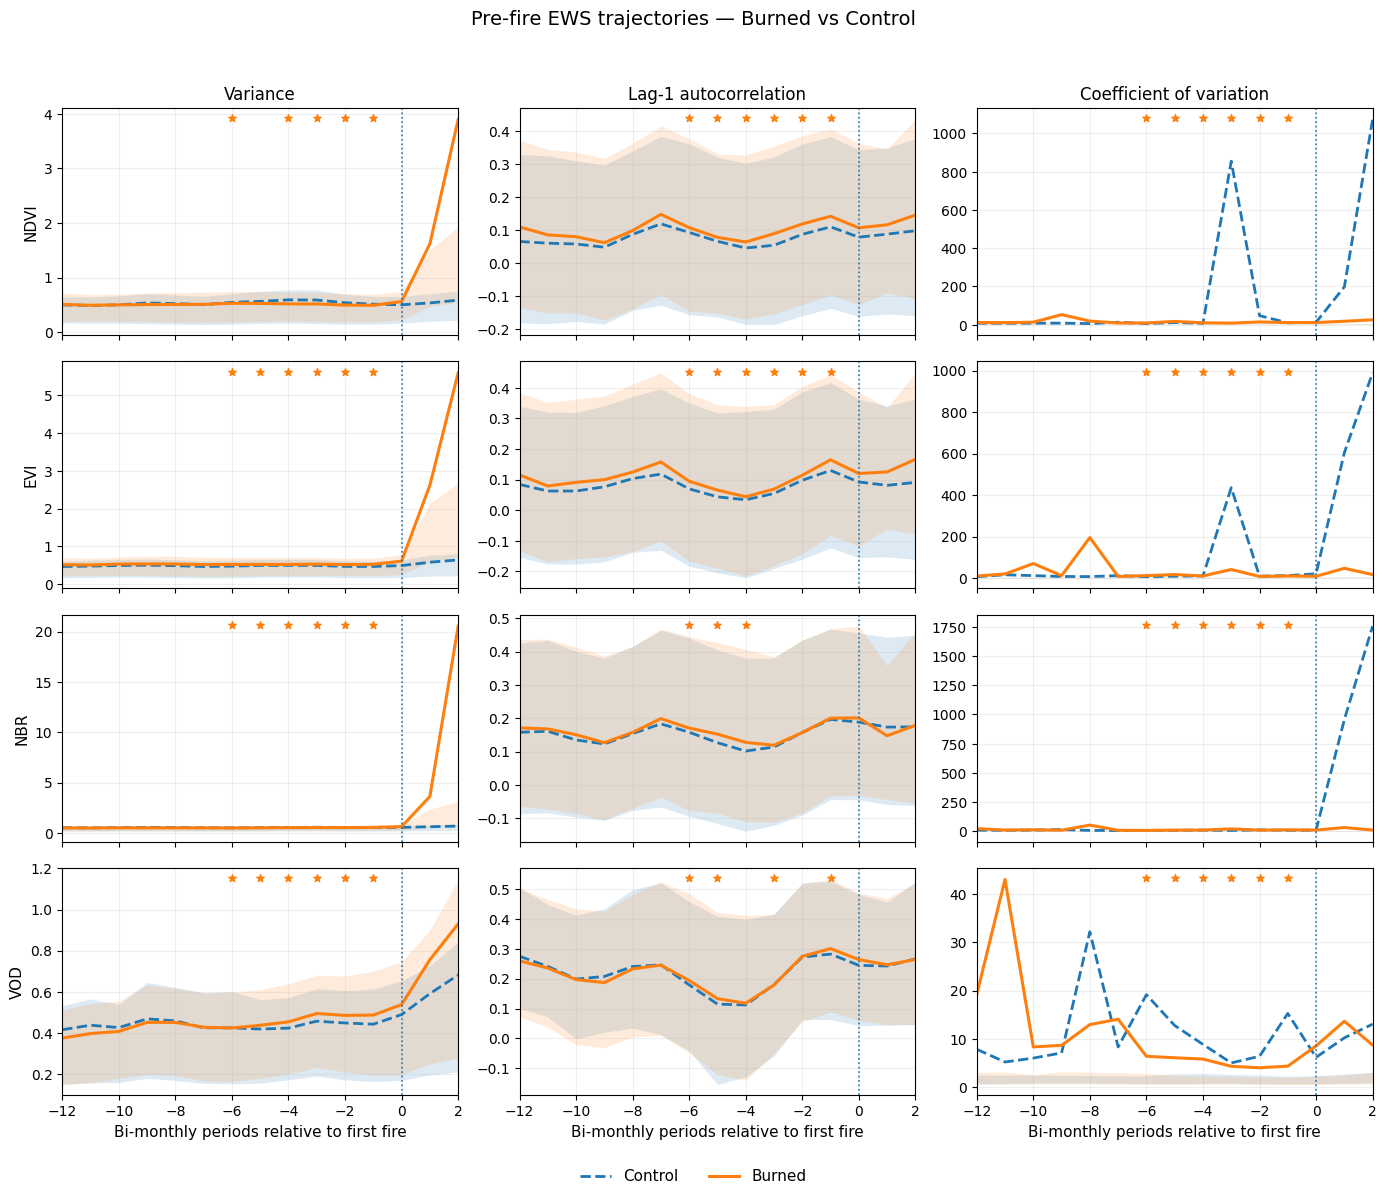


EWS-7 FINALIZADA
✔ Estatística: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/ews_case_control_paired_stats.csv
✔ QC: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/qc/ews_case_control_paired_stats_qc.csv
✔ Figura PNG: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/figures/ews_burned_control_3x4.png
✔ Figura PDF: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/figures/ews_burned_control_3x4.pdf
✔ * = Wilcoxon pareado com pFDR < 0.01


,index,metric,offset,n_pairs,median_difference,rank_biserial,wilcoxon_W,p_raw,p_fdr,significant_fdr_001
24,EVI,ac1,-6,25823,0.026359,0.059617,156774268.0,1.069376e-16,1.604064e-16,True
25,EVI,ac1,-5,26704,0.017650,0.047747,169770143.5,1.406679e-11,1.947710e-11,True
26,EVI,ac1,-4,27221,0.004794,0.018772,181775028.5,7.314390e-03,7.979335e-03,True
27,EVI,ac1,-3,28108,0.012266,0.033095,190971305.0,1.546253e-06,1.886953e-06,True
28,EVI,ac1,-2,27894,0.017394,0.039308,186879390.5,1.304240e-08,1.676880e-08,True
...,...,...,...,...,...,...,...,...,...,...
55,VOD,var,-5,25788,0.010335,0.162895,139178414.5,1.262505e-113,8.893366e-113,True
56,VOD,var,-4,26294,0.019750,0.266247,126829380.0,5.829589e-306,1.049326e-304,True
57,VOD,var,-3,27152,0.028024,0.321036,125142998.5,0.000000e+00,0.000000e+00,True
58,VOD,var,-2,26964,0.027763,0.326027,122508846.5,0.000000e+00,0.000000e+00,True


In [ ]:
# @title EWS-7 — Burned × Control: Wilcoxon pareado + FDR + painel 3×4

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, rankdata

# =========================================================
# CONFIGURAÇÃO
# =========================================================

INDICES = [
    "NDVI",
    "EVI",
    "NBR",
    "VOD"
]

METRICS = [
    "var",
    "ac1",
    "cv"
]

METRIC_LABELS = {
    "var": "Variance",
    "ac1": "Lag-1 autocorrelation",
    "cv": "Coefficient of variation"
}

# Trajetória mostrada na figura
PLOT_OFFSETS = list(
    range(-12, 3)
)

# Janela inferencial definida a priori
TEST_OFFSETS = [
    -6,
    -5,
    -4,
    -3,
    -2,
    -1
]

ALPHA = 0.01

# =========================================================
# ENTRADAS
# =========================================================

PANEL_FP = (
    TABLE_DIR /
    "ews_offset_panel_stats.csv"
)

SERIES_NPZ_DIR = (
    CONTROL_DIR /
    "series_npz"
)

assert PANEL_FP.exists(), (
    f"Rode primeiro a EWS-6: {PANEL_FP}"
)

# =========================================================
# SAÍDAS
# =========================================================

STATS_FP = (
    TABLE_DIR /
    "ews_case_control_paired_stats.csv"
)

QC_FP = (
    QC_DIR /
    "ews_case_control_paired_stats_qc.csv"
)

OUT_PNG = (
    FIG_DIR /
    "ews_burned_control_3x4.png"
)

OUT_PDF = (
    FIG_DIR /
    "ews_burned_control_3x4.pdf"
)

# =========================================================
# HELPERS
# =========================================================

def fdr_bh(pvals):

    p = np.asarray(
        pvals,
        dtype="float64"
    )

    out = np.full(
        p.shape,
        np.nan,
        dtype="float64"
    )

    finite_idx = np.where(
        np.isfinite(p)
    )[0]

    if finite_idx.size == 0:
        return out

    pv = p[
        finite_idx
    ]

    order = np.argsort(
        pv
    )

    ranked = pv[
        order
    ]

    m = len(
        ranked
    )

    adjusted = (
        ranked *
        m /
        np.arange(
            1,
            m + 1
        )
    )

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1
    )

    out[
        finite_idx[
            order
        ]
    ] = adjusted

    return out


def paired_rank_biserial(
    xb,
    xc
):

    xb = np.asarray(
        xb,
        dtype="float64"
    )

    xc = np.asarray(
        xc,
        dtype="float64"
    )

    d = xb - xc

    d = d[
        np.isfinite(d)
    ]

    d_nz = d[
        d != 0
    ]

    n_zero = int(
        d.size -
        d_nz.size
    )

    if d_nz.size == 0:

        return {
            "r_rb": 0.0,
            "R_plus": 0.0,
            "R_minus": 0.0,
            "n_nonzero": 0,
            "n_zero": n_zero
        }

    ranks = rankdata(
        np.abs(d_nz),
        method="average"
    )

    R_plus = float(
        ranks[
            d_nz > 0
        ].sum()
    )

    R_minus = float(
        ranks[
            d_nz < 0
        ].sum()
    )

    denom = (
        R_plus +
        R_minus
    )

    r_rb = (
        (R_plus - R_minus)
        /
        denom
        if denom > 0
        else np.nan
    )

    return {
        "r_rb":
            float(r_rb),

        "R_plus":
            R_plus,

        "R_minus":
            R_minus,

        "n_nonzero":
            int(d_nz.size),

        "n_zero":
            n_zero
    }


# =========================================================
# 1. ESTATÍSTICA PAREADA OFICIAL
# =========================================================

rows = []
qc_rows = []

for idx in INDICES:

    for metric in METRICS:

        npz_fp = (
            SERIES_NPZ_DIR /
            f"r3_{idx}_{metric}.npz"
        )

        assert npz_fp.exists(), (
            f"Arquivo ausente: {npz_fp}\n"
            "Rode primeiro a EWS-6."
        )

        with np.load(
            npz_fp,
            allow_pickle=False
        ) as z:

            M_b = z[
                "M_b"
            ].astype(
                "float64"
            )

            M_c = z[
                "M_c"
            ].astype(
                "float64"
            )

            offsets = z[
                "offsets"
            ].astype(
                int
            )

        assert (
            M_b.shape ==
            M_c.shape
        )

        print(
            f"\n{idx}/{metric}"
        )

        for off in TEST_OFFSETS:

            loc = np.where(
                offsets == off
            )[0]

            assert len(loc) == 1, (
                f"{idx}/{metric}: "
                f"offset {off} ausente."
            )

            j = int(
                loc[0]
            )

            xb = M_b[
                :,
                j
            ]

            xc = M_c[
                :,
                j
            ]

            # =============================================
            # PAREAMENTO COMPLETE-CASE
            # =============================================

            valid = (
                np.isfinite(xb)
                &
                np.isfinite(xc)
            )

            xb = xb[
                valid
            ]

            xc = xc[
                valid
            ]

            n_pairs = int(
                len(xb)
            )

            if n_pairs == 0:

                W_stat = np.nan
                p_raw = np.nan

                mean_b = np.nan
                mean_c = np.nan

                median_b = np.nan
                median_c = np.nan

                mean_diff = np.nan
                median_diff = np.nan

                effect = {
                    "r_rb": np.nan,
                    "R_plus": np.nan,
                    "R_minus": np.nan,
                    "n_nonzero": 0,
                    "n_zero": 0
                }

            else:

                diff = (
                    xb -
                    xc
                )

                mean_b = float(
                    np.mean(xb)
                )

                mean_c = float(
                    np.mean(xc)
                )

                median_b = float(
                    np.median(xb)
                )

                median_c = float(
                    np.median(xc)
                )

                mean_diff = float(
                    np.mean(diff)
                )

                median_diff = float(
                    np.median(diff)
                )

                effect = paired_rank_biserial(
                    xb,
                    xc
                )

                # =========================================
                # WILCOXON SIGNED-RANK
                # =========================================

                if effect[
                    "n_nonzero"
                ] == 0:

                    W_stat = 0.0
                    p_raw = 1.0

                else:

                    try:

                        res_w = wilcoxon(
                            xb,
                            xc,
                            alternative="two-sided",
                            zero_method="wilcox",
                            correction=False,
                            method="auto"
                        )

                        W_stat = float(
                            res_w.statistic
                        )

                        p_raw = float(
                            res_w.pvalue
                        )

                    except Exception as e:

                        print(
                            f"⚠ {idx}/{metric}, "
                            f"offset {off}: {e}"
                        )

                        W_stat = np.nan
                        p_raw = np.nan

            rows.append({

                "index":
                    idx,

                "metric":
                    metric,

                "offset":
                    int(off),

                "n_pairs":
                    n_pairs,

                "n_nonzero":
                    effect[
                        "n_nonzero"
                    ],

                "n_zero":
                    effect[
                        "n_zero"
                    ],

                "mean_burned":
                    mean_b,

                "mean_control":
                    mean_c,

                "median_burned":
                    median_b,

                "median_control":
                    median_c,

                "mean_difference":
                    mean_diff,

                "median_difference":
                    median_diff,

                "wilcoxon_W":
                    W_stat,

                "p_raw":
                    p_raw,

                "rank_biserial":
                    effect[
                        "r_rb"
                    ],

                "R_plus":
                    effect[
                        "R_plus"
                    ],

                "R_minus":
                    effect[
                        "R_minus"
                    ]
            })

            qc_rows.append({

                "index":
                    idx,

                "metric":
                    metric,

                "offset":
                    int(off),

                "total_pairs":
                    int(
                        M_b.shape[0]
                    ),

                "valid_pairs":
                    n_pairs,

                "valid_pct":
                    (
                        100.0 *
                        n_pairs /
                        M_b.shape[0]
                        if M_b.shape[0]
                        else np.nan
                    ),

                "zero_differences":
                    effect[
                        "n_zero"
                    ],

                "nonzero_differences":
                    effect[
                        "n_nonzero"
                    ]
            })


# =========================================================
# 2. FDR GLOBAL
#
# 4 índices × 3 métricas × 6 offsets
# = 72 comparações
# =========================================================

stats = pd.DataFrame(
    rows
)

stats[
    "p_fdr"
] = fdr_bh(
    stats[
        "p_raw"
    ].to_numpy()
)

stats[
    "significant_fdr_001"
] = (
    np.isfinite(
        stats["p_fdr"]
    )
    &
    (
        stats["p_fdr"] <
        ALPHA
    )
)

stats[
    "effect_direction"
] = np.where(
    stats["rank_biserial"] > 0,
    "Burned > Control",
    np.where(
        stats["rank_biserial"] < 0,
        "Burned < Control",
        "No directional difference"
    )
)

stats = stats.sort_values(
    [
        "index",
        "metric",
        "offset"
    ]
)

stats.to_csv(
    STATS_FP,
    index=False
)

qc = pd.DataFrame(
    qc_rows
)

qc.to_csv(
    QC_FP,
    index=False
)

print(
    "\n✔ Estatística pareada concluída."
)

print(
    "✔ Teste: Wilcoxon signed-rank"
)

print(
    "✔ Efeito: matched-pairs rank-biserial"
)

print(
    "✔ FDR global:",
    len(stats),
    "testes"
)

# =========================================================
# 3. DADOS DESCRITIVOS PARA A FIGURA
# =========================================================

df = pd.read_csv(
    PANEL_FP
)

required = {
    "index",
    "metric",
    "offset",
    "mean_b",
    "q25_b",
    "q75_b",
    "mean_c",
    "q25_c",
    "q75_c"
}

missing = (
    required -
    set(df.columns)
)

assert not missing, (
    f"Colunas ausentes no painel: {missing}"
)

df["index"] = (
    df["index"]
    .astype(str)
    .str.upper()
    .str.strip()
)

df["metric"] = (
    df["metric"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["offset"] = pd.to_numeric(
    df["offset"],
    errors="coerce"
)

df = df[
    df["index"].isin(
        INDICES
    )
    &
    df["metric"].isin(
        METRICS
    )
    &
    df["offset"].isin(
        PLOT_OFFSETS
    )
].copy()

# =========================================================
# 4. FIGURA 3×4
# =========================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig, axes = plt.subplots(
    nrows=len(INDICES),
    ncols=len(METRICS),
    figsize=(14, 12),
    sharex=True
)

for r, idx in enumerate(
    INDICES
):

    for c, metric in enumerate(
        METRICS
    ):

        ax = axes[
            r,
            c
        ]

        sub = (
            df[
                (df["index"] == idx)
                &
                (df["metric"] == metric)
            ]
            .sort_values(
                "offset"
            )
        )

        if sub.empty:

            ax.set_visible(
                False
            )

            continue

        x = sub[
            "offset"
        ].to_numpy(
            dtype=float
        )

        # =============================================
        # CONTROL
        # =============================================

        yc = sub[
            "mean_c"
        ].to_numpy(
            dtype=float
        )

        q25c = sub[
            "q25_c"
        ].to_numpy(
            dtype=float
        )

        q75c = sub[
            "q75_c"
        ].to_numpy(
            dtype=float
        )

        line_c = ax.plot(
            x,
            yc,
            linestyle="--",
            linewidth=2.0,
            label="Control"
        )[0]

        ax.fill_between(
            x,
            q25c,
            q75c,
            alpha=0.15,
            color=line_c.get_color(),
            linewidth=0
        )

        # =============================================
        # BURNED
        # =============================================

        yb = sub[
            "mean_b"
        ].to_numpy(
            dtype=float
        )

        q25b = sub[
            "q25_b"
        ].to_numpy(
            dtype=float
        )

        q75b = sub[
            "q75_b"
        ].to_numpy(
            dtype=float
        )

        line_b = ax.plot(
            x,
            yb,
            linestyle="-",
            linewidth=2.2,
            label="Burned"
        )[0]

        ax.fill_between(
            x,
            q25b,
            q75b,
            alpha=0.15,
            color=line_b.get_color(),
            linewidth=0
        )

        # =============================================
        # PRIMEIRO FOGO
        # =============================================

        ax.axvline(
            0,
            linestyle=":",
            linewidth=1.2
        )

        # =============================================
        # SIGNIFICÂNCIA
        #
        # somente -6 ... -1
        # Wilcoxon + FDR < 0.01
        # =============================================

        ss = stats[
            (stats["index"] == idx)
            &
            (stats["metric"] == metric)
            &
            (stats["p_fdr"] < ALPHA)
        ]

        if not ss.empty:

            ymin, ymax = ax.get_ylim()

            span = (
                ymax -
                ymin
            )

            if (
                not np.isfinite(span)
                or
                span == 0
            ):
                span = 1.0

            y_sig = (
                ymax -
                0.04 * span
            )

            ax.scatter(
                ss[
                    "offset"
                ].to_numpy(
                    dtype=float
                ),
                np.full(
                    len(ss),
                    y_sig
                ),
                marker="*",
                s=30,
                zorder=6,
                color=line_b.get_color()
            )

        # =============================================
        # RÓTULOS
        # =============================================

        if r == 0:

            ax.set_title(
                METRIC_LABELS[
                    metric
                ]
            )

        if c == 0:

            ax.set_ylabel(
                idx
            )

        if r == (
            len(INDICES) - 1
        ):

            ax.set_xlabel(
                "Bi-monthly periods relative to first fire"
            )

        ax.set_xlim(
            -12,
            2
        )

        ax.set_xticks(
            [
                -12,
                -10,
                -8,
                -6,
                -4,
                -2,
                0,
                2
            ]
        )

        ax.grid(
            alpha=0.20
        )

# =========================================================
# LEGENDA
# =========================================================

handles, labels = (
    axes[0, 0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(
        0.5,
        0.005
    )
)

fig.suptitle(
    "Pre-fire EWS trajectories — Burned vs Control",
    y=0.995,
    fontsize=14
)

fig.tight_layout(
    rect=[
        0,
        0.04,
        1,
        0.975
    ]
)

# =========================================================
# SALVAR FIGURA
# =========================================================

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

fig.savefig(
    OUT_PNG,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    OUT_PDF,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# RESULTADOS
# =========================================================

print("\n" + "="*70)
print("EWS-7 FINALIZADA")
print("="*70)

print(
    "✔ Estatística:",
    STATS_FP
)

print(
    "✔ QC:",
    QC_FP
)

print(
    "✔ Figura PNG:",
    OUT_PNG
)

print(
    "✔ Figura PDF:",
    OUT_PDF
)

print(
    "✔ * = Wilcoxon pareado com pFDR < 0.01"
)

display(
    stats[
        [
            "index",
            "metric",
            "offset",
            "n_pairs",
            "median_difference",
            "rank_biserial",
            "wilcoxon_W",
            "p_raw",
            "p_fdr",
            "significant_fdr_001"
        ]
    ]
)


In [ ]:
# @title EWS-7B — Tendência pré-fogo Burned × Control: Sen slope individual + Wilcoxon + FDR

import numpy as np
import pandas as pd

from scipy.stats import (
    wilcoxon,
    rankdata,
    kendalltau,
    theilslopes
)

# =========================================================
# CONFIGURAÇÃO
# =========================================================

INDICES = [
    "NDVI",
    "EVI",
    "NBR",
    "VOD"
]

METRICS = [
    "var",
    "ac1",
    "cv"
]

# janela pré-fogo definida a priori
PREFIRE_OFFSETS = np.array(
    [-6, -5, -4, -3, -2, -1],
    dtype="int16"
)

ALPHA = 0.01

SERIES_NPZ_DIR = (
    CONTROL_DIR /
    "series_npz"
)

SLOPE_DIR = (
    CONTROL_DIR /
    "prefire_slopes"
)

SLOPE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUT_FP = (
    TABLE_DIR /
    "ews_prefire_trend_burned_control.csv"
)

TRAJ_FP = (
    TABLE_DIR /
    "ews_prefire_completecase_trajectories.csv"
)

QC_FP = (
    QC_DIR /
    "ews_prefire_trend_burned_control_qc.csv"
)

# =========================================================
# FDR BENJAMINI-HOCHBERG
# =========================================================

def fdr_bh(pvals):

    p = np.asarray(
        pvals,
        dtype="float64"
    )

    out = np.full(
        p.shape,
        np.nan,
        dtype="float64"
    )

    finite = np.where(
        np.isfinite(p)
    )[0]

    if finite.size == 0:
        return out

    pv = p[finite]

    order = np.argsort(
        pv
    )

    ranked = pv[order]

    m = len(ranked)

    adj = (
        ranked *
        m /
        np.arange(
            1,
            m + 1
        )
    )

    adj = np.minimum.accumulate(
        adj[::-1]
    )[::-1]

    adj = np.clip(
        adj,
        0,
        1
    )

    out[
        finite[order]
    ] = adj

    return out


# =========================================================
# THEIL-SEN INDIVIDUAL VETORIZADO
#
# Para 6 offsets há 15 inclinações possíveis.
# Sen slope = mediana dessas 15 inclinações.
# =========================================================

def sen_slope_rows(
    M,
    x
):

    slopes = []

    k = len(x)

    for i in range(k - 1):

        for j in range(
            i + 1,
            k
        ):

            slopes.append(
                (
                    M[:, j] -
                    M[:, i]
                )
                /
                (
                    x[j] -
                    x[i]
                )
            )

    S = np.column_stack(
        slopes
    )

    return np.median(
        S,
        axis=1
    )


# =========================================================
# RANK-BISERIAL PARA DADOS PAREADOS
# =========================================================

def paired_rank_biserial(
    x,
    y
):

    d = (
        np.asarray(
            x,
            dtype="float64"
        )
        -
        np.asarray(
            y,
            dtype="float64"
        )
    )

    d = d[
        np.isfinite(d)
    ]

    d_nz = d[
        d != 0
    ]

    if d_nz.size == 0:

        return 0.0

    ranks = rankdata(
        np.abs(d_nz),
        method="average"
    )

    R_plus = ranks[
        d_nz > 0
    ].sum()

    R_minus = ranks[
        d_nz < 0
    ].sum()

    denom = (
        R_plus +
        R_minus
    )

    if denom == 0:
        return np.nan

    return float(
        (
            R_plus -
            R_minus
        )
        /
        denom
    )


# =========================================================
# WILCOXON SEGURO
# =========================================================

def wilcox_one_sample(
    x
):

    x = np.asarray(
        x,
        dtype="float64"
    )

    x = x[
        np.isfinite(x)
    ]

    nonzero = x[
        x != 0
    ]

    if nonzero.size == 0:

        return 0.0, 1.0

    try:

        res = wilcoxon(
            x,
            alternative="two-sided",
            zero_method="wilcox",
            correction=False,
            method="approx"
        )

        return (
            float(res.statistic),
            float(res.pvalue)
        )

    except Exception:

        return (
            np.nan,
            np.nan
        )


def wilcox_paired(
    x,
    y
):

    d = (
        np.asarray(
            x,
            dtype="float64"
        )
        -
        np.asarray(
            y,
            dtype="float64"
        )
    )

    d = d[
        np.isfinite(d)
    ]

    nonzero = d[
        d != 0
    ]

    if nonzero.size == 0:

        return 0.0, 1.0

    try:

        res = wilcoxon(
            x,
            y,
            alternative="two-sided",
            zero_method="wilcox",
            correction=False,
            method="approx"
        )

        return (
            float(res.statistic),
            float(res.pvalue)
        )

    except Exception:

        return (
            np.nan,
            np.nan
        )


# =========================================================
# PROCESSAMENTO
# =========================================================

rows = []
traj_rows = []
qc_rows = []

for idx in INDICES:

    for metric in METRICS:

        npz_fp = (
            SERIES_NPZ_DIR /
            f"r3_{idx}_{metric}.npz"
        )

        assert npz_fp.exists(), (
            f"Arquivo ausente: {npz_fp}"
        )

        with np.load(
            npz_fp,
            allow_pickle=False
        ) as z:

            M_b_all = z[
                "M_b"
            ].astype(
                "float64"
            )

            M_c_all = z[
                "M_c"
            ].astype(
                "float64"
            )

            offsets_all = z[
                "offsets"
            ].astype(
                int
            )

            pair_id = z[
                "pair_id"
            ].astype(
                int
            )

        # =================================================
        # COLUNAS -6 ... -1
        # =================================================

        cols = []

        for off in PREFIRE_OFFSETS:

            where = np.where(
                offsets_all == off
            )[0]

            assert len(where) == 1, (
                f"{idx}/{metric}: "
                f"offset {off} ausente."
            )

            cols.append(
                int(
                    where[0]
                )
            )

        B = M_b_all[
            :,
            cols
        ]

        C = M_c_all[
            :,
            cols
        ]

        # =================================================
        # COMPLETE CASE
        #
        # Os SEIS offsets precisam ser válidos tanto
        # para burned quanto para control.
        # =================================================

        complete = (
            np.all(
                np.isfinite(B),
                axis=1
            )
            &
            np.all(
                np.isfinite(C),
                axis=1
            )
        )

        B = B[
            complete
        ]

        C = C[
            complete
        ]

        pair_complete = pair_id[
            complete
        ]

        n = int(
            B.shape[0]
        )

        print(
            f"{idx}/{metric}: "
            f"{n:,} pares completos"
        )

        assert n > 0

        # =================================================
        # SEN SLOPE POR PAR
        # =================================================

        slope_b = sen_slope_rows(
            B,
            PREFIRE_OFFSETS
        )

        slope_c = sen_slope_rows(
            C,
            PREFIRE_OFFSETS
        )

        slope_diff = (
            slope_b -
            slope_c
        )

        # =================================================
        # SALVAR SLOPES INDIVIDUAIS
        # =================================================

        slope_fp = (
            SLOPE_DIR /
            f"prefire_slope_{idx}_{metric}.npz"
        )

        np.savez_compressed(
            slope_fp,
            pair_id=pair_complete,
            slope_burned=slope_b,
            slope_control=slope_c,
            slope_difference=slope_diff,
            offsets=PREFIRE_OFFSETS
        )

        # =================================================
        # TESTES
        # =================================================

        W_b, p_b = wilcox_one_sample(
            slope_b
        )

        W_c, p_c = wilcox_one_sample(
            slope_c
        )

        W_bc, p_bc = wilcox_paired(
            slope_b,
            slope_c
        )

        rb_bc = paired_rank_biserial(
            slope_b,
            slope_c
        )

        # =================================================
        # PROPORÇÃO DE SLOPES POSITIVOS
        # =================================================

        pct_pos_b = (
            100.0 *
            np.mean(
                slope_b > 0
            )
        )

        pct_pos_c = (
            100.0 *
            np.mean(
                slope_c > 0
            )
        )

        # =================================================
        # TRAJETÓRIA MÉDIA COMPLETE-CASE
        #
        # Apenas descritiva:
        # Kendall tau + Theil-Sen da média dos pares.
        # =================================================

        mean_b = np.mean(
            B,
            axis=0
        )

        mean_c = np.mean(
            C,
            axis=0
        )

        median_b = np.median(
            B,
            axis=0
        )

        median_c = np.median(
            C,
            axis=0
        )

        kt_b = kendalltau(
            PREFIRE_OFFSETS,
            mean_b,
            variant="b"
        )

        kt_c = kendalltau(
            PREFIRE_OFFSETS,
            mean_c,
            variant="b"
        )

        ts_b = theilslopes(
            mean_b,
            PREFIRE_OFFSETS
        )

        ts_c = theilslopes(
            mean_c,
            PREFIRE_OFFSETS
        )

        # =================================================
        # RESULTADO PRINCIPAL
        # =================================================

        rows.append({

            "index":
                idx,

            "metric":
                metric,

            "n_complete_pairs":
                n,

            "median_slope_burned":
                float(
                    np.median(
                        slope_b
                    )
                ),

            "median_slope_control":
                float(
                    np.median(
                        slope_c
                    )
                ),

            "median_slope_difference":
                float(
                    np.median(
                        slope_diff
                    )
                ),

            "mean_slope_burned":
                float(
                    np.mean(
                        slope_b
                    )
                ),

            "mean_slope_control":
                float(
                    np.mean(
                        slope_c
                    )
                ),

            "positive_slope_pct_burned":
                float(
                    pct_pos_b
                ),

            "positive_slope_pct_control":
                float(
                    pct_pos_c
                ),

            # Burned slope versus zero
            "wilcoxon_burned_W":
                W_b,

            "p_burned_vs_zero_raw":
                p_b,

            # Control slope versus zero
            "wilcoxon_control_W":
                W_c,

            "p_control_vs_zero_raw":
                p_c,

            # Burned slope versus Control slope
            "wilcoxon_slope_BC_W":
                W_bc,

            "p_slope_BC_raw":
                p_bc,

            "rank_biserial_slope_BC":
                rb_bc,

            # trajetória média agregada
            "aggregate_tau_burned":
                float(
                    kt_b.statistic
                ),

            "aggregate_tau_p_burned":
                float(
                    kt_b.pvalue
                ),

            "aggregate_sen_burned":
                float(
                    ts_b.slope
                ),

            "aggregate_tau_control":
                float(
                    kt_c.statistic
                ),

            "aggregate_tau_p_control":
                float(
                    kt_c.pvalue
                ),

            "aggregate_sen_control":
                float(
                    ts_c.slope
                )
        })

        # =================================================
        # TRAJETÓRIAS COMPLETE-CASE
        # =================================================

        for j, off in enumerate(
            PREFIRE_OFFSETS
        ):

            traj_rows.append({

                "index":
                    idx,

                "metric":
                    metric,

                "offset":
                    int(off),

                "n_pairs":
                    n,

                "mean_burned":
                    float(
                        mean_b[j]
                    ),

                "median_burned":
                    float(
                        median_b[j]
                    ),

                "mean_control":
                    float(
                        mean_c[j]
                    ),

                "median_control":
                    float(
                        median_c[j]
                    )
            })

        qc_rows.append({

            "index":
                idx,

            "metric":
                metric,

            "total_pairs":
                int(
                    M_b_all.shape[0]
                ),

            "complete_six_offset_pairs":
                n,

            "complete_pct":
                (
                    100.0 *
                    n /
                    M_b_all.shape[0]
                )
        })


# =========================================================
# TABELA PRINCIPAL
# =========================================================

res = pd.DataFrame(
    rows
)

# =========================================================
# FDR — TRÊS FAMÍLIAS INFERENCIAIS
#
# 12 testes em cada família:
#
# 1. slope Burned versus zero
# 2. slope Control versus zero
# 3. slope Burned versus slope Control
# =========================================================

res[
    "p_burned_vs_zero_fdr"
] = fdr_bh(
    res[
        "p_burned_vs_zero_raw"
    ]
)

res[
    "p_control_vs_zero_fdr"
] = fdr_bh(
    res[
        "p_control_vs_zero_raw"
    ]
)

res[
    "p_slope_BC_fdr"
] = fdr_bh(
    res[
        "p_slope_BC_raw"
    ]
)

# =========================================================
# CRITÉRIO CONSERVADOR DE SUPORTE PRÉ-FOGO
#
# Requer simultaneamente:
#
# 1. slope mediano Burned > 0
# 2. tendência Burned significativa
# 3. slope Burned > Control
# 4. diferença de slopes significativa
#
# Isso NÃO transforma automaticamente a métrica em "EWS";
# identifica padrões compatíveis com aumento pré-fogo
# diferenciado em relação ao controle.
# =========================================================

res[
    "supports_prefire_increase_vs_control"
] = (
    (
        res[
            "median_slope_burned"
        ] > 0
    )
    &
    (
        res[
            "p_burned_vs_zero_fdr"
        ] < ALPHA
    )
    &
    (
        res[
            "median_slope_difference"
        ] > 0
    )
    &
    (
        res[
            "p_slope_BC_fdr"
        ] < ALPHA
    )
)

res.to_csv(
    OUT_FP,
    index=False
)

# =========================================================
# TRAJETÓRIAS
# =========================================================

traj = pd.DataFrame(
    traj_rows
)

traj.to_csv(
    TRAJ_FP,
    index=False
)

# =========================================================
# QC
# =========================================================

qc = pd.DataFrame(
    qc_rows
)

qc.to_csv(
    QC_FP,
    index=False
)

# =========================================================
# RESULTADO
# =========================================================

print(
    "\n" +
    "="*78
)

print(
    "TENDÊNCIA PRÉ-FOGO BURNED × CONTROL FINALIZADA"
)

print(
    "="*78
)

print(
    "✔ Janela:",
    PREFIRE_OFFSETS.tolist()
)

print(
    "✔ Sen slope calculado individualmente por par"
)

print(
    "✔ Wilcoxon + FDR α =",
    ALPHA
)

print(
    "\nResultado:",
    OUT_FP
)

print(
    "Trajetórias:",
    TRAJ_FP
)

print(
    "QC:",
    QC_FP
)

display(
    res[
        [
            "index",
            "metric",
            "n_complete_pairs",
            "median_slope_burned",
            "median_slope_control",
            "median_slope_difference",
            "positive_slope_pct_burned",
            "positive_slope_pct_control",
            "p_burned_vs_zero_fdr",
            "p_slope_BC_fdr",
            "rank_biserial_slope_BC",
            "aggregate_tau_burned",
            "aggregate_sen_burned",
            "aggregate_tau_control",
            "aggregate_sen_control",
            "supports_prefire_increase_vs_control"
        ]
    ]
)

print(
    "\n=== QC complete-case ==="
)

display(
    qc
)

NDVI/var: 21,074 pares completos
NDVI/ac1: 21,068 pares completos
NDVI/cv: 21,074 pares completos
EVI/var: 21,074 pares completos
EVI/ac1: 21,068 pares completos
EVI/cv: 21,074 pares completos
NBR/var: 21,074 pares completos
NBR/ac1: 21,068 pares completos
NBR/cv: 21,074 pares completos
VOD/var: 20,231 pares completos
VOD/ac1: 20,231 pares completos
VOD/cv: 20,231 pares completos

TENDÊNCIA PRÉ-FOGO BURNED × CONTROL FINALIZADA
✔ Janela: [-6, -5, -4, -3, -2, -1]
✔ Sen slope calculado individualmente por par
✔ Wilcoxon + FDR α = 0.01

Resultado: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/ews_prefire_trend_burned_control.csv
Trajetórias: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/ews_prefire_completecase_trajectories.csv
QC: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/qc/ews_prefire_trend_burned_control_qc.csv


,index,metric,n_complete_pairs,median_slope_burned,median_slope_control,median_slope_difference,positive_slope_pct_burned,positive_slope_pct_control,p_burned_vs_zero_fdr,p_slope_BC_fdr,rank_biserial_slope_BC,aggregate_tau_burned,aggregate_sen_burned,aggregate_tau_control,aggregate_sen_control,supports_prefire_increase_vs_control
0,NDVI,var,21074,-0.002958,-0.002749,-0.000047,46.094714,45.335484,1.629927e-58,8.244930e-01,-0.001764,-0.866667,-0.009227,-0.333333,-0.008646,False
1,NDVI,ac1,21068,0.007743,0.003599,0.003025,54.115246,51.955572,3.960187e-46,5.475597e-05,0.033366,0.466667,0.016393,0.200000,0.009498,True
2,NDVI,cv,21074,-0.000212,0.004006,0.000405,49.848154,52.429534,7.593862e-02,3.431744e-01,0.007999,0.333333,0.162778,0.466667,0.489352,False
3,EVI,var,21074,-0.002209,-0.002546,0.003032,47.746038,46.939357,1.305262e-08,8.290010e-11,0.053299,0.066667,0.000456,-0.333333,-0.005660,False
4,EVI,ac1,21068,0.015843,0.015357,0.000803,56.697361,57.020125,2.309189e-146,1.002331e-01,0.014156,0.466667,0.022925,0.466667,0.020262,False
5,EVI,cv,21074,-0.013948,-0.005692,-0.010324,44.524058,47.670115,4.844349e-51,7.828017e-06,-0.037015,-0.333333,-0.894117,0.600000,1.043581,False
6,NBR,var,21074,0.002342,-0.000052,0.001241,52.434279,49.914587,4.543191e-18,1.325782e-01,0.012695,1.000000,0.011444,0.866667,0.009872,False
7,NBR,ac1,21068,0.005593,0.005562,-0.002696,52.230871,52.776723,7.099673e-28,3.486883e-02,-0.018456,0.066667,0.005845,0.333333,0.010339,False
8,NBR,cv,21074,-0.003962,0.005077,-0.003853,48.747272,51.992977,7.094309e-04,4.610395e-02,-0.017185,0.466667,1.211210,0.466667,0.528387,False
9,VOD,var,20231,0.010184,0.003743,0.003788,58.153329,54.792151,9.580191e-169,2.783453e-218,0.256652,0.866667,0.017441,0.600000,0.006117,True



=== QC complete-case ===


,index,metric,total_pairs,complete_six_offset_pairs,complete_pct
0,NDVI,var,30000,21074,70.246667
1,NDVI,ac1,30000,21068,70.226667
2,NDVI,cv,30000,21074,70.246667
3,EVI,var,30000,21074,70.246667
4,EVI,ac1,30000,21068,70.226667
5,EVI,cv,30000,21074,70.246667
6,NBR,var,30000,21074,70.246667
7,NBR,ac1,30000,21068,70.226667
8,NBR,cv,30000,21074,70.246667
9,VOD,var,30000,20231,67.436667


In [ ]:
# @title EWS-8 — Amostra estratificada por TTR corrigido por pixel

import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.transform import xy
from tqdm.auto import tqdm

# =========================================================
# CONFIGURAÇÃO
# =========================================================

INDICES = ["NDVI", "EVI", "NBR", "VOD"]

# classes oficiais de TTR
TTR_CLASSES = [
    (1, 6,  "≤6"),
    (7, 12, "7–12"),
    (13, 18, "13–18")
]

TARGET_PER_GROUP = 15_000
RANDOM_SEED = 42

# trajetória que será usada depois
MIN_OFFSET = -6
MAX_OFFSET = 18

OUT_CSV = (
    TABLE_DIR /
    "pairs_recov_by_index.csv"
)

QC_FP = (
    QC_DIR /
    "pairs_recov_by_index_qc.csv"
)

RNG = np.random.default_rng(
    RANDOM_SEED
)

# =========================================================
# PRIMEIRO FOGO
# =========================================================

assert FIRE_DATE_FP.exists()

with rio.open(FIRE_DATE_FP) as ds:

    fire = ds.read(1).astype("float32")
    fire_nodata = ds.nodata

    if fire_nodata is not None:
        try:
            if np.isfinite(fire_nodata):
                fire[fire == fire_nodata] = np.nan
        except Exception:
            pass

    H = ds.height
    W = ds.width
    FIRE_TF = ds.transform
    FIRE_CRS = ds.crs

print(
    "✔ Grade:",
    H, "×", W,
    "|", FIRE_CRS
)

# =========================================================
# FIRE YYYYMM → ÍNDICE DO CALENDÁRIO
# =========================================================

fire_i = np.full(
    (H, W),
    -1,
    dtype="int32"
)

for ym, ti in YM_TO_I.items():

    fire_i[
        fire == ym
    ] = ti

# =========================================================
# JANELA TEMPORAL COMPLETA
#
# Precisamos ter EWS disponível em:
#   fire - 6 ... fire + 18
#
# E como o rolling W=8 começa em target_i = 8:
#
#   fire_i - 6 >= W_ROLL
#
# =========================================================

min_fire_i = (
    W_ROLL
    -
    MIN_OFFSET
)

max_fire_i = (
    len(YMS) - 1
    -
    MAX_OFFSET
)

full_window = (
    (fire_i >= min_fire_i)
    &
    (fire_i <= max_fire_i)
)

print(
    "✔ Pixels com janela temporal completa:",
    f"{full_window.sum():,}"
)

print(
    "  Primeiro fire permitido:",
    YMS[min_fire_i]
)

print(
    "  Último fire permitido:",
    YMS[max_fire_i]
)

# =========================================================
# PROCESSAMENTO POR ÍNDICE
# =========================================================

rows = []
qc_rows = []

for idx in tqdm(
    INDICES,
    desc="Classes de TTR"
):

    # -----------------------------------------------------
    # TTR corrigido
    # -----------------------------------------------------

    TTR_FP = (
        REC_DIR /
        f"ttr_time_{idx}_bimestres.tif"
    )

    STATUS_FP = (
        REC_DIR /
        f"ttr_status_{idx}.tif"
    )

    assert TTR_FP.exists(), (
        f"TTR não encontrado: {TTR_FP}"
    )

    assert STATUS_FP.exists(), (
        f"Status não encontrado: {STATUS_FP}"
    )

    # -----------------------------------------------------
    # leitura + guard-rail espacial
    # -----------------------------------------------------

    with rio.open(TTR_FP) as ds_ttr:

        assert ds_ttr.height == H
        assert ds_ttr.width == W
        assert str(ds_ttr.crs) == str(FIRE_CRS)

        assert np.allclose(
            np.array(ds_ttr.transform)[:6],
            np.array(FIRE_TF)[:6],
            atol=1e-6
        )

        ttr = ds_ttr.read(
            1
        ).astype("float32")

        nod = ds_ttr.nodata

        if nod is not None:

            try:
                if np.isfinite(nod):
                    ttr[ttr == nod] = np.nan
            except Exception:
                pass

    with rio.open(STATUS_FP) as ds_status:

        assert ds_status.height == H
        assert ds_status.width == W
        assert str(ds_status.crs) == str(FIRE_CRS)

        status = ds_status.read(
            1
        ).astype("uint8")

    # =====================================================
    # ELEGIBILIDADE
    #
    # status 1 =
    # impacto detectável + recuperação observada
    # =====================================================

    eligible = (
        np.isfinite(fire)
        &
        np.isfinite(ttr)
        &
        (status == 1)
        &
        full_window
    )

    print(
        f"\n{idx}: elegíveis = "
        f"{eligible.sum():,}"
    )

    # =====================================================
    # CLASSES
    # =====================================================

    for lo, hi, label in TTR_CLASSES:

        mask = (
            eligible
            &
            (ttr >= lo)
            &
            (ttr <= hi)
        )

        flat = np.flatnonzero(
            mask
        )

        n_available = int(
            flat.size
        )

        if n_available == 0:

            qc_rows.append({
                "index": idx,
                "group": label,
                "available": 0,
                "sampled": 0
            })

            print(
                f"  {label}: 0"
            )

            continue

        n_take = min(
            TARGET_PER_GROUP,
            n_available
        )

        picked = RNG.choice(
            flat,
            size=n_take,
            replace=False
        )

        rr, cc = np.unravel_index(
            picked,
            (H, W)
        )

        # ---------------------------------------------
        # coordenadas do centro do pixel
        # ---------------------------------------------

        xs, ys = xy(
            FIRE_TF,
            rr,
            cc,
            offset="center"
        )

        xs = np.asarray(
            xs,
            dtype="float64"
        )

        ys = np.asarray(
            ys,
            dtype="float64"
        )

        fire_sel = fire[
            rr,
            cc
        ].astype(
            "int32"
        )

        ttr_sel = ttr[
            rr,
            cc
        ].astype(
            "int16"
        )

        # ---------------------------------------------
        # salvar uma linha por pixel
        # ---------------------------------------------

        for r, c, x, y, fym, tv in zip(
            rr,
            cc,
            xs,
            ys,
            fire_sel,
            ttr_sel
        ):

            rows.append({

                "index":
                    idx,

                "group":
                    label,

                "row":
                    int(r),

                "col":
                    int(c),

                "x":
                    float(x),

                "y":
                    float(y),

                "fire_ym":
                    int(fym),

                "ttr_bi":
                    int(tv),

                "ttr_status":
                    1
            })

        qc_rows.append({

            "index":
                idx,

            "group":
                label,

            "available":
                n_available,

            "sampled":
                n_take,

            "sample_fraction_pct":
                (
                    100.0 *
                    n_take /
                    n_available
                )
        })

        print(
            f"  {label}: "
            f"available={n_available:,} | "
            f"sampled={n_take:,}"
        )

# =========================================================
# SALVAR
# =========================================================

pairs_ttr = pd.DataFrame(
    rows
)

assert not pairs_ttr.empty, (
    "Nenhuma amostra TTR foi criada."
)

pairs_ttr = (
    pairs_ttr
    .sort_values(
        [
            "index",
            "group",
            "fire_ym",
            "row",
            "col"
        ]
    )
    .reset_index(drop=True)
)

pairs_ttr.to_csv(
    OUT_CSV,
    index=False
)

df_qc = pd.DataFrame(
    qc_rows
)

df_qc.to_csv(
    QC_FP,
    index=False
)

# =========================================================
# RESUMO
# =========================================================

print("\n" + "="*65)
print("AMOSTRA ESTRATIFICADA POR TTR FINALIZADA")
print("="*65)

display(
    df_qc
)

print(
    "\nTotal amostrado:",
    f"{len(pairs_ttr):,}"
)

print(
    "\n✔ CSV:",
    OUT_CSV
)

print(
    "✔ QC:",
    QC_FP
)


✔ Grade: 2448 × 1612 | EPSG:31983
✔ Pixels com janela temporal completa: 660,985
  Primeiro fire permitido: 199001
  Último fire permitido: 201811


Classes de TTR:   0%|          | 0/4 [00:00<?, ?it/s]


NDVI: elegíveis = 572,827
  ≤6: available=293,130 | sampled=15,000
  7–12: available=267,395 | sampled=15,000
  13–18: available=12,302 | sampled=12,302

EVI: elegíveis = 553,056
  ≤6: available=299,852 | sampled=15,000
  7–12: available=243,036 | sampled=15,000
  13–18: available=10,168 | sampled=10,168

NBR: elegíveis = 609,831
  ≤6: available=333,163 | sampled=15,000
  7–12: available=261,927 | sampled=15,000
  13–18: available=14,741 | sampled=14,741

VOD: elegíveis = 429,947
  ≤6: available=342,050 | sampled=15,000
  7–12: available=87,535 | sampled=15,000
  13–18: available=362 | sampled=362

AMOSTRA ESTRATIFICADA POR TTR FINALIZADA


,index,group,available,sampled,sample_fraction_pct
0,NDVI,≤6,293130,15000,5.117184
1,NDVI,7–12,267395,15000,5.609679
2,NDVI,13–18,12302,12302,100.000000
3,EVI,≤6,299852,15000,5.002468
4,EVI,7–12,243036,15000,6.171925
5,EVI,13–18,10168,10168,100.000000
6,NBR,≤6,333163,15000,4.502301
7,NBR,7–12,261927,15000,5.726786
8,NBR,13–18,14741,14741,100.000000
9,VOD,≤6,342050,15000,4.385324



Total amostrado: 157,573

✔ CSV: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/pairs_recov_by_index.csv
✔ QC: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/qc/pairs_recov_by_index_qc.csv


In [ ]:
# @title EWS-9 — Trajetórias EWS por classes de TTR (−6..+18)

import re
import gc
import numpy as np
import pandas as pd
import rasterio as rio
from tqdm.auto import tqdm

# =========================================================
# CONFIGURAÇÃO
# =========================================================

INDICES = ["NDVI", "EVI", "NBR", "VOD"]
METRICS = ["var", "ac1", "cv"]

GROUPS = [
    "≤6",
    "7–12",
    "13–18"
]

# offsets em BIMESTRES
OFFSETS = np.arange(
    -6,
    19,
    dtype="int16"
)

SAMPLE_FP = (
    TABLE_DIR /
    "pairs_recov_by_index.csv"
)

assert SAMPLE_FP.exists(), (
    f"Rode a EWS-8 primeiro: {SAMPLE_FP}"
)

samples = pd.read_csv(
    SAMPLE_FP
)

# =========================================================
# SAÍDAS
# =========================================================

TTR_PANEL_DIR = (
    TREND_DIR /
    "ttr_panel_ckpt"
)

TTR_SERIES_DIR = (
    TREND_DIR /
    "ttr_series_npz"
)

TTR_PANEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TTR_SERIES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUT_CSV = (
    TABLE_DIR /
    "p3_offset_panel_stats_by_TTR.csv"
)

QC_FP = (
    QC_DIR /
    "p3_ttr_trajectory_qc.csv"
)

# =========================================================
# CHECKS DA AMOSTRA
# =========================================================

required = {
    "index",
    "group",
    "row",
    "col",
    "fire_ym",
    "ttr_bi",
    "ttr_status"
}

missing = (
    required -
    set(samples.columns)
)

assert not missing, (
    f"Colunas ausentes: {missing}"
)

samples["index"] = (
    samples["index"]
    .astype(str)
    .str.upper()
    .str.strip()
)

samples["group"] = (
    samples["group"]
    .astype(str)
    .str.strip()
)

samples = samples[
    samples["index"].isin(INDICES)
    &
    samples["group"].isin(GROUPS)
    &
    (samples["ttr_status"] == 1)
].copy()

print(
    "✔ Pixels na amostra:",
    f"{len(samples):,}"
)

print("\nAmostra por índice × classe:")

display(
    samples.groupby(
        ["index", "group"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(columns=GROUPS)
)

# =========================================================
# CATÁLOGO DOS EWS DA EWS-4
# =========================================================

def build_ews_catalog(idx, metric):

    folder = (
        ROLLING_DIR /
        idx
    )

    assert folder.exists(), (
        f"Pasta não encontrada: {folder}"
    )

    pattern = re.compile(
        rf"^{idx}_rolling_{metric}_prefire_"
        rf"(\d{{6}})_300m\.tif$",
        re.IGNORECASE
    )

    cat = {}

    for fp in folder.glob("*.tif"):

        m = pattern.match(
            fp.name
        )

        if not m:
            continue

        ym = int(
            m.group(1)
        )

        if ym in YM_TO_I:
            cat[ym] = fp

    return dict(
        sorted(cat.items())
    )


# =========================================================
# LEITOR
# =========================================================

def read_ews_array(fp):

    with rio.open(fp) as ds:

        a = ds.read(
            1
        ).astype(
            "float32"
        )

        nod = ds.nodata

        if nod is not None:

            try:

                if np.isfinite(nod):
                    a[a == nod] = np.nan

            except Exception:
                pass

    a[
        ~np.isfinite(a)
    ] = np.nan

    return a


# =========================================================
# PROCESSAMENTO
# =========================================================

all_rows = []
qc_rows = []

for idx in INDICES:

    sub = (
        samples[
            samples["index"] == idx
        ]
        .reset_index(drop=True)
        .copy()
    )

    if sub.empty:

        print(
            f"⚠ {idx}: sem amostra"
        )

        continue

    # -----------------------------------------------------
    # posições
    # -----------------------------------------------------

    rr = sub[
        "row"
    ].to_numpy(
        dtype="int32"
    )

    cc = sub[
        "col"
    ].to_numpy(
        dtype="int32"
    )

    fire_ym = sub[
        "fire_ym"
    ].to_numpy(
        dtype="int32"
    )

    groups = sub[
        "group"
    ].astype(str).to_numpy()

    ttr_bi = sub[
        "ttr_bi"
    ].to_numpy(
        dtype="int16"
    )

    N = len(sub)
    T = len(OFFSETS)

    # -----------------------------------------------------
    # first-fire → índice do calendário
    # -----------------------------------------------------

    event_i = np.array(
        [
            YM_TO_I.get(
                int(ym),
                -1
            )
            for ym in fire_ym
        ],
        dtype="int32"
    )

    assert np.all(
        event_i >= 0
    ), (
        f"{idx}: há fire_ym fora do calendário."
    )

    # -----------------------------------------------------
    # YYYYMM alvo por pixel × offset
    #
    # CORRETO:
    # índice temporal + offset bimestral
    # -----------------------------------------------------

    target_i = (
        event_i[:, None]
        +
        OFFSETS[None, :]
    )

    assert np.all(
        target_i >= 0
    )

    assert np.all(
        target_i < len(YMS)
    )

    unique_ti = np.unique(
        target_i
    )

    print("\n" + "="*65)
    print(idx)
    print("="*65)

    # =====================================================
    # CADA MÉTRICA
    # =====================================================

    for metric in METRICS:

        panel_fp = (
            TTR_PANEL_DIR /
            f"p3_ttr_{idx}_{metric}.csv"
        )

        npz_fp = (
            TTR_SERIES_DIR /
            f"ttr_{idx}_{metric}.npz"
        )

        # -------------------------------------------------
        # CHECKPOINT
        # -------------------------------------------------

        if (
            panel_fp.exists()
            and
            npz_fp.exists()
        ):

            print(
                f"• {idx}/{metric}: checkpoint"
            )

            old = pd.read_csv(
                panel_fp
            )

            all_rows.extend(
                old.to_dict(
                    "records"
                )
            )

            continue

        cat = build_ews_catalog(
            idx,
            metric
        )

        assert cat, (
            f"Sem rasters EWS: "
            f"{idx}/{metric}"
        )

        # -------------------------------------------------
        # MATRIZ:
        # pixel × offset
        # -------------------------------------------------

        M = np.full(
            (N, T),
            np.nan,
            dtype="float32"
        )

        # =================================================
        # CADA DATA É ABERTA APENAS UMA VEZ
        # =================================================

        for ti in tqdm(
            unique_ti,
            desc=f"{idx}/{metric}",
            leave=False
        ):

            ti = int(ti)

            ym = YMS[
                ti
            ]

            fp = cat.get(
                ym
            )

            if fp is None:
                continue

            a = read_ews_array(
                fp
            )

            # quais pixels/offsets pedem esta data?
            pp, oo = np.where(
                target_i == ti
            )

            M[
                pp,
                oo
            ] = a[
                rr[pp],
                cc[pp]
            ]

            del a
            gc.collect()

        # =================================================
        # SALVAR MATRIZ INDIVIDUAL
        #
        # Isso preserva pixels × offsets para os
        # testes estatísticos posteriores.
        # =================================================

        tmp_npz = (
            TTR_SERIES_DIR /
            f"tmp_ttr_{idx}_{metric}.npz"
        )

        np.savez_compressed(
            tmp_npz,
            M=M,
            offsets=OFFSETS,
            group=groups.astype("U10"),
            row=rr,
            col=cc,
            fire_ym=fire_ym,
            ttr_bi=ttr_bi,
            index=np.array(idx),
            metric=np.array(metric)
        )

        tmp_npz.replace(
            npz_fp
        )

        # =================================================
        # RESUMO POR CLASSE × OFFSET
        # =================================================

        rows_metric = []

        for group in GROUPS:

            gmask = (
                groups == group
            )

            n_group = int(
                gmask.sum()
            )

            if n_group == 0:
                continue

            for j, off in enumerate(
                OFFSETS
            ):

                vals = M[
                    gmask,
                    j
                ]

                vals = vals[
                    np.isfinite(vals)
                ]

                n = int(
                    vals.size
                )

                if n == 0:

                    mean = np.nan
                    q25 = np.nan
                    q75 = np.nan

                else:

                    mean = float(
                        np.nanmean(vals)
                    )

                    q25, q75 = (
                        np.nanpercentile(
                            vals,
                            [25, 75]
                        )
                    )

                    q25 = float(q25)
                    q75 = float(q75)

                row = {

                    "index":
                        idx,

                    "group":
                        group,

                    "metric":
                        metric,

                    "offset":
                        int(off),

                    "mean":
                        mean,

                    "q25":
                        q25,

                    "q75":
                        q75,

                    "n":
                        n,

                    "n_group":
                        n_group,

                    "valid_pct":
                        (
                            100.0 *
                            n /
                            n_group
                            if n_group
                            else np.nan
                        )
                }

                rows_metric.append(
                    row
                )

                qc_rows.append({

                    "index":
                        idx,

                    "metric":
                        metric,

                    "group":
                        group,

                    "offset":
                        int(off),

                    "sampled":
                        n_group,

                    "valid":
                        n,

                    "valid_pct":
                        (
                            100.0 *
                            n /
                            n_group
                            if n_group
                            else np.nan
                        )
                })

        df_metric = pd.DataFrame(
            rows_metric
        )

        df_metric.to_csv(
            panel_fp,
            index=False
        )

        all_rows.extend(
            rows_metric
        )

        print(
            f"✔ {idx}/{metric} | "
            f"n mínimo={df_metric['n'].min():,} | "
            f"n máximo={df_metric['n'].max():,}"
        )

        del M
        gc.collect()


# =========================================================
# CONSOLIDAR
# =========================================================

panel = (
    pd.DataFrame(
        all_rows
    )
    .drop_duplicates(
        subset=[
            "index",
            "group",
            "metric",
            "offset"
        ],
        keep="last"
    )
)

# ordem explícita
panel["index"] = pd.Categorical(
    panel["index"],
    categories=INDICES,
    ordered=True
)

panel["metric"] = pd.Categorical(
    panel["metric"],
    categories=METRICS,
    ordered=True
)

panel["group"] = pd.Categorical(
    panel["group"],
    categories=GROUPS,
    ordered=True
)

panel = panel.sort_values(
    [
        "index",
        "metric",
        "group",
        "offset"
    ]
)

panel.to_csv(
    OUT_CSV,
    index=False
)

# =========================================================
# QC
# =========================================================

df_qc = pd.DataFrame(
    qc_rows
)

if not df_qc.empty:

    df_qc.to_csv(
        QC_FP,
        index=False
    )

# =========================================================
# RESULTADO
# =========================================================

print("\n" + "="*65)
print("TRAJETÓRIAS EWS × TTR FINALIZADAS")
print("="*65)

print(
    "✔ Painel:",
    OUT_CSV
)

print(
    "✔ Séries individuais:",
    TTR_SERIES_DIR
)

print(
    "✔ QC:",
    QC_FP
)

display(
    panel.head(30)
)


✔ Pixels na amostra: 157,573

Amostra por índice × classe:


group,≤6,7–12,13–18
index,,,
EVI,15000,15000,10168
NBR,15000,15000,14741
NDVI,15000,15000,12302
VOD,15000,15000,362



NDVI


NDVI/var:   0%|          | 0/198 [00:00<?, ?it/s]

✔ NDVI/var | n mínimo=12,145 | n máximo=15,000


...

VOD/ac1:   0%|          | 0/197 [00:00<?, ?it/s]

✔ VOD/ac1 | n mínimo=362 | n máximo=15,000


VOD/cv:   0%|          | 0/197 [00:00<?, ?it/s]

✔ VOD/cv | n mínimo=362 | n máximo=15,000

TRAJETÓRIAS EWS × TTR FINALIZADAS
✔ Painel: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/p3_offset_panel_stats_by_TTR.csv
✔ Séries individuais: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/trend/ttr_series_npz
✔ QC: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/qc/p3_ttr_trajectory_qc.csv


,index,group,metric,offset,mean,q25,q75,n,n_group,valid_pct
0,NDVI,≤6,var,-6,0.597442,0.258551,0.833506,14999,15000,99.993333
1,NDVI,≤6,var,-5,0.584168,0.265580,0.801045,14999,15000,99.993333
2,NDVI,≤6,var,-4,0.581577,0.269486,0.796269,14999,15000,99.993333
3,NDVI,≤6,var,-3,0.574633,0.258099,0.793023,14999,15000,99.993333
4,NDVI,≤6,var,-2,0.570445,0.255637,0.796490,14998,15000,99.986667
5,NDVI,≤6,var,-1,0.551688,0.249422,0.773585,14998,15000,99.986667
6,NDVI,≤6,var,0,0.573961,0.273937,0.778108,14998,15000,99.986667
7,NDVI,≤6,var,1,25.607943,0.509155,1.611478,15000,15000,100.000000
8,NDVI,≤6,var,2,26.468452,0.609289,2.064973,15000,15000,100.000000
9,NDVI,≤6,var,3,74.445419,0.680209,2.446909,15000,15000,100.000000


=== Disponibilidade por índice × métrica × TTR ===


min   median    max
index metric group                       
EVI   ac1    13–18   9644  10133.0  10168
             7–12   14864  14990.0  15000
             ≤6     14739  14988.0  15000
      cv     13–18  10023  10165.0  10168
             7–12   14968  14999.0  15000
             ≤6     14960  14999.0  15000
      var    13–18  10023  10165.0  10168
             7–12   14968  14999.0  15000
             ≤6     14960  14999.0  15000
NBR   ac1    13–18  14399  14721.0  14736
             7–12   14946  14984.0  14999
             ≤6     14746  14981.0  14997
      cv     13–18  14633  14732.0  14739
             7–12   14983  14998.0  15000
             ≤6     14961  14997.0  14999
      var    13–18  14633  14732.0  14739
             7–12   14983  14998.0  15000
             ≤6     14961  14997.0  14999
NDVI  ac1    13–18  11567  12294.0  12302
             7–12   14912  14996.0  15000
             ≤6     14760  14978.0  15000
      cv     13–18  12145  12300.0  12302
             7–12   14981  15000.0  15000
             ≤6     14958  14998.0  15000
      var    13–18  12145  12300.0  12302
             7–12   14981  15000.0  15000
             ≤6     14958  14998.0  15000
VOD   ac1    13–18    362    362.0    362
             7–12   15000  15000.0  15000
             ≤6     15000  15000.0  15000
      cv     13–18    362    362.0    362
             7–12   15000  15000.0  15000
             ≤6     15000  15000.0  15000
      var    13–18    362    362.0    362
             7–12   15000  15000.0  15000
             ≤6     15000  15000.0  15000

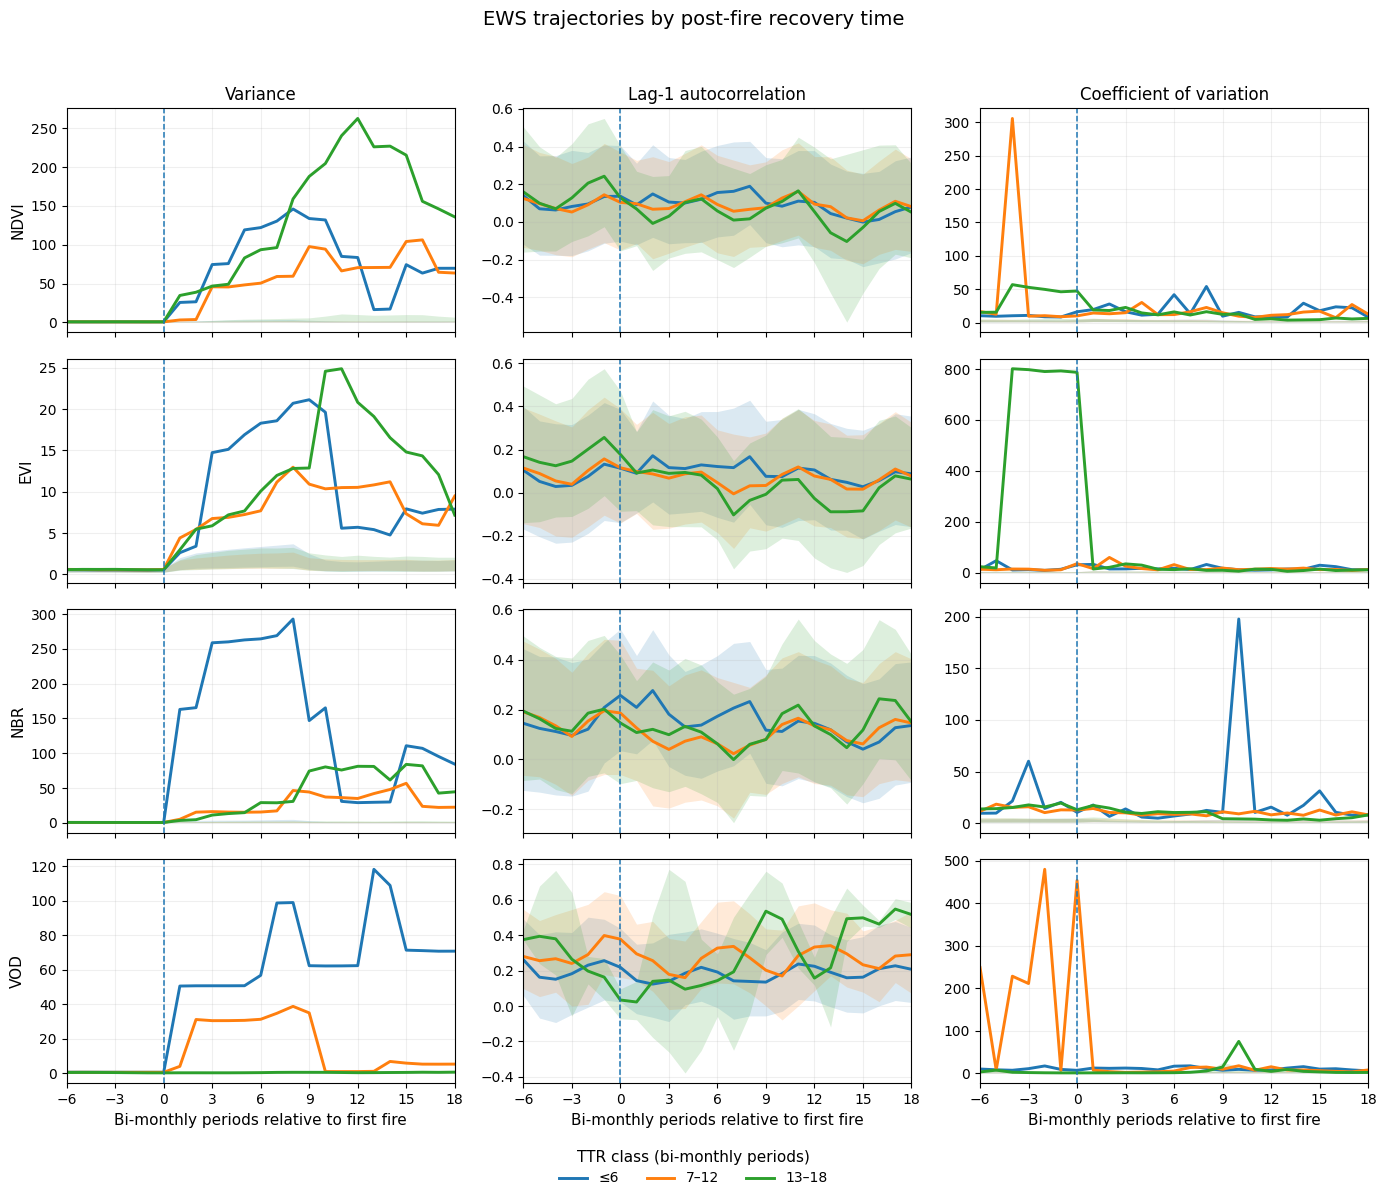

✔ PNG: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/figures/ews_trajectories_by_TTR_3x4.png
✔ PDF: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/figures/ews_trajectories_by_TTR_3x4.pdf


In [ ]:
# @title EWS-10 — Painel 3×4 das trajetórias EWS por classes de TTR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# ENTRADAS / SAÍDAS
# =========================================================

IN_CSV = (
    TABLE_DIR /
    "p3_offset_panel_stats_by_TTR.csv"
)

OUT_PNG = (
    FIG_DIR /
    "ews_trajectories_by_TTR_3x4.png"
)

OUT_PDF = (
    FIG_DIR /
    "ews_trajectories_by_TTR_3x4.pdf"
)

assert IN_CSV.exists(), (
    f"CSV não encontrado: {IN_CSV}"
)

df = pd.read_csv(
    IN_CSV
)

# =========================================================
# CONFIGURAÇÃO
# =========================================================

INDICES = [
    "NDVI",
    "EVI",
    "NBR",
    "VOD"
]

METRICS = [
    "var",
    "ac1",
    "cv"
]

GROUPS = [
    "≤6",
    "7–12",
    "13–18"
]

METRIC_LABELS = {
    "var": "Variance",
    "ac1": "Lag-1 autocorrelation",
    "cv": "Coefficient of variation"
}

# =========================================================
# CHECKS
# =========================================================

required = {
    "index",
    "group",
    "metric",
    "offset",
    "mean",
    "q25",
    "q75",
    "n"
}

missing = (
    required -
    set(df.columns)
)

assert not missing, (
    f"Colunas ausentes: {missing}"
)

df["index"] = (
    df["index"]
    .astype(str)
    .str.upper()
    .str.strip()
)

df["metric"] = (
    df["metric"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["group"] = (
    df["group"]
    .astype(str)
    .str.strip()
)

df["offset"] = pd.to_numeric(
    df["offset"],
    errors="coerce"
)

df = df[
    df["index"].isin(INDICES)
    &
    df["metric"].isin(METRICS)
    &
    df["group"].isin(GROUPS)
    &
    df["offset"].between(-6, 18)
].copy()

# =========================================================
# DISPONIBILIDADE
# =========================================================

print(
    "=== Disponibilidade por índice × métrica × TTR ==="
)

display(
    df.groupby(
        [
            "index",
            "metric",
            "group"
        ]
    )["n"]
    .agg(
        ["min", "median", "max"]
    )
)

# =========================================================
# ESTILO
# =========================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig, axes = plt.subplots(
    nrows=len(INDICES),
    ncols=len(METRICS),
    figsize=(14, 12),
    sharex=True
)

# =========================================================
# PAINÉIS
# =========================================================

for r, idx in enumerate(
    INDICES
):

    for c, metric in enumerate(
        METRICS
    ):

        ax = axes[
            r,
            c
        ]

        sub = df[
            (df["index"] == idx)
            &
            (df["metric"] == metric)
        ].copy()

        if sub.empty:

            ax.set_visible(
                False
            )

            continue

        # =============================================
        # CADA CLASSE DE TTR
        # =============================================

        for group in GROUPS:

            sg = (
                sub[
                    sub["group"] == group
                ]
                .sort_values(
                    "offset"
                )
            )

            if sg.empty:
                continue

            x = sg[
                "offset"
            ].to_numpy(
                dtype=float
            )

            y = sg[
                "mean"
            ].to_numpy(
                dtype=float
            )

            q25 = sg[
                "q25"
            ].to_numpy(
                dtype=float
            )

            q75 = sg[
                "q75"
            ].to_numpy(
                dtype=float
            )

            # -----------------------------------------
            # linha média
            # -----------------------------------------

            line = ax.plot(
                x,
                y,
                linewidth=2.1,
                label=group
            )[0]

            # -----------------------------------------
            # faixa interquartil
            # mesma cor da linha
            # -----------------------------------------

            ax.fill_between(
                x,
                q25,
                q75,
                alpha=0.16,
                color=line.get_color(),
                linewidth=0
            )

        # =============================================
        # PRIMEIRO FOGO
        # =============================================

        ax.axvline(
            0,
            linestyle="--",
            linewidth=1.1
        )

        # =============================================
        # TÍTULOS / EIXOS
        # =============================================

        if r == 0:

            ax.set_title(
                METRIC_LABELS[
                    metric
                ]
            )

        if c == 0:

            ax.set_ylabel(
                idx
            )

        if r == (
            len(INDICES) - 1
        ):

            ax.set_xlabel(
                "Bi-monthly periods relative to first fire"
            )

        ax.set_xlim(
            -6,
            18
        )

        ax.set_xticks(
            np.arange(
                -6,
                19,
                3
            )
        )

        ax.grid(
            alpha=0.20
        )

# =========================================================
# LEGENDA ÚNICA
# =========================================================

handles, labels = (
    axes[0, 0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    title="TTR class (bi-monthly periods)",
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(
        0.5,
        0.005
    )
)

# =========================================================
# TÍTULO
# =========================================================

fig.suptitle(
    "EWS trajectories by post-fire recovery time",
    y=0.995,
    fontsize=14
)

fig.tight_layout(
    rect=[
        0,
        0.05,
        1,
        0.975
    ]
)

# =========================================================
# SALVAR
# =========================================================

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

fig.savefig(
    OUT_PNG,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    OUT_PDF,
    bbox_inches="tight"
)

plt.show()

print(
    "✔ PNG:",
    OUT_PNG
)

print(
    "✔ PDF:",
    OUT_PDF
)



In [ ]:
# @title EWS-11 — Direction table por TTR: Kendall τ + Theil–Sen + FDR

import numpy as np
import pandas as pd

from scipy.stats import kendalltau, theilslopes

# =========================================================
# ENTRADA / SAÍDA
# =========================================================

IN_CSV = (
    TABLE_DIR /
    "p3_offset_panel_stats_by_TTR.csv"
)

OUT_LONG = (
    TABLE_DIR /
    "p3_direction_table_TTR_long.csv"
)

OUT_WIDE = (
    TABLE_DIR /
    "p3_direction_table_TTR_wide.csv"
)

assert IN_CSV.exists(), (
    f"CSV não encontrado: {IN_CSV}"
)

# =========================================================
# CONFIGURAÇÃO
# =========================================================

INDICES = [
    "NDVI",
    "EVI",
    "NBR",
    "VOD"
]

METRICS = [
    "var",
    "ac1",
    "cv"
]

# ordem desejada na tabela final:
# recuperação lenta → rápida
GROUPS = [
    "13–18",
    "7–12",
    "≤6"
]

POST_MIN = 1
POST_MAX = 18

# =========================================================
# FDR BENJAMINI-HOCHBERG
# =========================================================

def fdr_bh(pvals):

    p = np.asarray(
        pvals,
        dtype="float64"
    )

    out = np.full(
        p.shape,
        np.nan,
        dtype="float64"
    )

    finite = np.where(
        np.isfinite(p)
    )[0]

    if finite.size == 0:
        return out

    pv = p[
        finite
    ]

    order = np.argsort(
        pv
    )

    ranked = pv[
        order
    ]

    m = len(
        ranked
    )

    adjusted = (
        ranked
        *
        m
        /
        np.arange(
            1,
            m + 1
        )
    )

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1
    )

    out[
        finite[
            order
        ]
    ] = adjusted

    return out


def pstars(p):

    if not np.isfinite(p):
        return ""

    if p < 0.001:
        return "***"

    if p < 0.01:
        return "**"

    if p < 0.05:
        return "*"

    return ""


# =========================================================
# DADOS
# =========================================================

df = pd.read_csv(
    IN_CSV
)

required = {
    "index",
    "group",
    "metric",
    "offset",
    "mean"
}

missing = (
    required -
    set(df.columns)
)

assert not missing, (
    f"Colunas ausentes: {missing}"
)

df["index"] = (
    df["index"]
    .astype(str)
    .str.upper()
    .str.strip()
)

df["metric"] = (
    df["metric"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["group"] = (
    df["group"]
    .astype(str)
    .str.strip()
)

df["offset"] = pd.to_numeric(
    df["offset"],
    errors="coerce"
)

df["mean"] = pd.to_numeric(
    df["mean"],
    errors="coerce"
)

df = df[
    df["index"].isin(INDICES)
    &
    df["metric"].isin(METRICS)
    &
    df["group"].isin(GROUPS)
    &
    df["offset"].between(
        POST_MIN,
        POST_MAX
    )
].copy()

# =========================================================
# KENDALL τ + THEIL–SEN
# =========================================================

rows = []

for idx in INDICES:

    for metric in METRICS:

        for group in GROUPS:

            sub = (
                df[
                    (df["index"] == idx)
                    &
                    (df["metric"] == metric)
                    &
                    (df["group"] == group)
                ]
                .sort_values(
                    "offset"
                )
                .copy()
            )

            valid = (
                np.isfinite(
                    sub["offset"]
                )
                &
                np.isfinite(
                    sub["mean"]
                )
            )

            sub = sub[
                valid
            ]

            npoints = len(
                sub
            )

            if npoints < 3:

                tau = np.nan
                p_raw = np.nan
                beta = np.nan

            else:

                x = sub[
                    "offset"
                ].to_numpy(
                    dtype="float64"
                )

                y = sub[
                    "mean"
                ].to_numpy(
                    dtype="float64"
                )

                # -----------------------------------------
                # Kendall tau-b:
                # scipy trata empates corretamente
                # -----------------------------------------

                tau_res = kendalltau(
                    x,
                    y,
                    variant="b",
                    nan_policy="omit"
                )

                tau = float(
                    tau_res.statistic
                )

                p_raw = float(
                    tau_res.pvalue
                )

                # -----------------------------------------
                # Theil–Sen:
                # mediana de TODAS as inclinações
                # pareadas, usando os offsets reais
                # -----------------------------------------

                ts = theilslopes(
                    y,
                    x,
                    alpha=0.95,
                    method="separate"
                )

                beta = float(
                    ts.slope
                )

            # ---------------------------------------------
            # direção
            # ---------------------------------------------

            if (
                np.isfinite(tau)
                and
                np.isfinite(beta)
            ):

                if (
                    tau > 0
                    and
                    beta > 0
                ):
                    direction = "↑"

                elif (
                    tau < 0
                    and
                    beta < 0
                ):
                    direction = "↓"

                elif (
                    tau == 0
                    and
                    beta == 0
                ):
                    direction = "→"

                else:
                    direction = "↕"

            else:

                direction = ""

            rows.append({

                "index":
                    idx,

                "metric":
                    metric,

                "group":
                    group,

                "n_offsets":
                    npoints,

                "tau":
                    tau,

                "senslope":
                    beta,

                "direction":
                    direction,

                "p_raw":
                    p_raw
            })

# =========================================================
# FDR SOBRE TODOS OS TESTES
#
# 4 índices × 3 métricas × 3 grupos = 36 testes
# =========================================================

long = pd.DataFrame(
    rows
)

long["p_fdr"] = fdr_bh(
    long["p_raw"].to_numpy()
)

long["sig_fdr"] = long[
    "p_fdr"
].apply(
    pstars
)

long.to_csv(
    OUT_LONG,
    index=False
)

# =========================================================
# TABELA WIDE
# =========================================================

wide_rows = []

for idx in INDICES:

    for metric in METRICS:

        row = {
            "index": idx,
            "metric": metric
        }

        for group in GROUPS:

            sub = long[
                (long["index"] == idx)
                &
                (long["metric"] == metric)
                &
                (long["group"] == group)
            ]

            if sub.empty:

                row[
                    f"tau {group}"
                ] = np.nan

                row[
                    f"β̂ {group}"
                ] = np.nan

                row[
                    f"direction {group}"
                ] = ""

                row[
                    f"sig {group}"
                ] = ""

                continue

            r = sub.iloc[0]

            row[
                f"tau {group}"
            ] = (
                round(
                    float(r["tau"]),
                    3
                )
                if np.isfinite(
                    r["tau"]
                )
                else np.nan
            )

            row[
                f"β̂ {group}"
            ] = (
                float(
                    r["senslope"]
                )
                if np.isfinite(
                    r["senslope"]
                )
                else np.nan
            )

            row[
                f"direction {group}"
            ] = r[
                "direction"
            ]

            row[
                f"sig {group}"
            ] = r[
                "sig_fdr"
            ]

        wide_rows.append(
            row
        )

wide = pd.DataFrame(
    wide_rows
)

wide.to_csv(
    OUT_WIDE,
    index=False
)

# =========================================================
# RESULTADO
# =========================================================

print(
    "="*65
)

print(
    "DIRECTION TABLE TTR FINALIZADA"
)

print(
    "="*65
)

print(
    "✔ Long:",
    OUT_LONG
)

print(
    "✔ Wide:",
    OUT_WIDE
)

print(
    "\nSignificância:"
)

print(
    "*** pFDR < 0.001"
)

print(
    "**  pFDR < 0.01"
)

print(
    "*   pFDR < 0.05"
)

display(
    wide
)



DIRECTION TABLE TTR FINALIZADA
✔ Long: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/p3_direction_table_TTR_long.csv
✔ Wide: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/p3_direction_table_TTR_wide.csv

Significância:
*** pFDR < 0.001
**  pFDR < 0.01
*   pFDR < 0.05


,index,metric,tau 13–18,β̂ 13–18,direction 13–18,sig 13–18,tau 7–12,β̂ 7–12,direction 7–12,sig 7–12,tau ≤6,β̂ ≤6,direction ≤6,sig ≤6
0,NDVI,var,0.542,11.796395,↑,**,0.647,3.011994,↑,***,-0.085,-0.655311,↓,
1,NDVI,ac1,-0.085,-0.001018,↓,,-0.098,-0.000902,↓,,-0.425,-0.006217,↓,*
2,NDVI,cv,-0.582,-0.918217,↓,**,-0.072,-0.095034,↓,,-0.176,-0.315776,↓,
3,EVI,var,0.438,0.734022,↑,*,0.229,0.171393,↑,,0.033,0.114254,↑,
4,EVI,ac1,-0.307,-0.005342,↓,,-0.163,-0.001248,↓,,-0.490,-0.004456,↓,*
5,EVI,cv,-0.425,-0.600834,↓,*,-0.294,-0.396579,↓,,-0.216,-0.239069,↓,
6,NBR,var,0.673,4.465280,↑,***,0.438,1.481309,↑,*,-0.359,-11.113331,↓,
7,NBR,ac1,0.255,0.005177,↑,,0.320,0.004206,↑,,-0.490,-0.007361,↓,*
8,NBR,cv,-0.503,-0.616703,↓,*,-0.124,-0.079232,↓,,0.150,0.143239,↑,
9,VOD,var,0.542,0.018444,↑,**,-0.163,-0.587300,↓,,0.569,1.435082,↑,**


In [ ]:
# @title EWS-12 — Setup estatístico TTR: Friedman + Kendall's W + FDR

import numpy as np
import pandas as pd

from scipy.stats import friedmanchisquare

# =========================================================
# ENTRADA / SAÍDA
# =========================================================

IN_CSV = (
    TABLE_DIR /
    "p3_offset_panel_stats_by_TTR.csv"
)

OUT_FRIEDMAN = (
    TABLE_DIR /
    "ttr_friedman_kendallW.csv"
)

assert IN_CSV.exists(), (
    f"CSV não encontrado: {IN_CSV}"
)

# =========================================================
# CONFIGURAÇÃO
# =========================================================

INDICES = [
    "NDVI",
    "EVI",
    "NBR",
    "VOD"
]

METRICS = [
    "var",
    "ac1",
    "cv"
]

# ordem de recuperação:
# rápida → intermediária → lenta
TTR_ORDER = [
    "≤6",
    "7–12",
    "13–18"
]

# janela pré-fogo definida a priori:
# seis bimestres imediatamente anteriores ao fogo
PREFIRE_OFFSETS = [
    -6,
    -5,
    -4,
    -3,
    -2,
    -1
]

ALPHA = 0.01

# =========================================================
# FDR BENJAMINI-HOCHBERG
# =========================================================

def fdr_bh(pvals):

    p = np.asarray(
        pvals,
        dtype="float64"
    )

    out = np.full(
        p.shape,
        np.nan,
        dtype="float64"
    )

    finite_idx = np.where(
        np.isfinite(p)
    )[0]

    if finite_idx.size == 0:
        return out

    pv = p[
        finite_idx
    ]

    order = np.argsort(
        pv
    )

    ranked = pv[
        order
    ]

    m = len(
        ranked
    )

    adjusted = (
        ranked
        *
        m
        /
        np.arange(
            1,
            m + 1
        )
    )

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1
    )

    out[
        finite_idx[
            order
        ]
    ] = adjusted

    return out


# =========================================================
# KENDALL'S W
#
# Para Friedman sem correção adicional por empates:
#
# W = Q / [n × (k − 1)]
#
# n = número de blocos
# k = número de grupos
#
# Aqui:
# n = 6 offsets pré-fogo
# k = 3 classes de TTR
# =========================================================

def kendalls_w_from_friedman(
    Q,
    n_blocks,
    n_groups
):

    if (
        not np.isfinite(Q)
        or
        n_blocks <= 0
        or
        n_groups <= 1
    ):
        return np.nan

    W = (
        Q /
        (
            n_blocks *
            (n_groups - 1)
        )
    )

    return float(
        np.clip(
            W,
            0,
            1
        )
    )


# =========================================================
# TAMANHO DE EFEITO — LABEL OPCIONAL
# =========================================================

def w_label(w):

    if not np.isfinite(w):
        return ""

    if w < 0.10:
        return "very small"

    if w < 0.30:
        return "small"

    if w < 0.50:
        return "moderate"

    return "large"


# =========================================================
# CARREGAR DADOS
# =========================================================

df = pd.read_csv(
    IN_CSV
)

required = {
    "index",
    "metric",
    "group",
    "offset",
    "mean"
}

missing = (
    required -
    set(df.columns)
)

assert not missing, (
    f"Colunas ausentes: {missing}"
)

df["index"] = (
    df["index"]
    .astype(str)
    .str.upper()
    .str.strip()
)

df["metric"] = (
    df["metric"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["group"] = (
    df["group"]
    .astype(str)
    .str.strip()
)

df["offset"] = pd.to_numeric(
    df["offset"],
    errors="coerce"
)

df["mean"] = pd.to_numeric(
    df["mean"],
    errors="coerce"
)

df = df[
    df["index"].isin(INDICES)
    &
    df["metric"].isin(METRICS)
    &
    df["group"].isin(TTR_ORDER)
    &
    df["offset"].isin(PREFIRE_OFFSETS)
].copy()

print(
    "✔ Janela pré-fogo:",
    PREFIRE_OFFSETS
)

print(
    "✔ Linhas disponíveis:",
    len(df)
)

# =========================================================
# MONTAR MATRIZES
#
# Linhas = offsets pré-fogo
# Colunas = classes TTR
# =========================================================

results = []

for idx in INDICES:

    for metric in METRICS:

        sub = df[
            (df["index"] == idx)
            &
            (df["metric"] == metric)
        ].copy()

        matrix_rows = []
        used_offsets = []

        for off in PREFIRE_OFFSETS:

            row = []

            valid_block = True

            for group in TTR_ORDER:

                sel = sub[
                    (sub["offset"] == off)
                    &
                    (sub["group"] == group)
                ]

                if (
                    sel.empty
                    or
                    not np.isfinite(
                        sel["mean"].iloc[0]
                    )
                ):

                    valid_block = False
                    break

                row.append(
                    float(
                        sel["mean"].iloc[0]
                    )
                )

            if valid_block:

                matrix_rows.append(
                    row
                )

                used_offsets.append(
                    off
                )

        mat = np.asarray(
            matrix_rows,
            dtype="float64"
        )

        n_blocks = (
            mat.shape[0]
            if mat.ndim == 2
            else 0
        )

        # =============================================
        # Friedman
        # =============================================

        if n_blocks < 3:

            Q = np.nan
            p_raw = np.nan
            W = np.nan

        else:

            # cada argumento = uma classe de TTR
            stat = friedmanchisquare(
                mat[:, 0],
                mat[:, 1],
                mat[:, 2]
            )

            Q = float(
                stat.statistic
            )

            p_raw = float(
                stat.pvalue
            )

            W = kendalls_w_from_friedman(
                Q,
                n_blocks,
                len(TTR_ORDER)
            )

        # =============================================
        # Médias pré-fogo por classe
        # apenas para interpretação da direção
        # =============================================

        class_means = {}

        for j, group in enumerate(
            TTR_ORDER
        ):

            class_means[
                group
            ] = (
                float(
                    np.nanmean(
                        mat[:, j]
                    )
                )
                if n_blocks > 0
                else np.nan
            )

        results.append({

            "index":
                idx,

            "metric":
                metric,

            "n_blocks":
                n_blocks,

            "offsets_used":
                ",".join(
                    str(x)
                    for x in used_offsets
                ),

            "mean_≤6":
                class_means[
                    "≤6"
                ],

            "mean_7–12":
                class_means[
                    "7–12"
                ],

            "mean_13–18":
                class_means[
                    "13–18"
                ],

            "friedman_Q":
                Q,

            "p_raw":
                p_raw,

            "kendall_W":
                W,

            "effect":
                w_label(W)
        })

# =========================================================
# FDR
# =========================================================

res = pd.DataFrame(
    results
)

res["p_fdr"] = fdr_bh(
    res["p_raw"].to_numpy()
)

res["significant_fdr_001"] = (
    np.isfinite(
        res["p_fdr"]
    )
    &
    (
        res["p_fdr"] <
        ALPHA
    )
)

# =========================================================
# ORDEM DESCRITIVA DAS CLASSES
#
# Não é um novo teste.
# Apenas informa se a intensidade média segue:
#
# ≤6 < 7–12 < 13–18
# =========================================================

def class_pattern(row):

    a = row["mean_≤6"]
    b = row["mean_7–12"]
    c = row["mean_13–18"]

    if not all(
        np.isfinite(
            [a, b, c]
        )
    ):
        return ""

    if a < b < c:
        return "≤6 < 7–12 < 13–18"

    if a > b > c:
        return "≤6 > 7–12 > 13–18"

    return "mixed"


res["class_pattern"] = res.apply(
    class_pattern,
    axis=1
)

res.to_csv(
    OUT_FRIEDMAN,
    index=False
)

# =========================================================
# RESULTADO
# =========================================================

print("\n" + "="*65)
print("FRIEDMAN + KENDALL'S W FINALIZADOS")
print("="*65)

print(
    "✔ Resultado:",
    OUT_FRIEDMAN
)

display(
    res[
        [
            "index",
            "metric",
            "n_blocks",
            "mean_≤6",
            "mean_7–12",
            "mean_13–18",
            "friedman_Q",
            "p_raw",
            "p_fdr",
            "kendall_W",
            "effect",
            "class_pattern"
        ]
    ]
)


✔ Janela pré-fogo: [-6, -5, -4, -3, -2, -1]
✔ Linhas disponíveis: 216

FRIEDMAN + KENDALL'S W FINALIZADOS
✔ Resultado: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/ttr_friedman_kendallW.csv


,index,metric,n_blocks,mean_≤6,mean_7–12,mean_13–18,friedman_Q,p_raw,p_fdr,kendall_W,effect,class_pattern
0,NDVI,var,6,0.576659,0.560470,0.634292,9.333333,0.009404,0.022569,0.777778,large,mixed
1,NDVI,ac1,6,0.097490,0.096671,0.150744,6.333333,0.042144,0.056192,0.527778,large,mixed
2,NDVI,cv,6,9.723577,60.653068,39.470820,7.000000,0.030197,0.051767,0.583333,large,mixed
3,EVI,var,6,0.540753,0.573493,0.592737,10.333333,0.005704,0.022569,0.861111,large,≤6 < 7–12 < 13–18
4,EVI,ac1,6,0.071054,0.092628,0.172818,12.000000,0.002479,0.014873,1.000000,large,≤6 < 7–12 < 13–18
5,EVI,cv,6,16.943419,12.062203,537.183915,6.333333,0.042144,0.056192,0.527778,large,mixed
6,NBR,var,6,0.534234,0.579289,0.600070,7.000000,0.030197,0.051767,0.583333,large,≤6 < 7–12 < 13–18
7,NBR,ac1,6,0.134404,0.155718,0.163461,3.000000,0.223130,0.243415,0.250000,small,≤6 < 7–12 < 13–18
8,NBR,cv,6,22.653754,14.146974,16.096201,1.000000,0.606531,0.606531,0.083333,very small,mixed
9,VOD,var,6,0.500727,0.450504,0.301001,12.000000,0.002479,0.014873,1.000000,large,≤6 > 7–12 > 13–18


In [ ]:
# @title EWS-13 — Inventário e manifest do fluxo corrigido

import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio as rio

# =========================================================
# CONFIGURAÇÃO
# =========================================================

INDICES = [
    "NDVI",
    "EVI",
    "NBR",
    "VOD"
]

METRICS = [
    "var",
    "ac1",
    "cv"
]

MANIFEST_FP = (
    QC_DIR /
    "ews_corrected_manifest.json"
)

INVENTORY_FP = (
    QC_DIR /
    "ews_corrected_inventory.csv"
)

# calendário oficial já definido na EWS-4
EXPECTED_YMS = list(YMS)

# =========================================================
# HELPERS
# =========================================================

YM_RE = re.compile(
    r"(19|20)\d{4}"
)


def extract_ym(fp):

    m = YM_RE.search(
        fp.name
    )

    if not m:
        return None

    return int(
        m.group(0)
    )


def raster_profile(fp):

    with rio.open(fp) as ds:

        return {
            "crs":
                str(ds.crs),

            "transform":
                tuple(
                    ds.transform
                ),

            "width":
                int(ds.width),

            "height":
                int(ds.height),

            "count":
                int(ds.count),

            "dtype":
                str(ds.dtypes[0]),

            "nodata":
                (
                    float(ds.nodata)
                    if (
                        ds.nodata is not None
                        and
                        np.isfinite(ds.nodata)
                    )
                    else None
                )
        }


def same_grid(fp, ref_profile):

    try:

        p = raster_profile(
            fp
        )

        return (
            p["crs"]
            ==
            ref_profile["crs"]
            and
            p["width"]
            ==
            ref_profile["width"]
            and
            p["height"]
            ==
            ref_profile["height"]
            and
            np.allclose(
                np.array(
                    p["transform"]
                ),
                np.array(
                    ref_profile["transform"]
                ),
                atol=1e-6
            )
        )

    except Exception:

        return False


def catalog_by_index(
    folder,
    idx,
    extra_token=None
):

    out = {}

    if not folder.exists():
        return out

    idx_token = re.compile(
        rf"(^|[_\-]){idx}([_\-]|$)",
        re.IGNORECASE
    )

    for fp in folder.rglob(
        "*.tif"
    ):

        if not idx_token.search(
            fp.name
        ):
            continue

        if (
            extra_token is not None
            and
            extra_token.lower()
            not in fp.name.lower()
        ):
            continue

        ym = extract_ym(
            fp
        )

        if (
            ym is not None
            and
            ym in YM_TO_I
        ):

            out[ym] = fp

    return dict(
        sorted(
            out.items()
        )
    )


# =========================================================
# REFERÊNCIA ESPACIAL
# =========================================================

assert FIRE_DATE_FP.exists()

REF_PROFILE = raster_profile(
    FIRE_DATE_FP
)

print(
    "✔ Grade de referência:",
    REF_PROFILE["width"],
    "×",
    REF_PROFILE["height"],
    "|",
    REF_PROFILE["crs"]
)

# =========================================================
# INVENTÁRIO
# =========================================================

inventory_rows = []

manifest = {

    "project_root":
        str(ROOT),

    "analysis_period":
        {
            "start":
                int(EXPECTED_YMS[0]),

            "end":
                int(EXPECTED_YMS[-1]),

            "calendar_periods":
                len(EXPECTED_YMS),

            "rolling_window_bimonths":
                int(W_ROLL)
        },

    "canonical_inputs":
        {
            "optical":
                str(OPT_DIR),

            "vod":
                str(VOD_DIR),

            "impact_ttr":
                str(REC_DIR),

            "first_fire":
                str(FIRE_DATE_FP)
        },

    "ews_output":
        str(EWS_BASE),

    "grid":
        REF_PROFILE,

    "series":
        {},

    "products":
        {}
}

# =========================================================
# 1. ENTRADAS ORIGINAIS CORRIGIDAS
# =========================================================

for idx in INDICES:

    source_dir = (
        VOD_DIR
        if idx == "VOD"
        else OPT_DIR
    )

    cat = catalog_by_index(
        source_dir,
        idx
    )

    present = sorted(
        cat.keys()
    )

    missing = [
        ym
        for ym in EXPECTED_YMS
        if ym not in cat
    ]

    grid_ok = True

    for fp in cat.values():

        if not same_grid(
            fp,
            REF_PROFILE
        ):

            grid_ok = False
            break

    inventory_rows.append({

        "stage":
            "corrected_input",

        "index":
            idx,

        "metric":
            "",

        "expected_periods":
            len(EXPECTED_YMS),

        "available_periods":
            len(present),

        "missing_periods":
            ",".join(
                str(x)
                for x in missing
            ),

        "grid_ok":
            grid_ok
    })

    manifest[
        "series"
    ][
        f"{idx}_input"
    ] = {

        "available_periods":
            len(present),

        "missing_periods":
            missing,

        "grid_ok":
            grid_ok,

        "first":
            (
                present[0]
                if present
                else None
            ),

        "last":
            (
                present[-1]
                if present
                else None
            )
    }

# =========================================================
# 2. Z-SCORES DESSAZONALIZADOS
# =========================================================

for idx in INDICES:

    folder = (
        DESEASON_DIR /
        idx
    )

    cat = catalog_by_index(
        folder,
        idx,
        extra_token="deseason_z"
    )

    present = sorted(
        cat.keys()
    )

    missing = [
        ym
        for ym in EXPECTED_YMS
        if ym not in cat
    ]

    grid_ok = all(
        same_grid(
            fp,
            REF_PROFILE
        )
        for fp in cat.values()
    ) if cat else False

    inventory_rows.append({

        "stage":
            "deseason_z",

        "index":
            idx,

        "metric":
            "",

        "expected_periods":
            len(EXPECTED_YMS),

        "available_periods":
            len(present),

        "missing_periods":
            ",".join(
                str(x)
                for x in missing
            ),

        "grid_ok":
            grid_ok
    })

    manifest[
        "series"
    ][
        f"{idx}_zscore"
    ] = {

        "available_periods":
            len(present),

        "missing_periods":
            missing,

        "grid_ok":
            grid_ok
    }

# =========================================================
# 3. ROLLING EWS
#
# Primeiros 8 períodos não possuem rolling porque
# são necessários para formar a primeira janela.
# =========================================================

EXPECTED_ROLL_YMS = (
    EXPECTED_YMS[
        W_ROLL:
    ]
)

for idx in INDICES:

    for metric in METRICS:

        folder = (
            ROLLING_DIR /
            idx
        )

        cat = catalog_by_index(
            folder,
            idx,
            extra_token=f"rolling_{metric}_prefire"
        )

        present = sorted(
            cat.keys()
        )

        missing = [
            ym
            for ym in EXPECTED_ROLL_YMS
            if ym not in cat
        ]

        grid_ok = all(
            same_grid(
                fp,
                REF_PROFILE
            )
            for fp in cat.values()
        ) if cat else False

        inventory_rows.append({

            "stage":
                "rolling_ews",

            "index":
                idx,

            "metric":
                metric,

            "expected_periods":
                len(
                    EXPECTED_ROLL_YMS
                ),

            "available_periods":
                len(present),

            "missing_periods":
                ",".join(
                    str(x)
                    for x in missing
                ),

            "grid_ok":
                grid_ok
        })

        manifest[
            "series"
        ][
            f"{idx}_{metric}_rolling"
        ] = {

            "available_periods":
                len(present),

            "missing_periods":
                missing,

            "grid_ok":
                grid_ok
        }

# =========================================================
# 4. TTR CORRIGIDO
# =========================================================

ttr_products = {}

for idx in INDICES:

    ttr_fp = (
        REC_DIR /
        f"ttr_time_{idx}_bimestres.tif"
    )

    status_fp = (
        REC_DIR /
        f"ttr_status_{idx}.tif"
    )

    nadir_fp = (
        REC_DIR /
        f"ttr_nadir_time_{idx}_bimestres.tif"
    )

    ttr_products[idx] = {

        "ttr":
            str(ttr_fp),

        "ttr_exists":
            ttr_fp.exists(),

        "status":
            str(status_fp),

        "status_exists":
            status_fp.exists(),

        "nadir":
            str(nadir_fp),

        "nadir_exists":
            nadir_fp.exists(),

        "grid_ok":
            (
                ttr_fp.exists()
                and
                status_fp.exists()
                and
                same_grid(
                    ttr_fp,
                    REF_PROFILE
                )
                and
                same_grid(
                    status_fp,
                    REF_PROFILE
                )
            )
    }

manifest[
    "products"
][
    "corrected_ttr"
] = ttr_products

# =========================================================
# 5. PRINCIPAIS PRODUTOS EWS
# =========================================================

key_products = {

    "case_control_pairs":
        CONTROL_DIR /
        "pairs_case_control.csv",

    "case_control_panel":
        TABLE_DIR /
        "ews_offset_panel_stats.csv",

    "ttr_samples":
        TABLE_DIR /
        "pairs_recov_by_index.csv",

    "ttr_trajectory_panel":
        TABLE_DIR /
        "p3_offset_panel_stats_by_TTR.csv",

    "ttr_direction_long":
        TABLE_DIR /
        "p3_direction_table_TTR_long.csv",

    "ttr_direction_wide":
        TABLE_DIR /
        "p3_direction_table_TTR_wide.csv",

    "friedman_kendallW":
        TABLE_DIR /
        "ttr_friedman_kendallW.csv",

    "figure_case_control":
        FIG_DIR /
        "ews_burned_control_3x4.png",

    "figure_ttr":
        FIG_DIR /
        "ews_trajectories_by_TTR_3x4.png"
}

manifest[
    "products"
][
    "ews_key_outputs"
] = {

    name: {
        "path":
            str(fp),

        "exists":
            fp.exists(),

        "size_bytes":
            (
                fp.stat().st_size
                if fp.exists()
                else 0
            )
    }

    for name, fp
    in key_products.items()
}

# =========================================================
# SALVAR INVENTÁRIO
# =========================================================

inventory = pd.DataFrame(
    inventory_rows
)

inventory.to_csv(
    INVENTORY_FP,
    index=False
)

MANIFEST_FP.write_text(
    json.dumps(
        manifest,
        indent=2,
        ensure_ascii=False,
        default=str
    )
)

# =========================================================
# RESUMO
# =========================================================

print("\n" + "="*70)
print("INVENTÁRIO E MANIFEST FINALIZADOS")
print("="*70)

display(
    inventory
)

print(
    "\n✔ Inventory:",
    INVENTORY_FP
)

print(
    "✔ Manifest:",
    MANIFEST_FP
)

# problemas encontrados
problems = inventory[
    (
        inventory["available_periods"]
        <
        inventory["expected_periods"]
    )
    |
    (
        inventory["grid_ok"]
        != True
    )
]

print(
    "\nLinhas que merecem conferência:",
    len(problems)
)

if not problems.empty:

    display(
        problems
    )

else:

    print(
        "✔ Nenhum problema de inventário/grade detectado."
    )


✔ Grade de referência: 1612 × 2448 | EPSG:31983

INVENTÁRIO E MANIFEST FINALIZADOS


,stage,index,metric,expected_periods,available_periods,missing_periods,grid_ok
0,corrected_input,NDVI,,206,206,,True
1,corrected_input,EVI,,206,206,,True
2,corrected_input,NBR,,206,206,,True
3,corrected_input,VOD,,206,205,199105,True
4,deseason_z,NDVI,,206,206,,True
5,deseason_z,EVI,,206,206,,True
6,deseason_z,NBR,,206,206,,True
7,deseason_z,VOD,,206,205,199105,True
8,rolling_ews,NDVI,var,198,198,,True
9,rolling_ews,NDVI,ac1,198,198,,True



✔ Inventory: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/qc/ews_corrected_inventory.csv
✔ Manifest: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/qc/ews_corrected_manifest.json

Linhas que merecem conferência: 2


,stage,index,metric,expected_periods,available_periods,missing_periods,grid_ok
3,corrected_input,VOD,,206,205,199105,True
7,deseason_z,VOD,,206,205,199105,True


In [ ]:
# @title EWS-15 — VOD: análise de sensibilidade ao suporte espacial nativo (~0.25°)

import numpy as np
import pandas as pd
import xarray as xr

import rasterio as rio

from pathlib import Path
from pyproj import Transformer
from scipy.stats import wilcoxon, rankdata

# =========================================================
# CONFIGURAÇÃO
# =========================================================

METRICS = [
    "var",
    "ac1",
    "cv"
]

ALPHA = 0.01

SLOPE_DIR = (
    CONTROL_DIR /
    "prefire_slopes"
)

PAIRS_FP = (
    CONTROL_DIR /
    "pairs_case_control.csv"
)

TTR_SAMPLE_FP = (
    TABLE_DIR /
    "pairs_recov_by_index.csv"
)

OUT_BC_FP = (
    TABLE_DIR /
    "vod_native_support_burned_control.csv"
)

OUT_TTR_FP = (
    TABLE_DIR /
    "vod_native_support_ttr_qc.csv"
)

OUT_CELL_FP = (
    TABLE_DIR /
    "vod_native_support_cell_level.csv"
)

QC_FP = (
    QC_DIR /
    "vod_native_support_qc.csv"
)

# =========================================================
# 1. LOCALIZAR UMA FONTE VODCA ORIGINAL
#
# Usaremos apenas para recuperar a grade lat/lon nativa.
# Não recalcularemos VOD.
# =========================================================

## =========================================================
# CAMINHO DOS NetCDFs VODCA ORIGINAIS
# =========================================================

from pathlib import Path

VOD_NATIVE_DIR = Path(
    "/content/drive/MyDrive/VODCA_CXKu/VODCA_CXKu/VODCA_CXKu/daily_images_VODCA_CXKu"
)

assert VOD_NATIVE_DIR.exists(), (
    f"Pasta VODCA não encontrada: {VOD_NATIVE_DIR}"
)

print(
    "✔ Pasta VODCA:",
    VOD_NATIVE_DIR
)

# busca RECURSIVA nas pastas de cada ano
nc_files = sorted(
    VOD_NATIVE_DIR.rglob("*.nc")
)

print(
    "✔ NetCDFs encontrados:",
    f"{len(nc_files):,}"
)

assert len(nc_files) > 0, (
    "Nenhum arquivo .nc encontrado nas subpastas anuais."
)

print(
    "✔ Primeiro arquivo:",
    nc_files[0]
)

print(
    "✔ Último arquivo:",
    nc_files[-1]
)


(
    NATIVE_NC,
    NATIVE_LON,
    NATIVE_LAT,
    LON_NAME,
    LAT_NAME,
    DLON,
    DLAT
) = find_native_vod_nc(
    VOD_NATIVE_DIR
)

print(
    "\n✔ Fonte usada para grade nativa:"
)

print(
    NATIVE_NC
)

print(
    f"✔ Resolução longitude: {DLON:.4f}°"
)

print(
    f"✔ Resolução latitude:  {DLAT:.4f}°"
)

print(
    "✔ Grid nativo:",
    len(NATIVE_LAT),
    "×",
    len(NATIVE_LON)
)

# =========================================================
# 2. NORMALIZAR LONGITUDE
# =========================================================

native_lon_0360 = (
    np.nanmin(
        NATIVE_LON
    ) >= 0
    and
    np.nanmax(
        NATIVE_LON
    ) > 180
)


def normalize_lon(lon):

    lon = np.asarray(
        lon,
        dtype="float64"
    )

    if native_lon_0360:

        return (
            lon %
            360.0
        )

    return (
        (
            lon + 180.0
        )
        %
        360.0
        -
        180.0
    )


# =========================================================
# 3. ÍNDICE DA CÉLULA NATIVA MAIS PRÓXIMA
# =========================================================

def nearest_grid_index(
    grid,
    values
):

    grid = np.asarray(
        grid,
        dtype="float64"
    )

    values = np.asarray(
        values,
        dtype="float64"
    )

    order = np.argsort(
        grid
    )

    gs = grid[
        order
    ]

    pos = np.searchsorted(
        gs,
        values
    )

    pos = np.clip(
        pos,
        1,
        len(gs) - 1
    )

    left = pos - 1
    right = pos

    choose_right = (
        np.abs(
            values -
            gs[right]
        )
        <
        np.abs(
            values -
            gs[left]
        )
    )

    nearest_sorted = np.where(
        choose_right,
        right,
        left
    )

    return order[
        nearest_sorted
    ]


# =========================================================
# 4. ROW/COL 300 m → LON/LAT → CÉLULA VOD NATIVA
# =========================================================

assert FIRE_DATE_FP.exists()

with rio.open(
    FIRE_DATE_FP
) as ds:

    GRID_TF = ds.transform
    GRID_CRS = ds.crs


transformer = Transformer.from_crs(
    GRID_CRS,
    "EPSG:4326",
    always_xy=True
)


def rc_to_native_cell(
    rows,
    cols
):

    rows = np.asarray(
        rows,
        dtype="int32"
    )

    cols = np.asarray(
        cols,
        dtype="int32"
    )

    # centros dos pixels 300 m
    xs = (
        GRID_TF.c
        +
        (
            cols + 0.5
        )
        *
        GRID_TF.a
        +
        (
            rows + 0.5
        )
        *
        GRID_TF.b
    )

    ys = (
        GRID_TF.f
        +
        (
            cols + 0.5
        )
        *
        GRID_TF.d
        +
        (
            rows + 0.5
        )
        *
        GRID_TF.e
    )

    lon, lat = transformer.transform(
        xs,
        ys
    )

    lon = normalize_lon(
        lon
    )

    lon_idx = nearest_grid_index(
        NATIVE_LON,
        lon
    )

    lat_idx = nearest_grid_index(
        NATIVE_LAT,
        lat
    )

    cell_id = (
        lat_idx.astype(
            "int64"
        )
        *
        len(
            NATIVE_LON
        )
        +
        lon_idx.astype(
            "int64"
        )
    )

    return (
        cell_id,
        lon_idx,
        lat_idx,
        np.asarray(
            lon
        ),
        np.asarray(
            lat
        )
    )


# =========================================================
# 5. FDR
# =========================================================

def fdr_bh(pvals):

    p = np.asarray(
        pvals,
        dtype="float64"
    )

    out = np.full(
        p.shape,
        np.nan,
        dtype="float64"
    )

    idx = np.where(
        np.isfinite(p)
    )[0]

    if idx.size == 0:
        return out

    pv = p[
        idx
    ]

    order = np.argsort(
        pv
    )

    ranked = pv[
        order
    ]

    m = len(
        ranked
    )

    adj = (
        ranked *
        m /
        np.arange(
            1,
            m + 1
        )
    )

    adj = np.minimum.accumulate(
        adj[::-1]
    )[::-1]

    adj = np.clip(
        adj,
        0,
        1
    )

    out[
        idx[
            order
        ]
    ] = adj

    return out


# =========================================================
# 6. RANK-BISERIAL — ONE SAMPLE
# =========================================================

def rank_biserial_one_sample(
    d
):

    d = np.asarray(
        d,
        dtype="float64"
    )

    d = d[
        np.isfinite(d)
    ]

    d = d[
        d != 0
    ]

    if d.size == 0:
        return 0.0

    ranks = rankdata(
        np.abs(d),
        method="average"
    )

    rp = ranks[
        d > 0
    ].sum()

    rm = ranks[
        d < 0
    ].sum()

    den = (
        rp +
        rm
    )

    if den == 0:
        return np.nan

    return float(
        (
            rp -
            rm
        )
        /
        den
    )


# =========================================================
# 7. BURNED × CONTROL
#
# Primeiro determinamos qual célula VOD nativa contém
# cada pixel case e cada pixel control.
# =========================================================

pairs = pd.read_csv(
    PAIRS_FP
)

required = {
    "pair_id",
    "case_row",
    "case_col",
    "ctrl_row",
    "ctrl_col"
}

missing = (
    required -
    set(
        pairs.columns
    )
)

assert not missing, (
    f"Colunas ausentes em pairs: {missing}"
)

(
    case_cell,
    case_lon_idx,
    case_lat_idx,
    case_lon,
    case_lat
) = rc_to_native_cell(
    pairs[
        "case_row"
    ],
    pairs[
        "case_col"
    ]
)

(
    ctrl_cell,
    ctrl_lon_idx,
    ctrl_lat_idx,
    ctrl_lon,
    ctrl_lat
) = rc_to_native_cell(
    pairs[
        "ctrl_row"
    ],
    pairs[
        "ctrl_col"
    ]
)

pairs[
    "case_native_cell"
] = case_cell

pairs[
    "ctrl_native_cell"
] = ctrl_cell

pairs[
    "same_native_cell"
] = (
    case_cell ==
    ctrl_cell
)

print(
    "\n=== VOD native support — pares ==="
)

print(
    "Pares totais:",
    f"{len(pairs):,}"
)

print(
    "Células nativas representadas pelos cases:",
    f"{pairs['case_native_cell'].nunique():,}"
)

print(
    "Células nativas representadas pelos controls:",
    f"{pairs['ctrl_native_cell'].nunique():,}"
)

print(
    "Case e control na mesma célula VOD:",
    f"{100*pairs['same_native_cell'].mean():.2f}%"
)

# =========================================================
# 8. INFERÊNCIA BURNED × CONTROL EM ESCALA NATIVA
#
# Para cada célula VOD:
# - mediana do Sen slope dos burned
# - mediana do Sen slope dos controls
#
# Depois comparamos apenas células que possuem
# as DUAS categorias.
# =========================================================

bc_rows = []
cell_rows = []

pair_lookup = pairs.set_index(
    "pair_id"
)

for metric in METRICS:

    slope_fp = (
        SLOPE_DIR /
        f"prefire_slope_VOD_{metric}.npz"
    )

    assert slope_fp.exists(), (
        f"Arquivo ausente: {slope_fp}\n"
        "Rode primeiro a EWS-7B."
    )

    with np.load(
        slope_fp,
        allow_pickle=False
    ) as z:

        pair_id = z[
            "pair_id"
        ].astype(
            "int64"
        )

        slope_b = z[
            "slope_burned"
        ].astype(
            "float64"
        )

        slope_c = z[
            "slope_control"
        ].astype(
            "float64"
        )

    # -----------------------------------------------------
    # recuperar célula correspondente a cada pair_id
    # -----------------------------------------------------

    psub = pair_lookup.loc[
        pair_id
    ]

    df_b = pd.DataFrame({

        "native_cell":
            psub[
                "case_native_cell"
            ].to_numpy(),

        "slope":
            slope_b
    })

    df_c = pd.DataFrame({

        "native_cell":
            psub[
                "ctrl_native_cell"
            ].to_numpy(),

        "slope":
            slope_c
    })

    # -----------------------------------------------------
    # uma observação inferencial por célula nativa
    # -----------------------------------------------------

    agg_b = (
        df_b
        .groupby(
            "native_cell"
        )[
            "slope"
        ]
        .agg(
            median_burned="median",
            n_burned="size"
        )
    )

    agg_c = (
        df_c
        .groupby(
            "native_cell"
        )[
            "slope"
        ]
        .agg(
            median_control="median",
            n_control="size"
        )
    )

    cell = agg_b.join(
        agg_c,
        how="inner"
    )

    cell[
        "difference"
    ] = (
        cell[
            "median_burned"
        ]
        -
        cell[
            "median_control"
        ]
    )

    # -----------------------------------------------------
    # Wilcoxon entre células nativas pareadas
    # -----------------------------------------------------

    d = cell[
        "difference"
    ].to_numpy(
        dtype="float64"
    )

    if np.all(
        d == 0
    ):

        W = 0.0
        p = 1.0

    else:

        wr = wilcoxon(
            cell[
                "median_burned"
            ],
            cell[
                "median_control"
            ],
            alternative="two-sided",
            zero_method="wilcox",
            correction=False,
            method="auto"
        )

        W = float(
            wr.statistic
        )

        p = float(
            wr.pvalue
        )

    rb = rank_biserial_one_sample(
        d
    )

    bc_rows.append({

        "metric":
            metric,

        "pixel_pairs_complete":
            len(
                pair_id
            ),

        "native_cells_burned":
            int(
                len(
                    agg_b
                )
            ),

        "native_cells_control":
            int(
                len(
                    agg_c
                )
            ),

        "native_cells_with_both":
            int(
                len(
                    cell
                )
            ),

        "median_pairs_per_burned_cell":
            float(
                agg_b[
                    "n_burned"
                ].median()
            ),

        "median_pairs_per_control_cell":
            float(
                agg_c[
                    "n_control"
                ].median()
            ),

        "median_native_slope_burned":
            float(
                cell[
                    "median_burned"
                ].median()
            ),

        "median_native_slope_control":
            float(
                cell[
                    "median_control"
                ].median()
            ),

        "median_native_difference":
            float(
                cell[
                    "difference"
                ].median()
            ),

        "positive_difference_pct":
            float(
                100.0 *
                np.mean(
                    cell[
                        "difference"
                    ] > 0
                )
            ),

        "wilcoxon_W":
            W,

        "p_raw":
            p,

        "rank_biserial":
            rb
    })

    # -----------------------------------------------------
    # salvar também valores por célula
    # -----------------------------------------------------

    tmp = (
        cell
        .reset_index()
        .copy()
    )

    tmp[
        "metric"
    ] = metric

    cell_rows.append(
        tmp
    )

# =========================================================
# 9. FDR ENTRE AS 3 MÉTRICAS VOD
# =========================================================

bc = pd.DataFrame(
    bc_rows
)

bc[
    "p_fdr"
] = fdr_bh(
    bc[
        "p_raw"
    ].to_numpy()
)

bc[
    "significant_fdr_001"
] = (
    np.isfinite(
        bc[
            "p_fdr"
        ]
    )
    &
    (
        bc[
            "p_fdr"
        ]
        <
        ALPHA
    )
)

bc.to_csv(
    OUT_BC_FP,
    index=False
)

cell_level = pd.concat(
    cell_rows,
    ignore_index=True
)

cell_level.to_csv(
    OUT_CELL_FP,
    index=False
)

# =========================================================
# 10. VOD TTR — QUANTOS SUPORTES NATIVOS?
# =========================================================

ttr = pd.read_csv(
    TTR_SAMPLE_FP
)

ttr = ttr[
    ttr[
        "index"
    ].astype(
        str
    ).str.upper()
    ==
    "VOD"
].copy()

assert not ttr.empty

(
    ttr_cell,
    _,
    _,
    _,
    _
) = rc_to_native_cell(
    ttr[
        "row"
    ],
    ttr[
        "col"
    ]
)

ttr[
    "native_cell"
] = ttr_cell

TTR_ORDER = [
    "≤6",
    "7–12",
    "13–18"
]

ttr_rows = []

for group in TTR_ORDER:

    sg = ttr[
        ttr[
            "group"
        ].astype(str)
        ==
        group
    ].copy()

    counts = (
        sg.groupby(
            "native_cell"
        )
        .size()
    )

    if len(counts):

        q25, med, q75, p95 = (
            np.percentile(
                counts,
                [
                    25,
                    50,
                    75,
                    95
                ]
            )
        )

    else:

        q25 = med = q75 = p95 = np.nan

    ttr_rows.append({

        "group":
            group,

        "pixels_300m":
            int(
                len(
                    sg
                )
            ),

        "native_cells":
            int(
                sg[
                    "native_cell"
                ].nunique()
            ),

        "pixels_per_native_cell_p25":
            float(
                q25
            ),

        "pixels_per_native_cell_median":
            float(
                med
            ),

        "pixels_per_native_cell_p75":
            float(
                q75
            ),

        "pixels_per_native_cell_p95":
            float(
                p95
            ),

        "pixels_per_native_cell_max":
            (
                int(
                    counts.max()
                )
                if len(
                    counts
                )
                else 0
            )
    })

ttr_qc = pd.DataFrame(
    ttr_rows
)

ttr_qc.to_csv(
    OUT_TTR_FP,
    index=False
)

# =========================================================
# 11. QC GERAL
# =========================================================

qc = pd.DataFrame([{

    "native_grid_source":
        str(
            NATIVE_NC
        ),

    "native_lon_resolution_deg":
        float(
            DLON
        ),

    "native_lat_resolution_deg":
        float(
            DLAT
        ),

    "total_pairs":
        int(
            len(
                pairs
            )
        ),

    "unique_case_native_cells":
        int(
            pairs[
                "case_native_cell"
            ].nunique()
        ),

    "unique_control_native_cells":
        int(
            pairs[
                "ctrl_native_cell"
            ].nunique()
        ),

    "same_native_cell_pairs":
        int(
            pairs[
                "same_native_cell"
            ].sum()
        ),

    "same_native_cell_pct":
        float(
            100.0 *
            pairs[
                "same_native_cell"
            ].mean()
        )
}])

qc.to_csv(
    QC_FP,
    index=False
)

# =========================================================
# RESULTADOS
# =========================================================

print(
    "\n" +
    "="*78
)

print(
    "VOD — ANÁLISE DE SUPORTE ESPACIAL NATIVO FINALIZADA"
)

print(
    "="*78
)

print(
    "\n=== BURNED × CONTROL — unidade inferencial nativa ==="
)

display(
    bc[
        [
            "metric",
            "pixel_pairs_complete",
            "native_cells_burned",
            "native_cells_control",
            "native_cells_with_both",
            "median_native_slope_burned",
            "median_native_slope_control",
            "median_native_difference",
            "positive_difference_pct",
            "rank_biserial",
            "p_raw",
            "p_fdr",
            "significant_fdr_001"
        ]
    ]
)

print(
    "\n=== TTR VOD — representação espacial ==="
)

display(
    ttr_qc
)

print(
    "\n=== QC geral ==="
)

display(
    qc
)

print(
    "\nArquivos:"
)

print(
    "✔ Burned × Control:",
    OUT_BC_FP
)

print(
    "✔ Valores por célula:",
    OUT_CELL_FP
)

print(
    "✔ TTR:",
    OUT_TTR_FP
)

print(
    "✔ QC:",
    QC_FP
)

✔ Pasta VODCA: /content/drive/MyDrive/VODCA_CXKu/VODCA_CXKu/VODCA_CXKu/daily_images_VODCA_CXKu
✔ NetCDFs encontrados: 12,497
✔ Primeiro arquivo: /content/drive/MyDrive/VODCA_CXKu/VODCA_CXKu/VODCA_CXKu/daily_images_VODCA_CXKu/1987/daily_images_1987-07-09.nc
✔ Último arquivo: /content/drive/MyDrive/VODCA_CXKu/VODCA_CXKu/VODCA_CXKu/daily_images_VODCA_CXKu/2021/daily_images_2021-12-31.nc
Procurando um NetCDF VODCA original...

✔ Fonte usada para grade nativa:
/content/drive/MyDrive/VODCA_CXKu/VODCA_CXKu/VODCA_CXKu/daily_images_VODCA_CXKu/1987/daily_images_1987-07-14.nc
✔ Resolução longitude: 0.2500°
✔ Resolução latitude:  0.2500°
✔ Grid nativo: 720 × 1440

=== VOD native support — pares ===
Pares totais: 30,000
Células nativas representadas pelos cases: 228
Células nativas representadas pelos controls: 212
Case e control na mesma célula VOD: 85.54%

VOD — ANÁLISE DE SUPORTE ESPACIAL NATIVO FINALIZADA

=== BURNED × CONTROL — unidade inferencial nativa ===


,metric,pixel_pairs_complete,native_cells_burned,native_cells_control,native_cells_with_both,median_native_slope_burned,median_native_slope_control,median_native_difference,positive_difference_pct,rank_biserial,p_raw,p_fdr,significant_fdr_001
0,var,20231,220,204,204,0.002713,0.000325,0.003228,60.294118,0.188522,0.019557,0.058671,False
1,ac1,20231,220,204,204,0.011438,0.021565,-0.006267,43.627451,-0.095839,0.235261,0.238548,False
2,cv,20231,220,204,204,-0.031155,-0.013715,-0.002159,47.058824,-0.095170,0.238548,0.238548,False



=== TTR VOD — representação espacial ===


,group,pixels_300m,native_cells,pixels_per_native_cell_p25,pixels_per_native_cell_median,pixels_per_native_cell_p75,pixels_per_native_cell_p95,pixels_per_native_cell_max
0,≤6,15000,249,16.00,44.0,82.0,173.2,259
1,7–12,15000,198,3.00,13.5,56.5,407.2,865
2,13–18,362,12,1.75,10.5,40.5,98.8,156



=== QC geral ===


,native_grid_source,native_lon_resolution_deg,native_lat_resolution_deg,total_pairs,unique_case_native_cells,unique_control_native_cells,same_native_cell_pairs,same_native_cell_pct
0,/content/drive/MyDrive/VODCA_CXKu/VODCA_CXKu/V...,0.25,0.25,30000,228,212,25662,85.54



Arquivos:
✔ Burned × Control: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/vod_native_support_burned_control.csv
✔ Valores por célula: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/vod_native_support_cell_level.csv
✔ TTR: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/tables/vod_native_support_ttr_qc.csv
✔ QC: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/ews_nb4_corrected/qc/vod_native_support_qc.csv
